# Drosophila larval crawling analysis

Pipeline this notebook picks up from:

1. **Raspberry Pi** records each trial as an `.h264` video (3 min, 30 fps).
2. **ffmpeg** converts each video into a folder of per-frame `.png` images.
3. **The Fiji macro** (`larva_tracking.ijm`) tracks the larva in that PNG folder and saves one
   coordinates CSV per video, with columns `Frame, Time_s, X_px, Y_px, X_mm, Y_mm, Area_px, Detected`.
4. **This notebook** (using `larva_analysis.py`) cleans each CSV, computes distance/speed,
   plots trajectories, and — if you point it at a folder of many CSVs — builds one summary
   table across all your larvae with automatic QC flags.

**Before running:** make sure `larva_analysis.py` is in the same folder as this notebook
(or on your Python path), since every step below imports from it.

The cleaning logic (short-gap interpolation vs. long real gaps, and automatic outlier
rejection for false detections like debris) lives entirely in `larva_analysis.py` — see the
docstrings there for the reasoning. This notebook is just the workflow around it.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

%matplotlib inline

# Clean white theme & transparent background for figures
plt.style.use('seaborn-v0_8-white' if 'seaborn-v0_8-white' in plt.style.available else 'default')
plt.rcParams.update({
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
    'savefig.facecolor': 'none',
    'savefig.edgecolor': 'none',
    'savefig.transparent': True,
})

# Auto-discover larva_analysis.py location and add to sys.path regardless of where Jupyter was opened
cwd = Path.cwd().resolve()
search_dirs = [
    cwd,
    cwd / 'python',
    cwd / 'behavior' / 'python',
    cwd.parent,
    cwd.parent / 'python',
    cwd.parent / 'behavior' / 'python',
    cwd.parent.parent / 'python',
]
for p in search_dirs:
    if (p / 'larva_analysis.py').exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
        break

# Define and ensure results folder exists
candidate_folders = [
    Path('../data/results'),
    Path('data/results'),
    Path('behavior/data/results'),
    cwd / 'data' / 'results',
    cwd.parent / 'data' / 'results',
    Path('results'),
    Path('.'),
]
results_folder = next((p for p in candidate_folders if p.exists()), Path('../data/results'))
results_folder.mkdir(parents=True, exist_ok=True)

from larva_analysis import (
    load_and_clean,
    compute_kinematics,
    summarize,
    summarize_by_epoch,
    plot_trajectory,
    plot_multi_larva_overlay,
    parse_filename_metadata,
    list_flagged_events,
    batch_summarize,
    plot_superplot,
    discover_comparisons,
    plot_average_speed_over_time,
)

pd.set_option('display.max_columns', None)


## Individual analysis for each video / larva

Processes each video end-to-end (trajectory, speed over time, and cumulative distance) and displays the plots for all larvae.


In [2]:
# ---- EDIT THIS CELL for your data ----
from pathlib import Path

# Search in data/csvs first (including subfolders by genotype), with fallbacks to other directories
search_folders = [Path('../data/csvs'), Path('data/csvs'), Path('behavior/data/csvs'), Path('.'), Path('..')]
available_csvs = []
for folder in search_folders:
    if folder.exists():
        # rglob finds CSVs in genotype subdirectories as well as root
        available_csvs = [p for p in sorted(folder.rglob('*.csv')) if not p.name.startswith('larva_batch_summary')]
        if available_csvs:
            break

FPS = 30                             # frames per second of the recording
MAX_GAP_FRAMES = 5                   # gaps <= this many frames get interpolated; longer gaps are left as real breaks
MAX_BRIDGE_DIST_MM = 100.0             # gaps with spatial distance <= this (mm) are bridged (joined) even if > MAX_GAP_FRAMES
MAX_SPEED_MM_S = 10.0                # velocity ceiling (mm/s) -- steps faster than this are tracking jumps, not real movement
                                     # L1 larvae crawl at ~0.5-3 mm/s; 10 mm/s is a generous physiological ceiling.
                                     # Set to None to disable velocity-based filtering.

# Optional: draw the dish edge on the trajectory plot. Leave as None to auto-detect or skip.
DISH_CENTER_MM = None   # e.g. (10.0, 10.0)
DISH_RADIUS_MM = None   # e.g. 9.5

# Optional: arena boundary filter -- detections outside the arena are wiped to NaN.
# Set to None to disable (any value > 1.0 has no effect since nothing can be that far out).
# Set to e.g. 1.0 to remove false detections strictly outside the dish edge.
# Set to e.g. 0.95 to be slightly more aggressive (5% inside the edge).
ARENA_MARGIN_FRACTION = 1.0   # None = disabled; 1.0 = remove points outside dish

print(f'Found {len(available_csvs)} CSV files for analysis.')


Found 91 CSV files for analysis.


In [3]:
# Load and clean all larvae coordinates
larva_dfs = {}
for p in available_csvs:
    df_cleaned = load_and_clean(
        p,
        fps=FPS,
        max_gap_frames=MAX_GAP_FRAMES,
        arena_margin_fraction=ARENA_MARGIN_FRACTION,
        max_bridge_dist_mm=MAX_BRIDGE_DIST_MM,
    )
    df_cleaned = compute_kinematics(df_cleaned, max_speed_mm_s=MAX_SPEED_MM_S)
    larva_dfs[str(p)] = df_cleaned

print(f'Loaded and cleaned {len(larva_dfs)} larvae.')


Loaded and cleaned 91 larvae.


### Headline numbers

`total_distance_mm` and the speed stats only use steps where both endpoints are real or
short-gap-interpolated points — a long untracked stretch never gets counted as if the larva
teleported across it. `pct_time_untracked` and `longest_untracked_stretch_s` tell you how much
of this particular video to actually trust.


In [4]:
for name, df_larva in larva_dfs.items():
    genotype = df_larva.attrs.get('genotype', 'Unknown')
    cohort = df_larva.attrs.get('cohort', '')
    larva_id = Path(name).stem
    label_str = f'{genotype} - {cohort} - {larva_id}' if cohort else f'{genotype} - {larva_id}'
    print(f'=== {label_str} ===')
    stats = summarize(df_larva)
    for k, v in stats.items():
        print(f"{k:30s}: {v:.4f}" if isinstance(v, (int, float, np.floating)) else f"{k:30s}: {v}")
    print()


=== RalG0501 - N1 - L1 ===
total_frames                  : 5402.0000
pct_time_untracked            : 0.3517
longest_untracked_stretch_s   : 7.0333
n_short_gaps_interpolated     : 794
n_outliers_rejected           : 0
n_speed_outliers              : 0
total_distance_mm             : 98.2803
mean_speed_mm_s               : 0.5478
median_speed_mm_s             : 0.3900
max_speed_mm_s                : 3.8128

=== RalG0501 - N1 - L2 ===
total_frames                  : 5403.0000
pct_time_untracked            : 0.2221
longest_untracked_stretch_s   : 0.1667
n_short_gaps_interpolated     : 7
n_outliers_rejected           : 7
n_speed_outliers              : 0
total_distance_mm             : 104.7844
mean_speed_mm_s               : 0.5832
median_speed_mm_s             : 0.4510
max_speed_mm_s                : 4.4437

=== RalG0501 - N1 - L3 ===
total_frames                  : 5402.0000
pct_time_untracked            : 19.7149
longest_untracked_stretch_s   : 22.0333
n_short_gaps_interpolated     : 40

### Flagged frames (possible false detections)

Automatic outlier rejection compares each point to the median position of its local window;
the frames it rejected are grouped into events below for a quick human sanity check — most
videos should show zero or a couple of short entries here.


In [5]:
for name, df_larva in larva_dfs.items():
    events = list_flagged_events(df_larva)
    if not events.empty:
        genotype = df_larva.attrs.get('genotype', '')
        larva_id = Path(name).stem
        print(f'Flagged events for {genotype} - {larva_id}:')
        print(events.to_string(index=False))
        print()
    else:
        genotype = df_larva.attrs.get('genotype', '')
        larva_id = Path(name).stem
        print(f'{genotype} - {larva_id}: No flagged events.\n')


RalG0501 - L1: No flagged events.

Flagged events for RalG0501 - L2:
 start_frame  end_frame  n_frames
           1          6         6
           8          8         1

Flagged events for RalG0501 - L3:
 start_frame  end_frame  n_frames
         214        270        57
         272        282        11
         287        287         1
         365        366         2
         388        389         2
         392        404        13

RalG0501 - L4: No flagged events.

Flagged events for RalG0501 - L5:
 start_frame  end_frame  n_frames
           1          5         5
           7          7         1

RalG0501 - L6: No flagged events.

RalG0501 - L1: No flagged events.

RalG0501 - L2: No flagged events.

RalG0501 - L3: No flagged events.

RalG0501 - L4: No flagged events.

Flagged events for RalG0501 - L6:
 start_frame  end_frame  n_frames
           1          1         1

RalG0501 - L7: No flagged events.

RalG0501 - L8: No flagged events.

RalG0501 - L9: No flagged events.



### Trajectory plots (all larvae)

Colored by time using a standardized global color scale (0 to maximum recording duration, e.g. 180s),
so that colors correspond to the exact same timepoint across all larvae.
Any long untracked stretch is drawn as a gap in the line rather than a straight-line guess,
and discontinuities with very small spatial displacement are bridged.


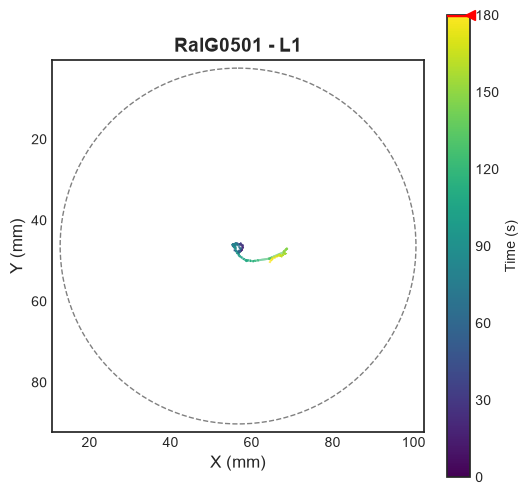

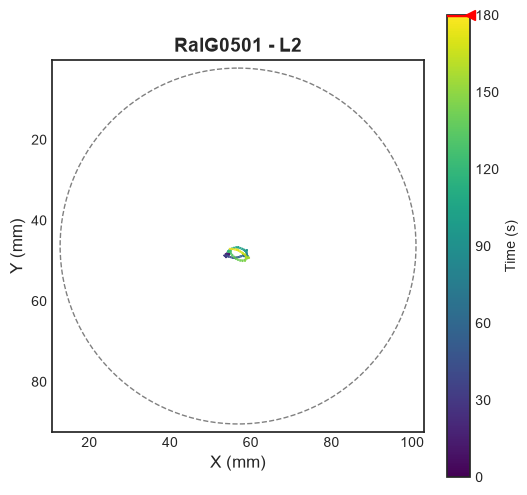

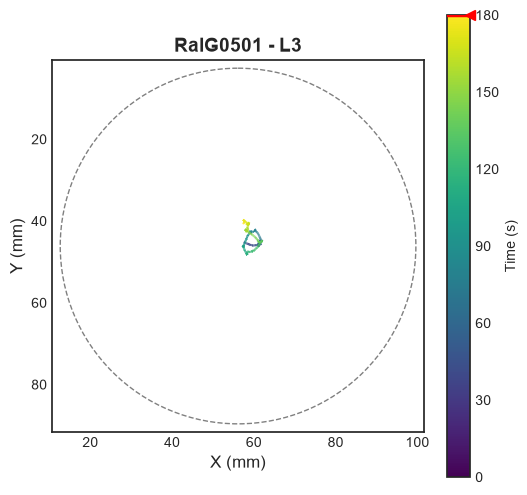

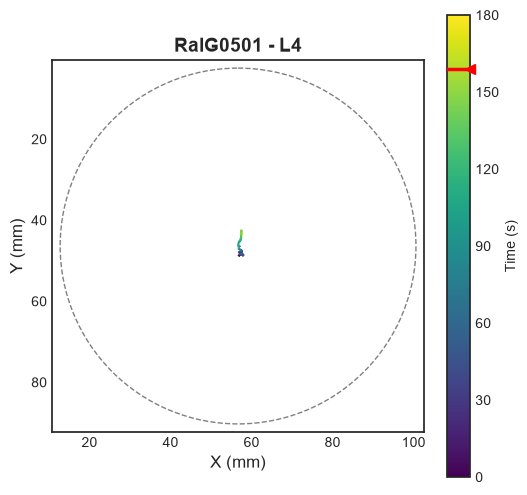

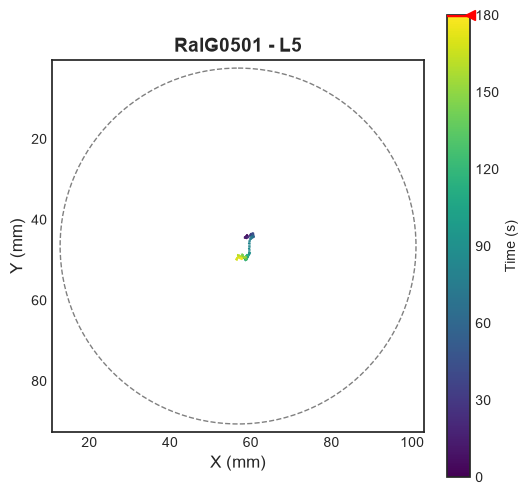

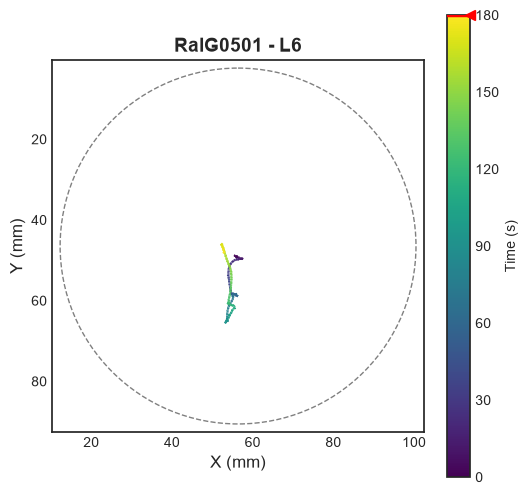

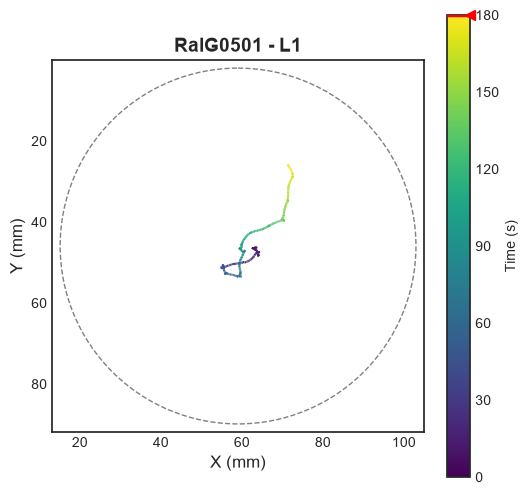

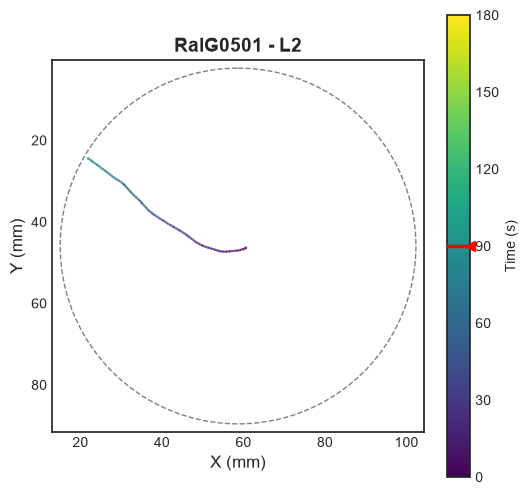

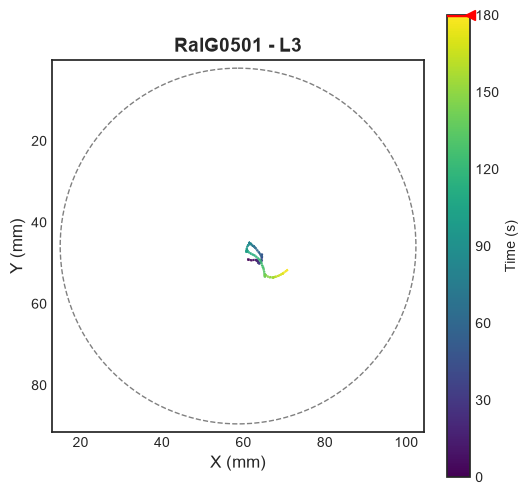

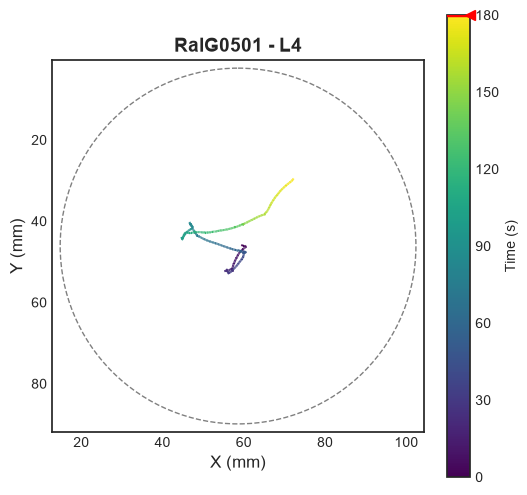

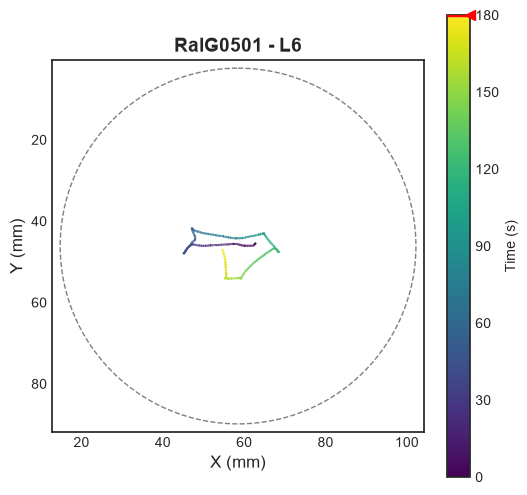

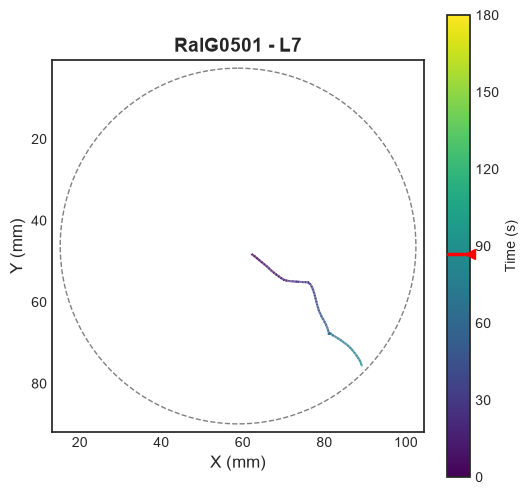

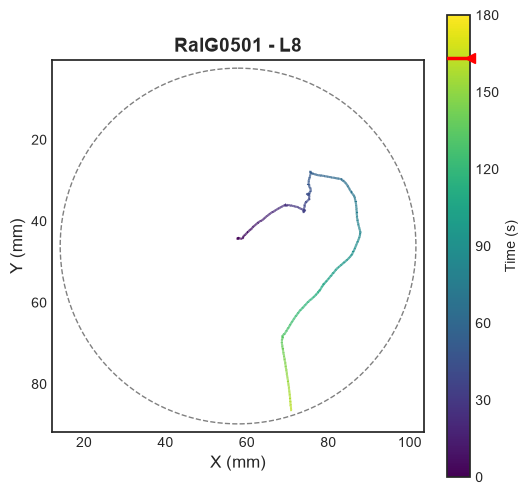

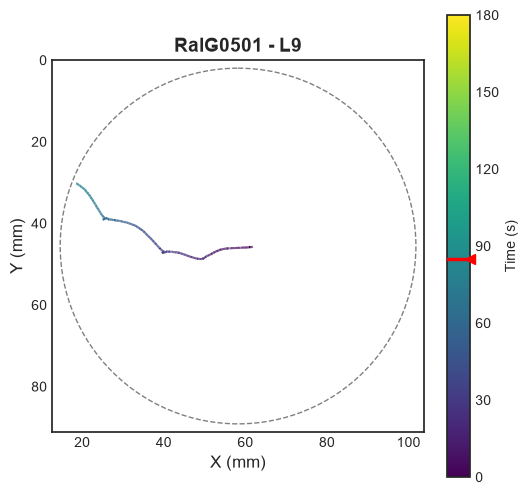

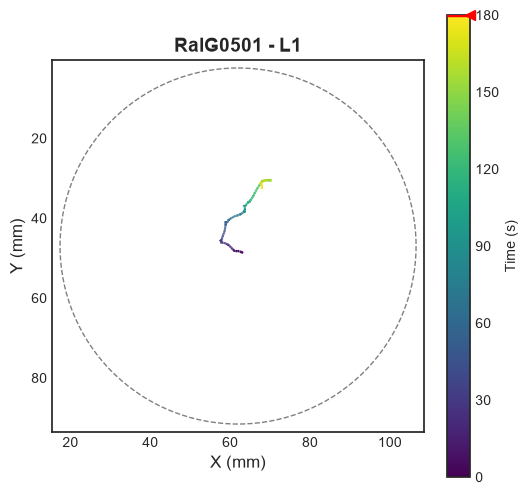

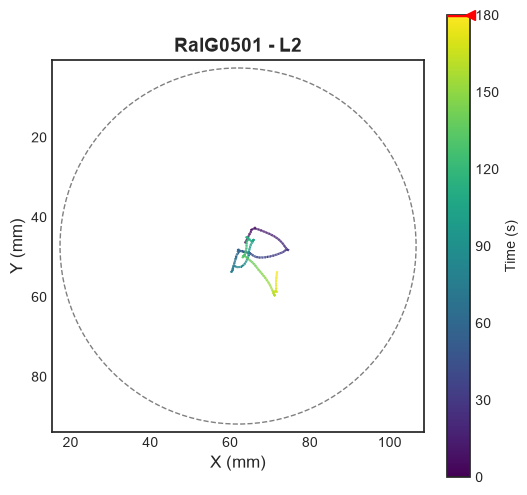

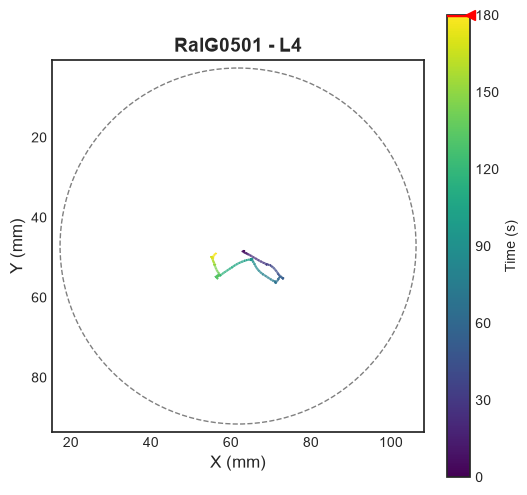

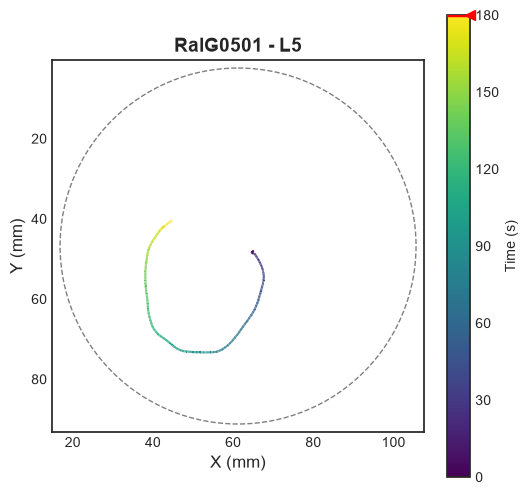

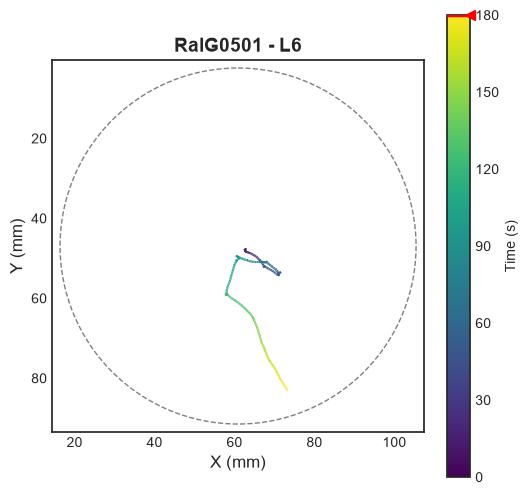

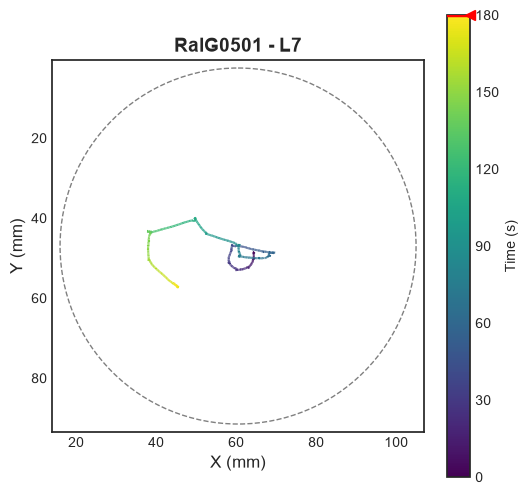

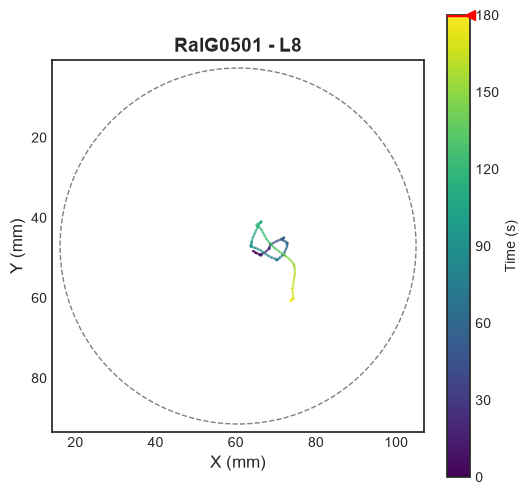

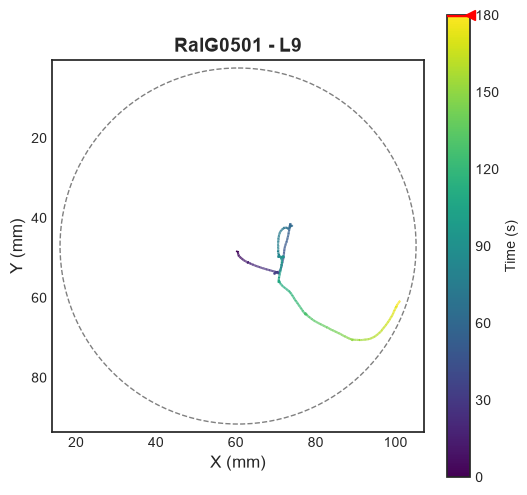

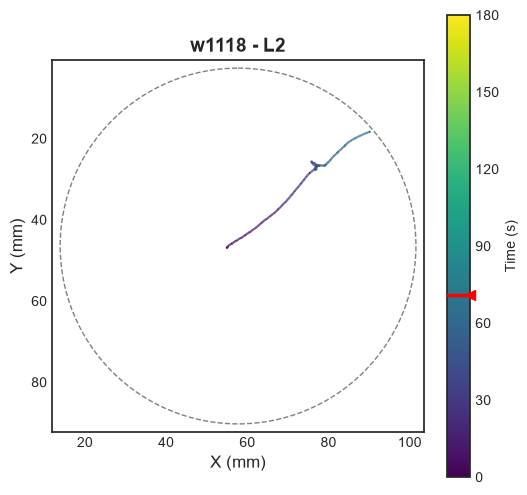

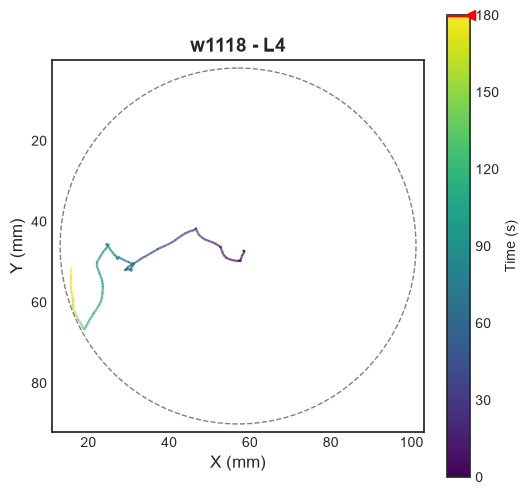

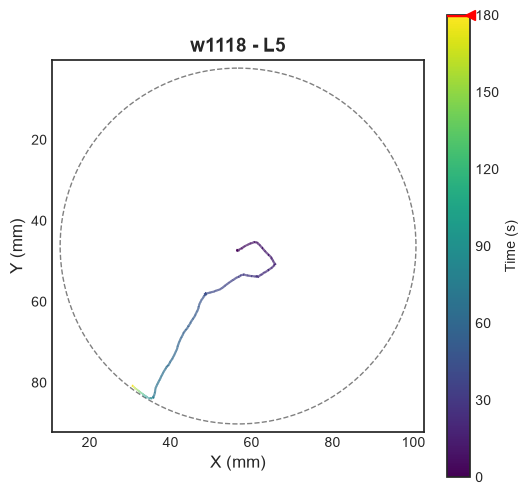

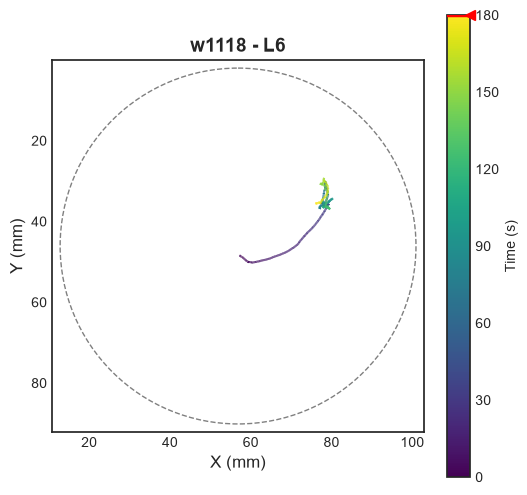

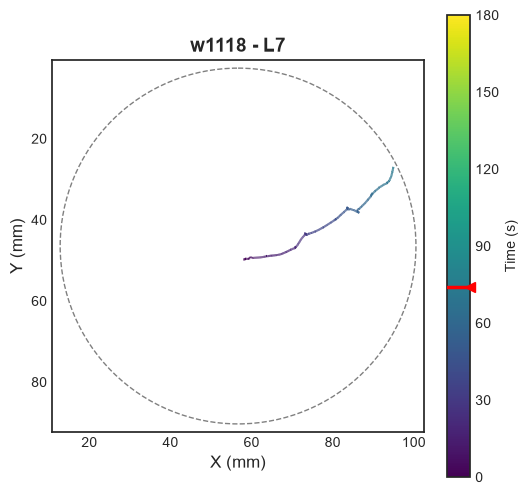

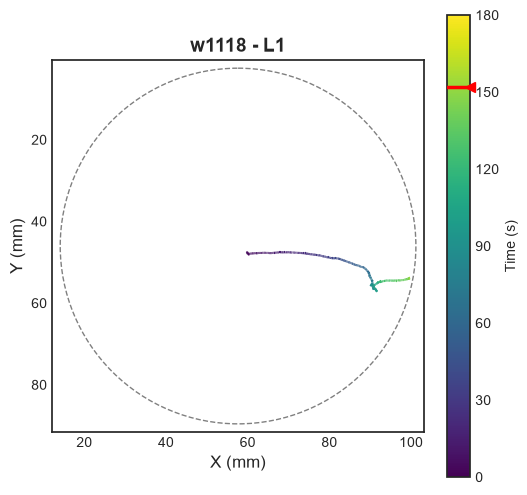

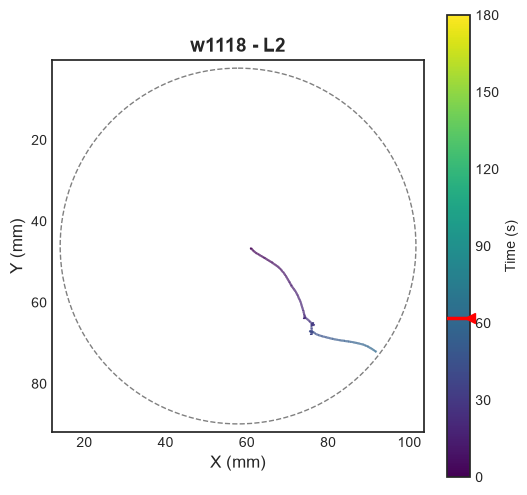

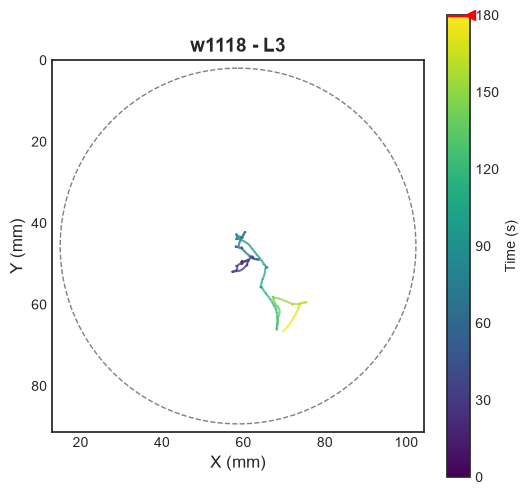

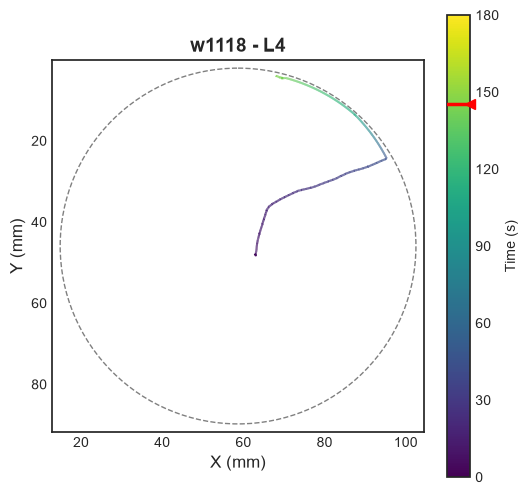

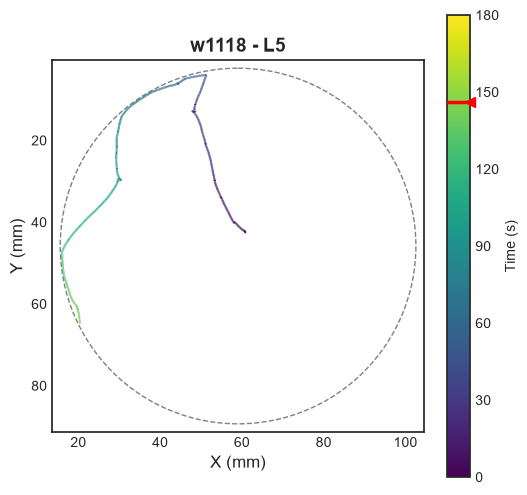

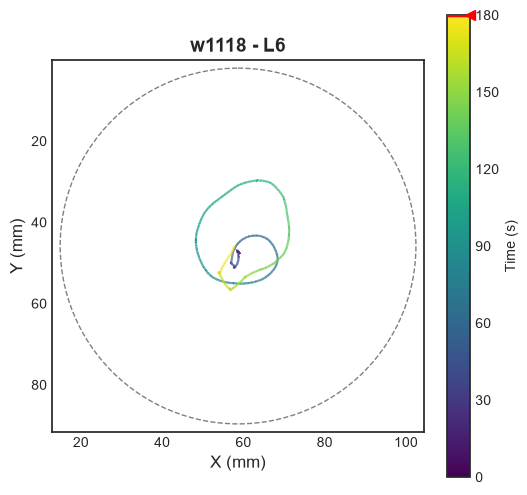

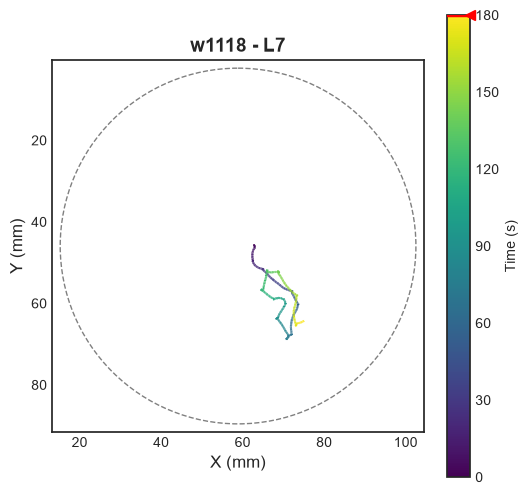

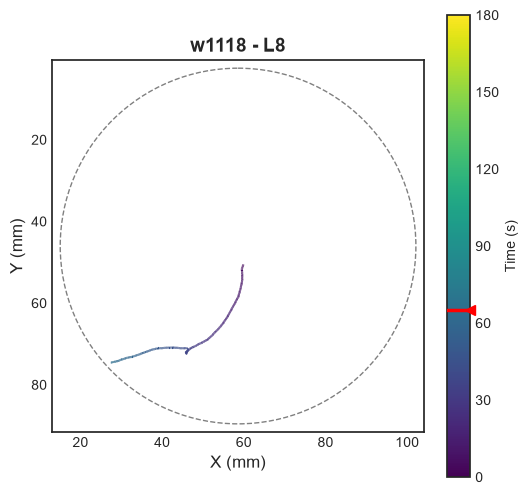

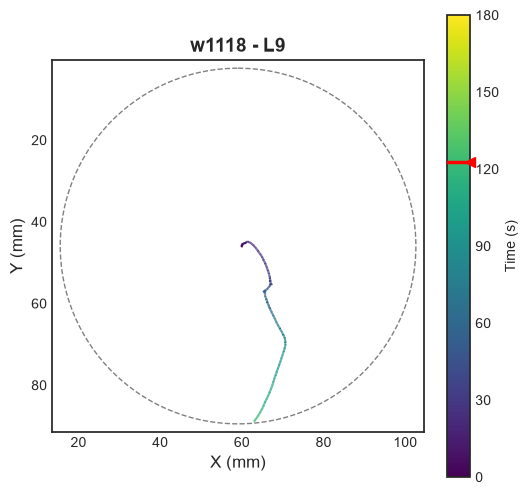

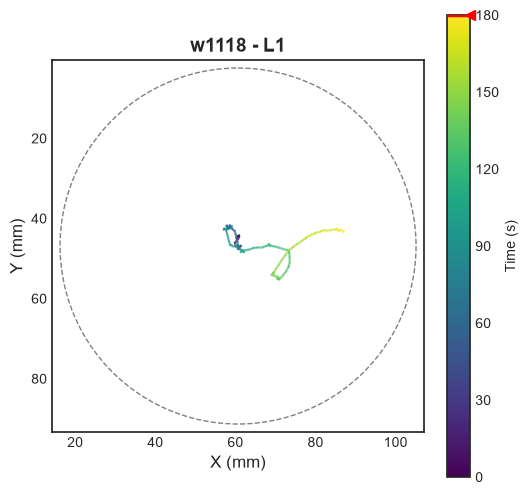

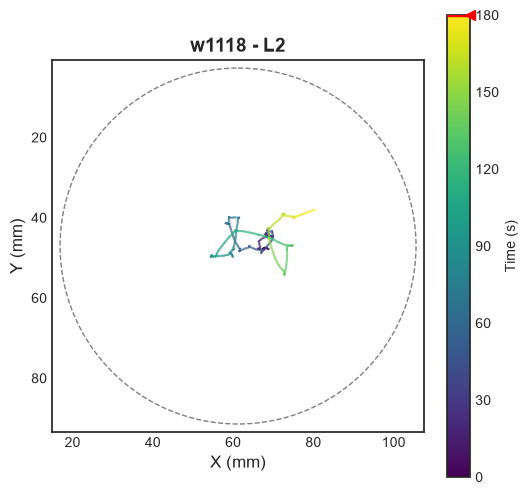

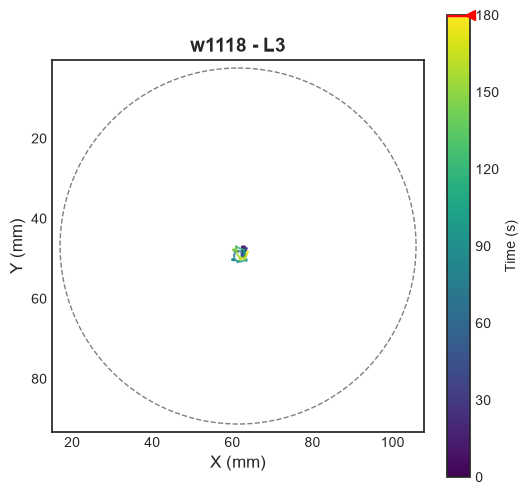

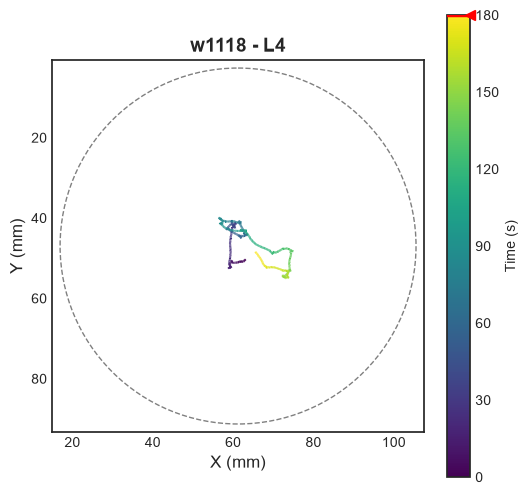

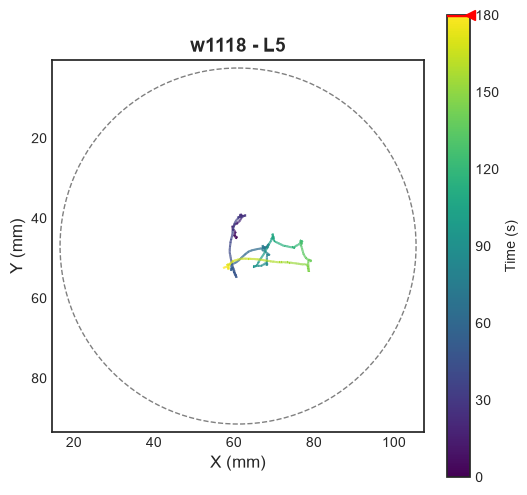

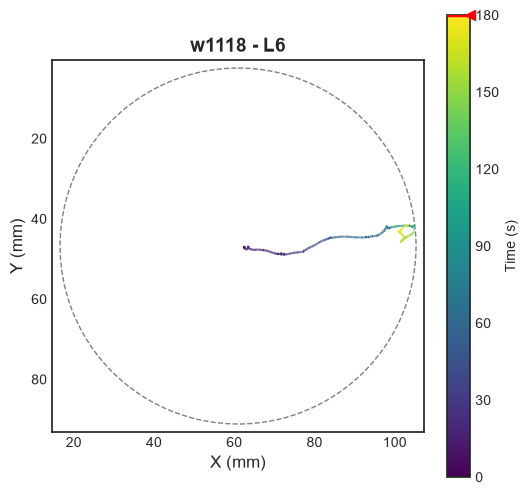

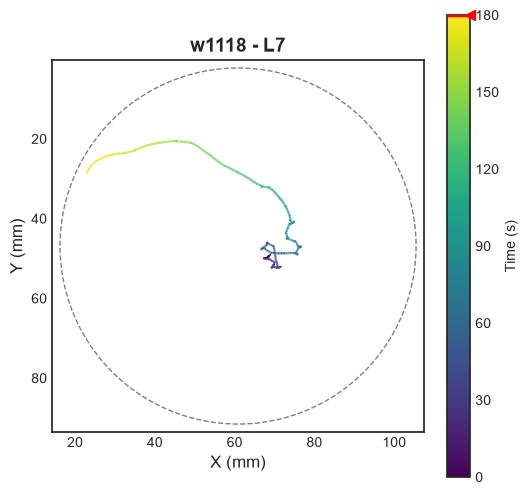

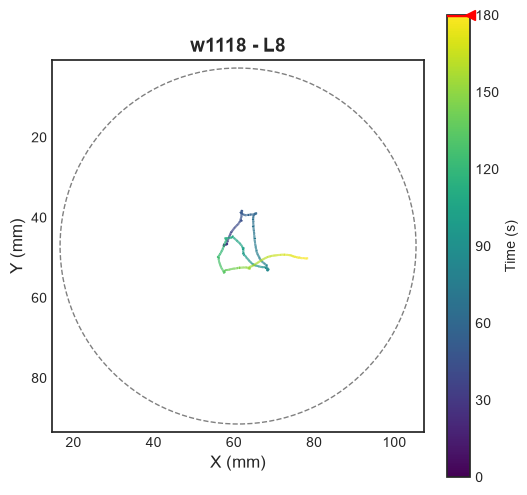

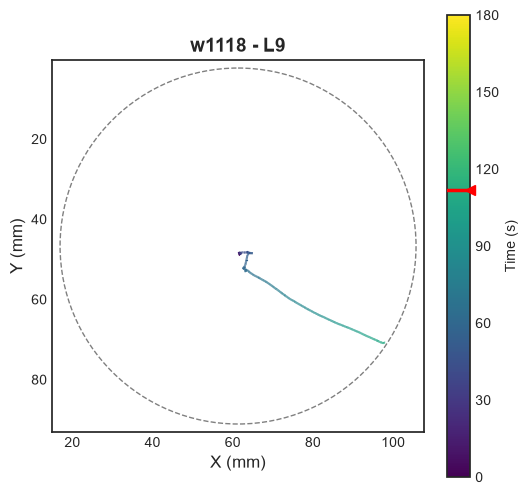

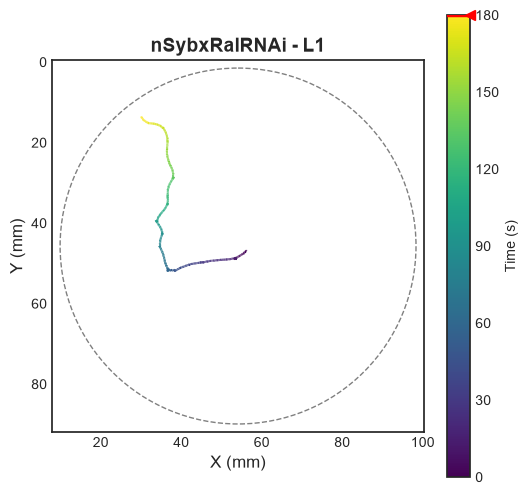

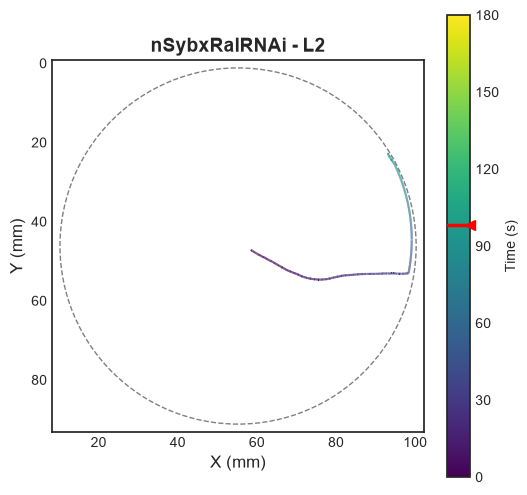

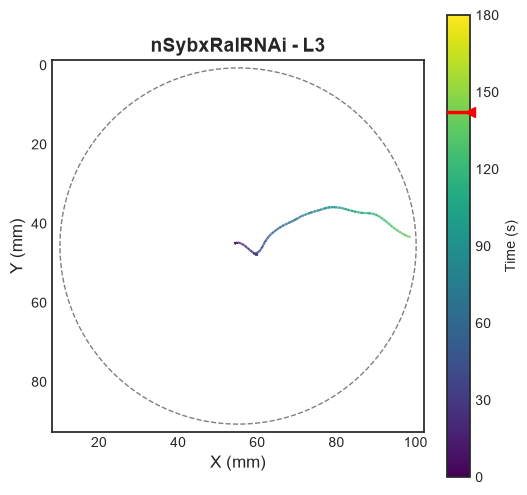

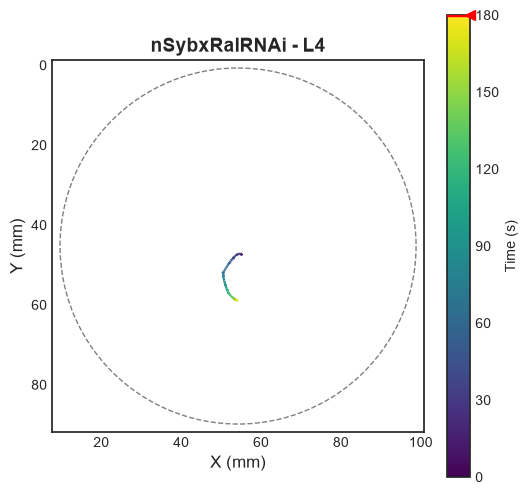

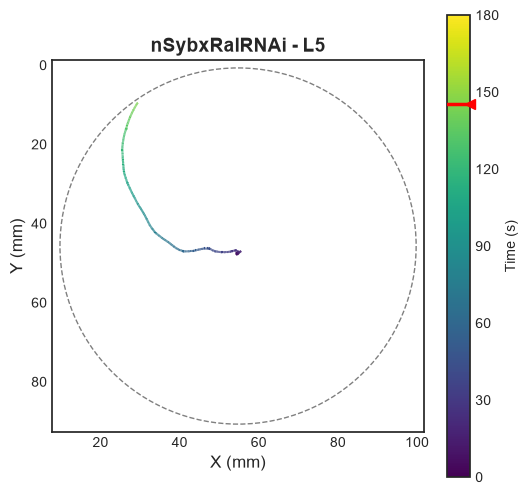

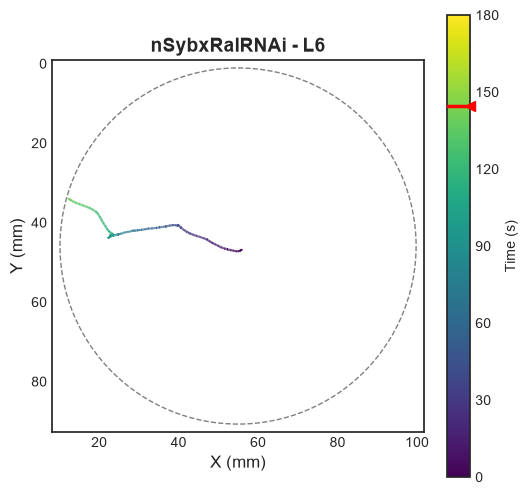

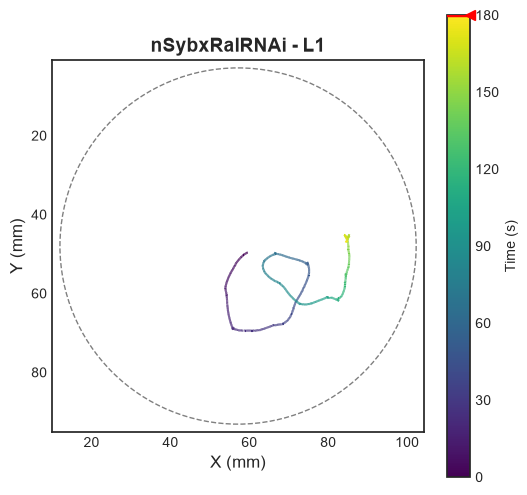

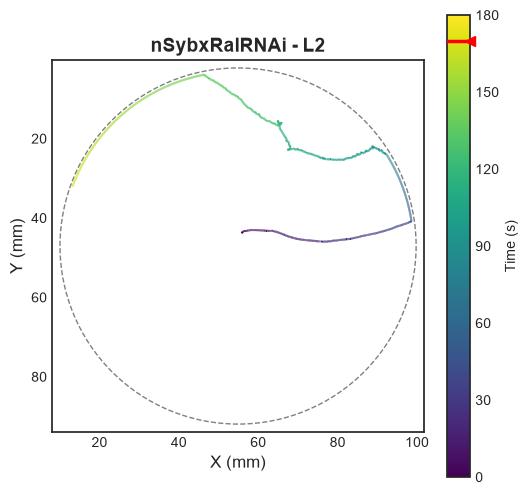

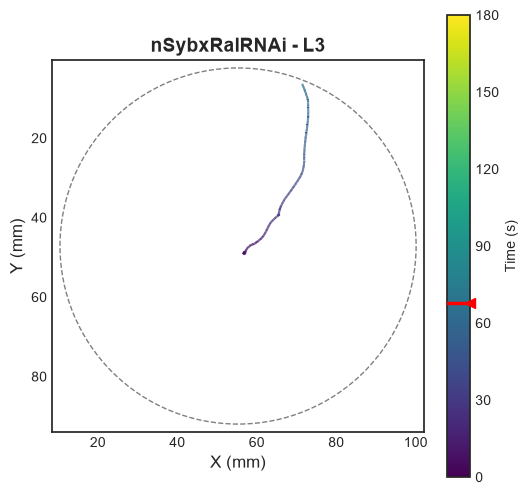

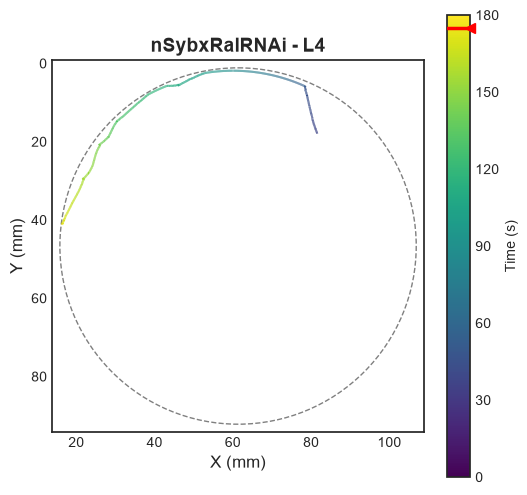

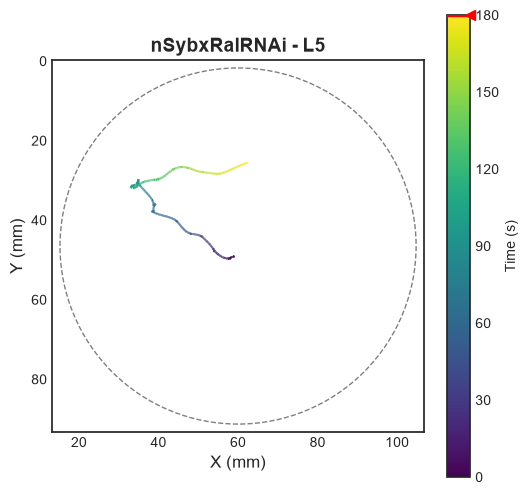

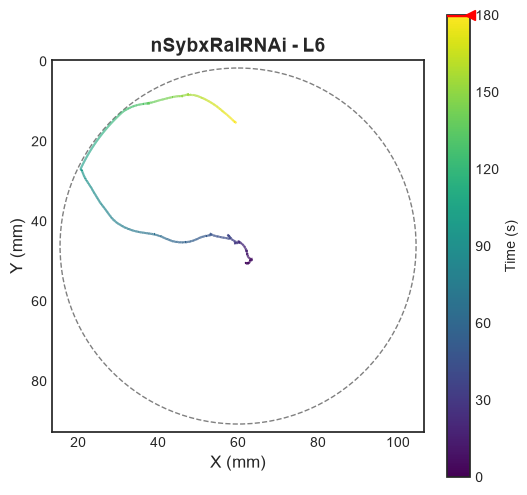

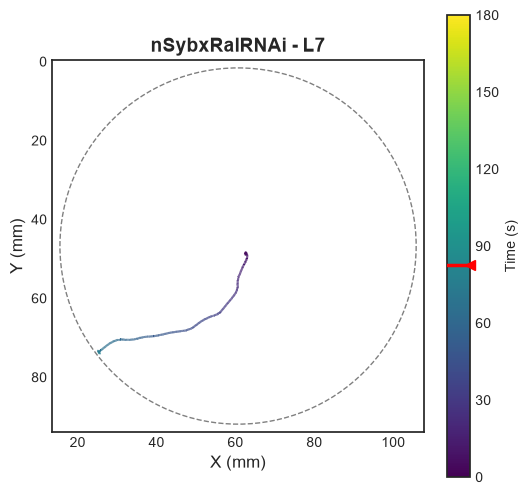

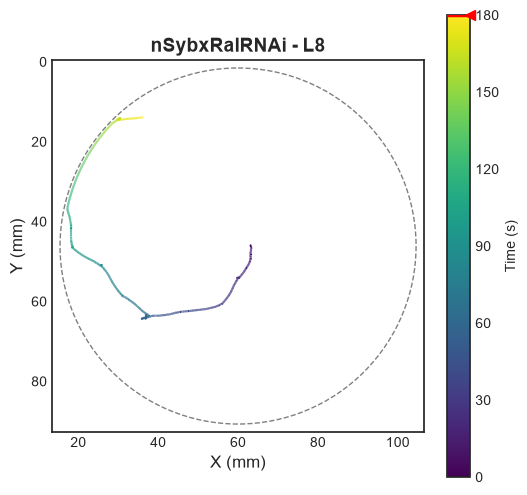

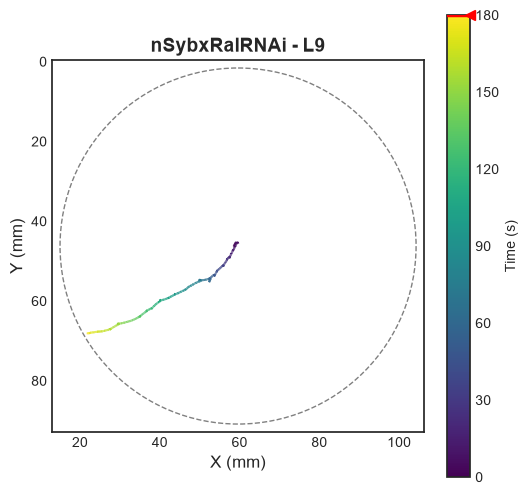

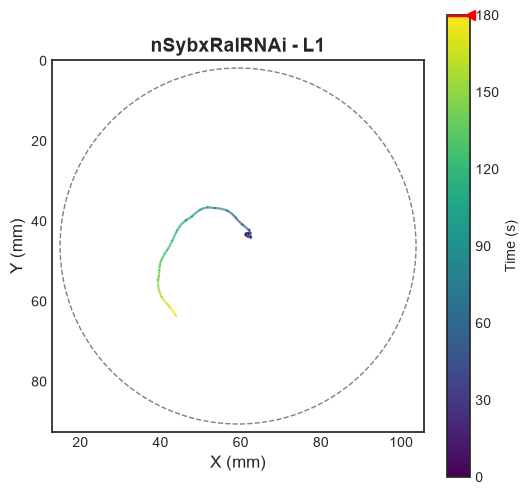

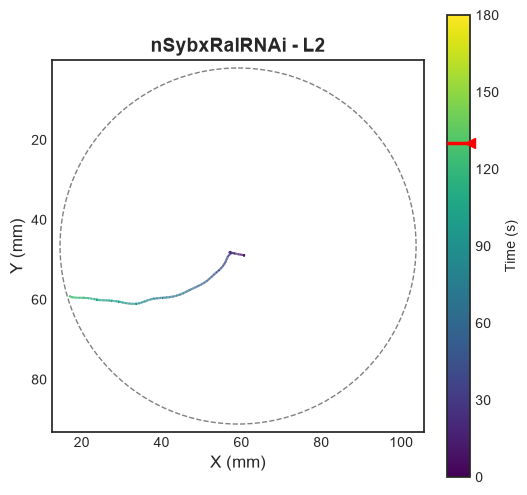

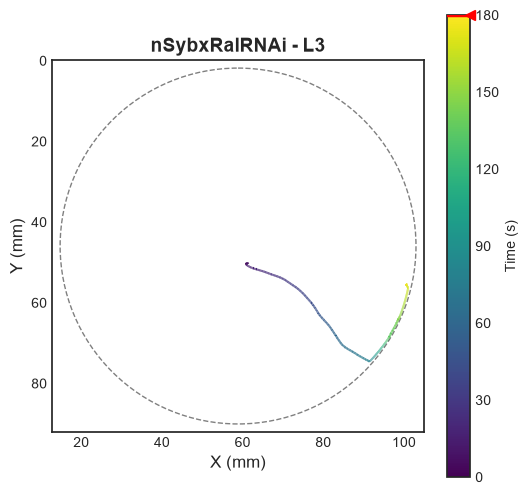

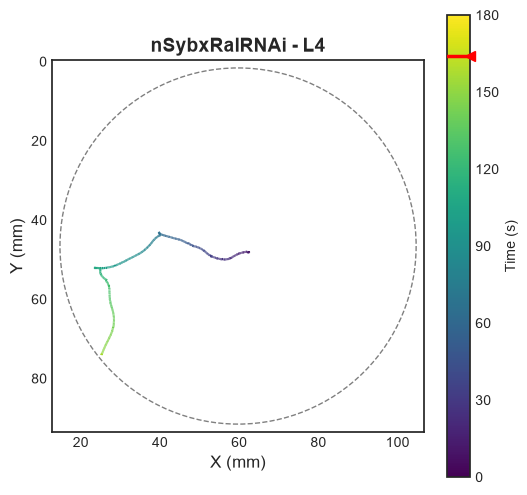

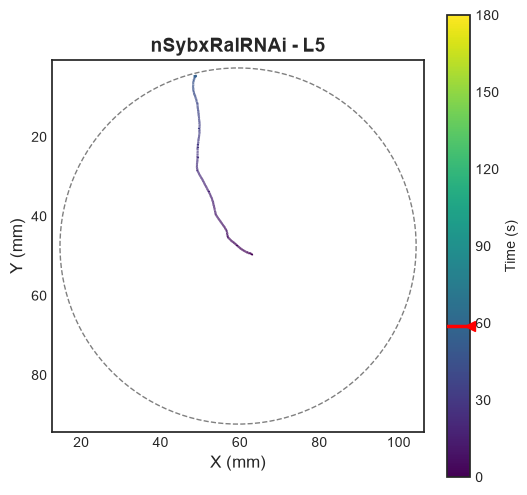

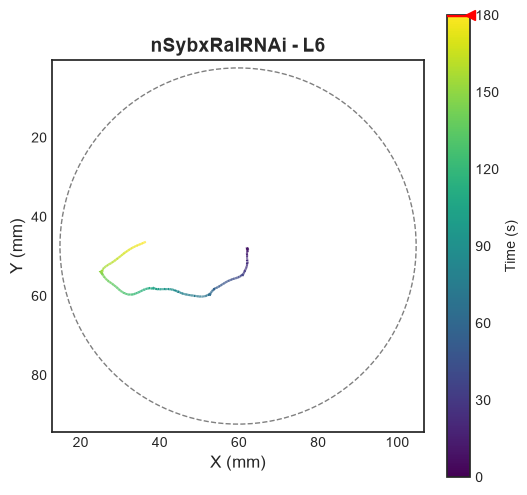

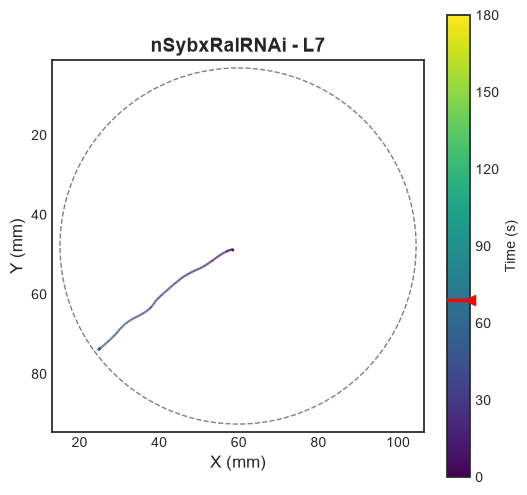

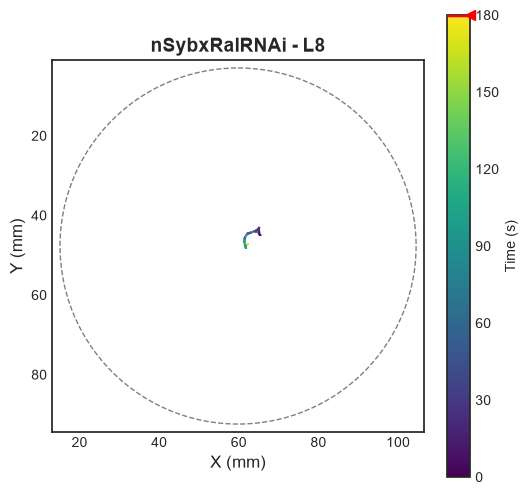

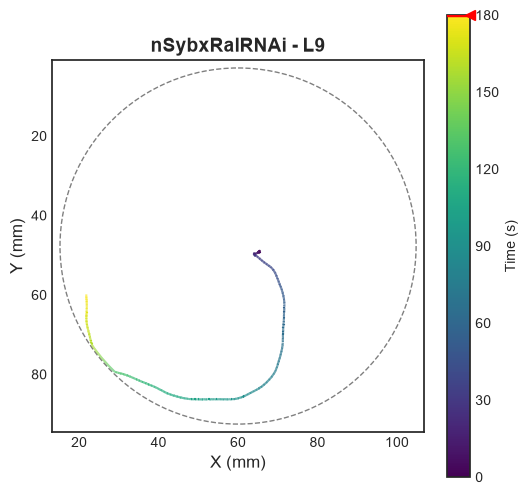

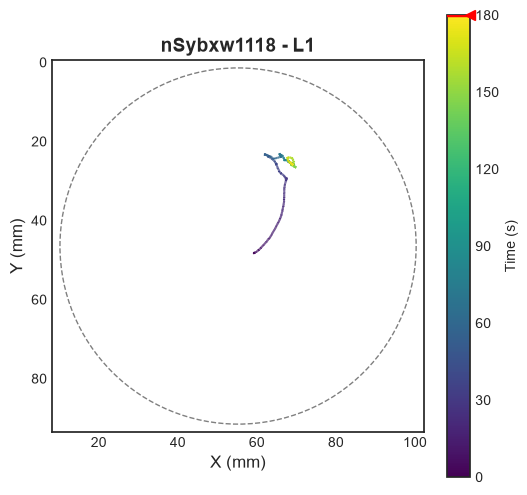

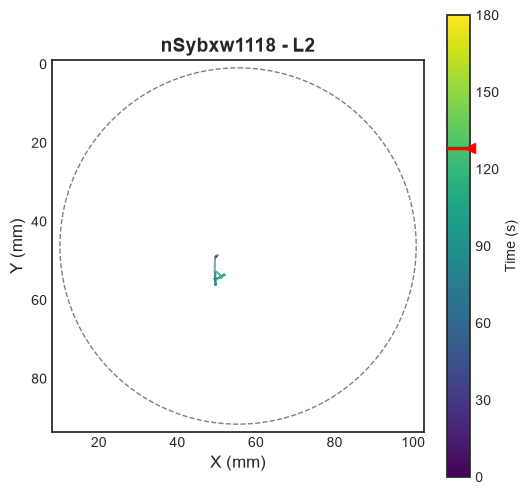

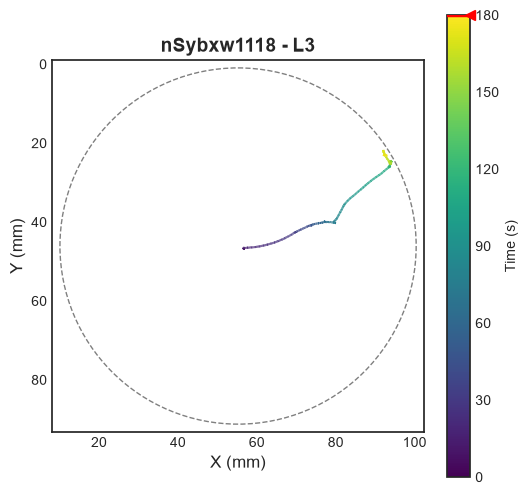

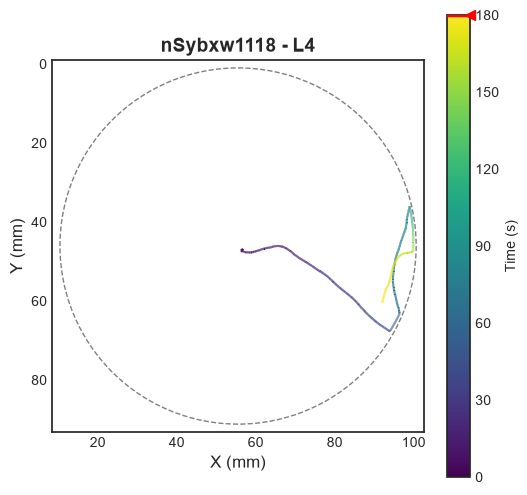

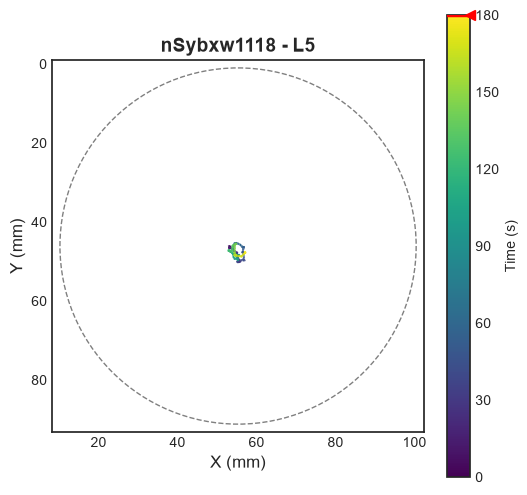

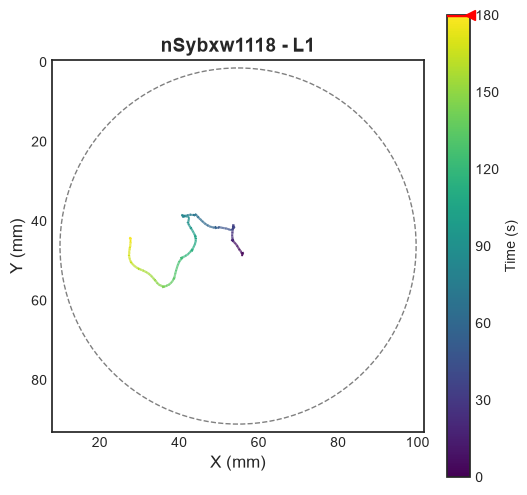

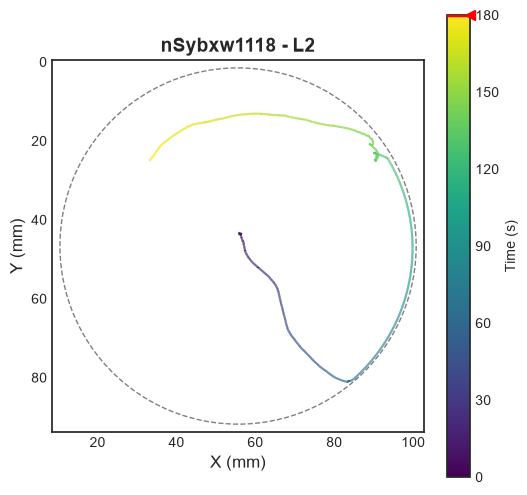

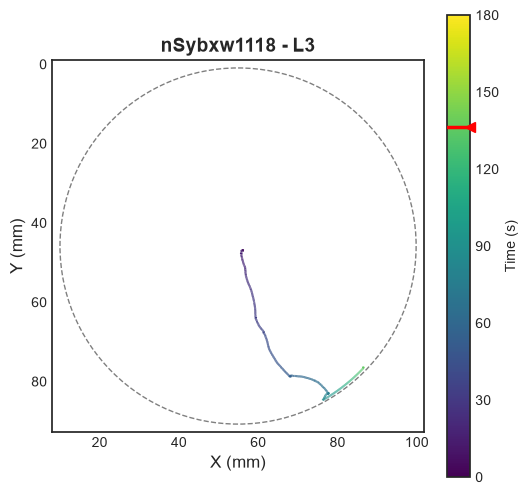

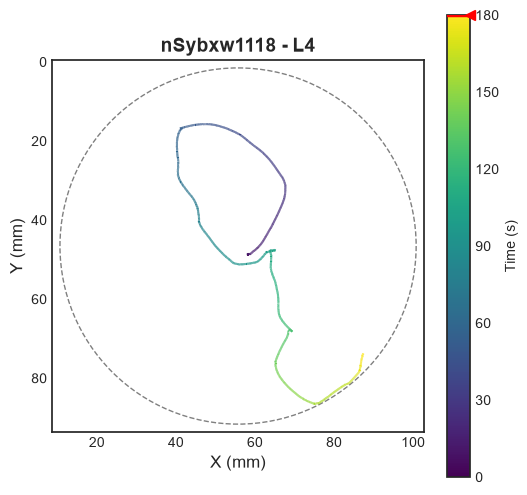

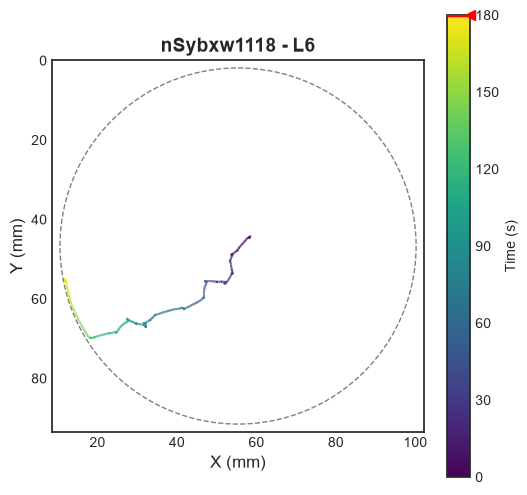

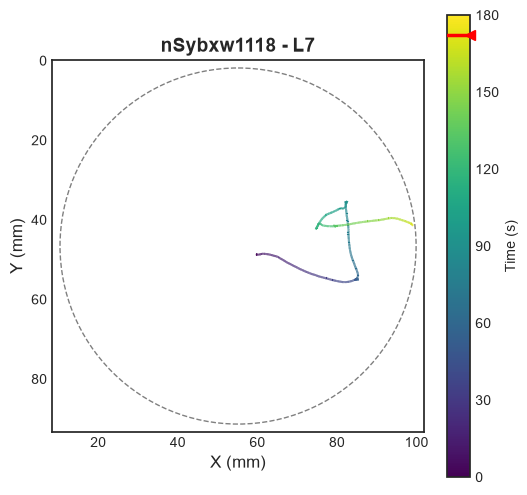

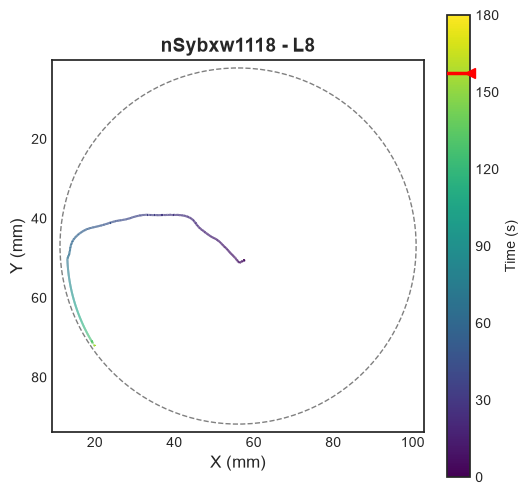

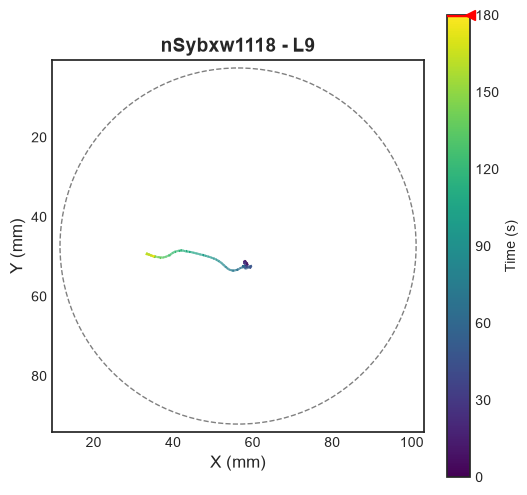

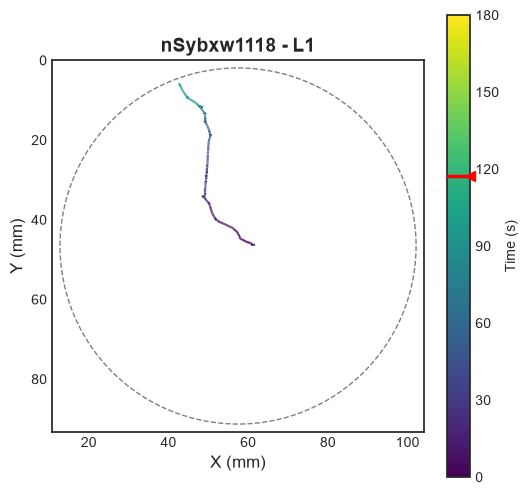

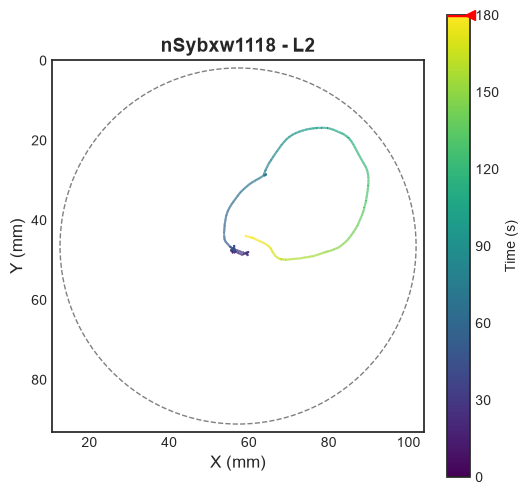

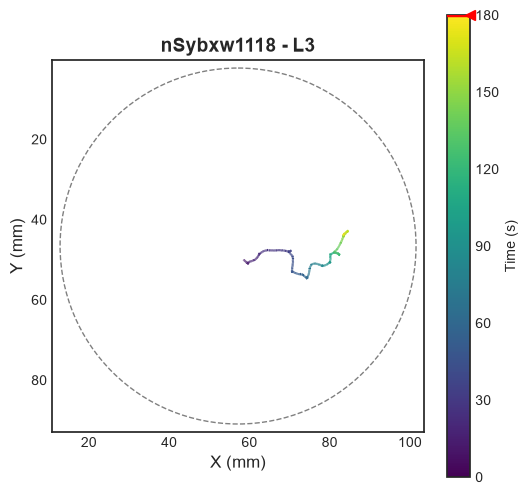

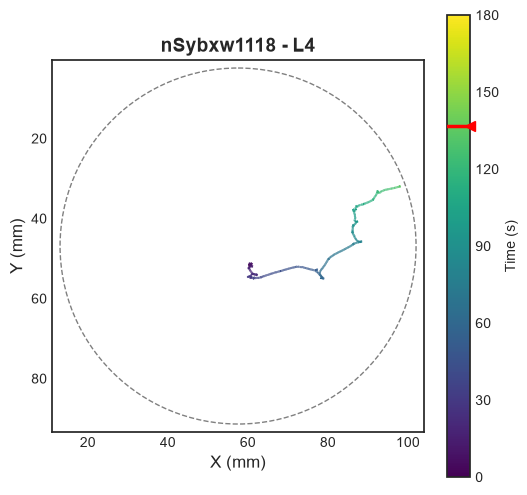

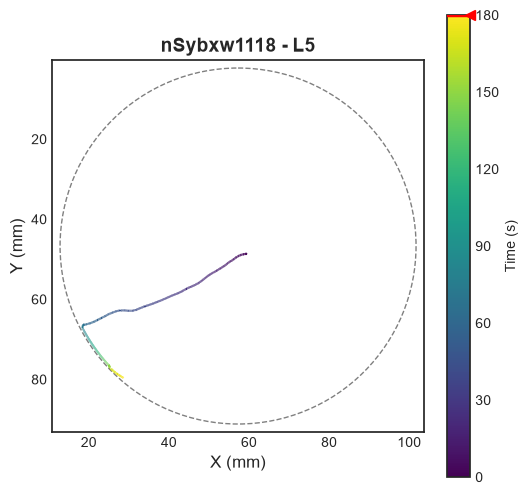

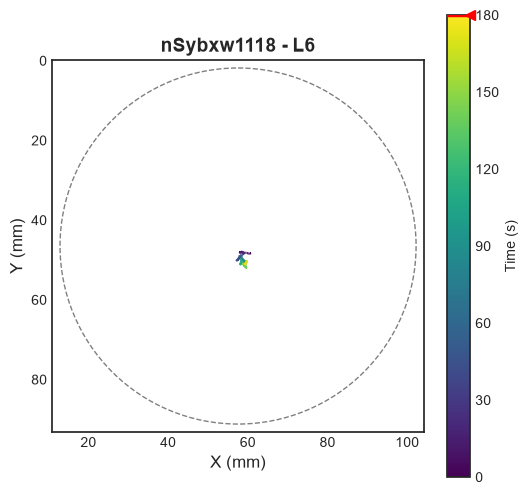

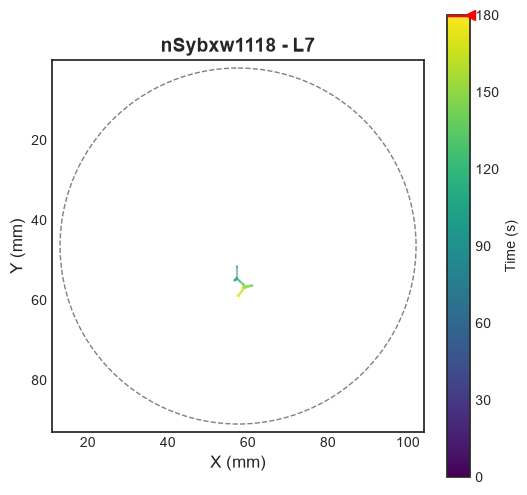

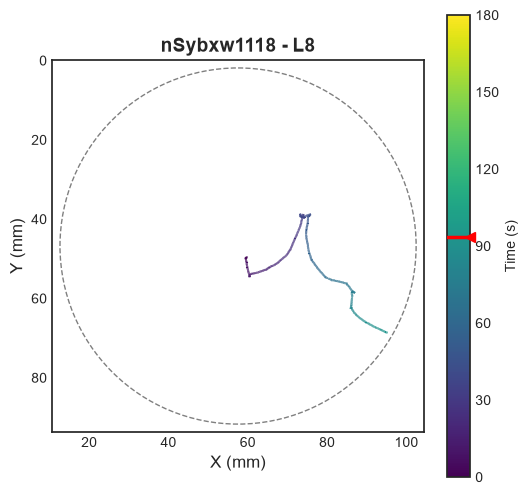

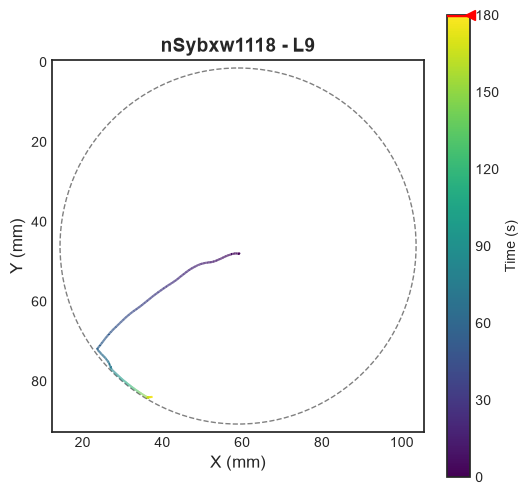

In [6]:
# Determine common time scale across all larvae (e.g. 0 to 180s)
max_recording_time_s = round(max(df["Frame"].max() / df["fps"].iloc[0] for df in larva_dfs.values()))
time_clim = (0.0, float(max_recording_time_s))

for name, df_larva in larva_dfs.items():
    fig, ax = plot_trajectory(
        df_larva,
        title=f"{df_larva.attrs.get('genotype', '')} - {Path(name).stem}",
        dish_center_mm=DISH_CENTER_MM,
        dish_radius_mm=DISH_RADIUS_MM,
        clim=time_clim,
    )
    plt.show()


### Speed over time (per-epoch) grouped by genotype and NX cohort

Calculates and plots the median speed across time (10s epochs) for each genotype, showing separate lines
for each experimental cohort (e.g. N1, N2, N3) with a shaded band representing the interquartile range (IQR: 25th to 75th percentiles).


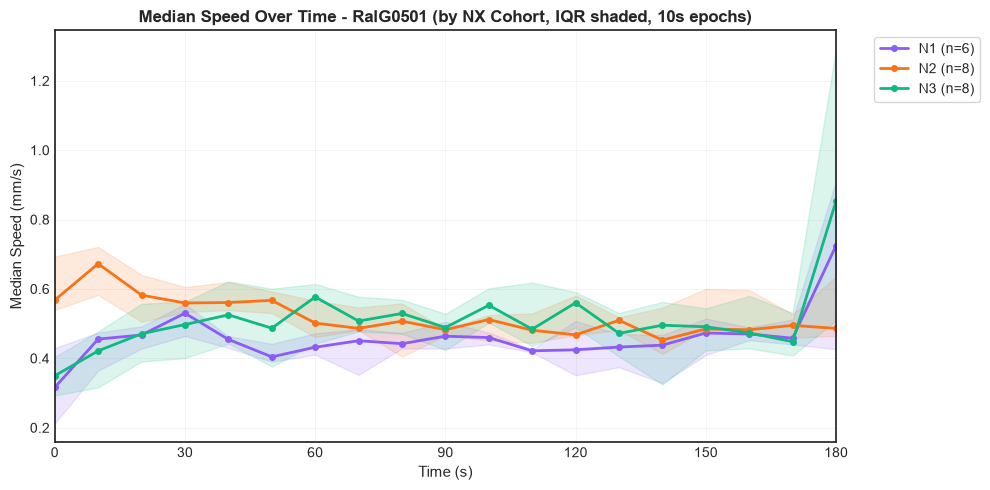

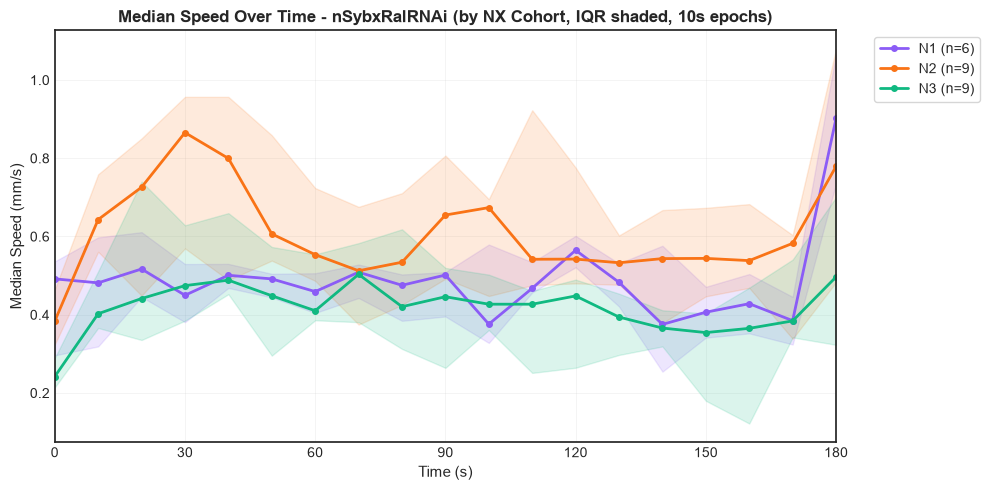

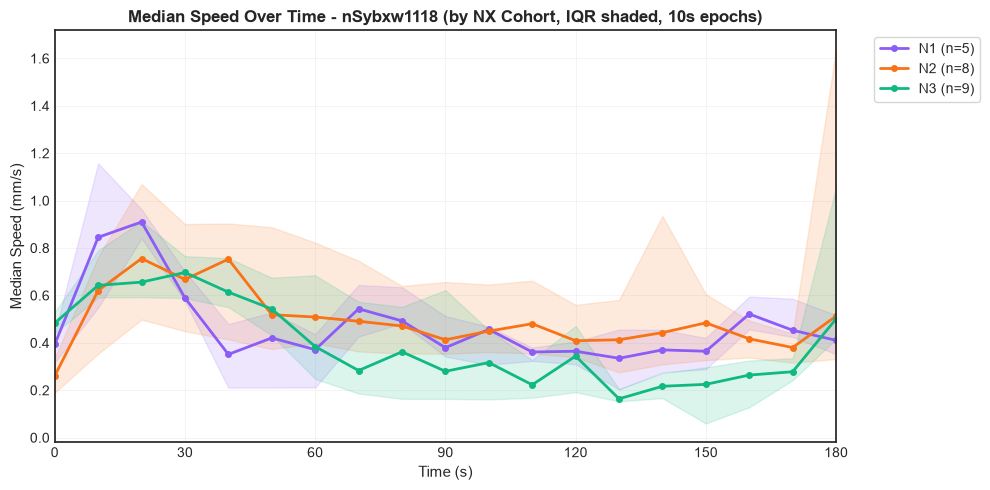

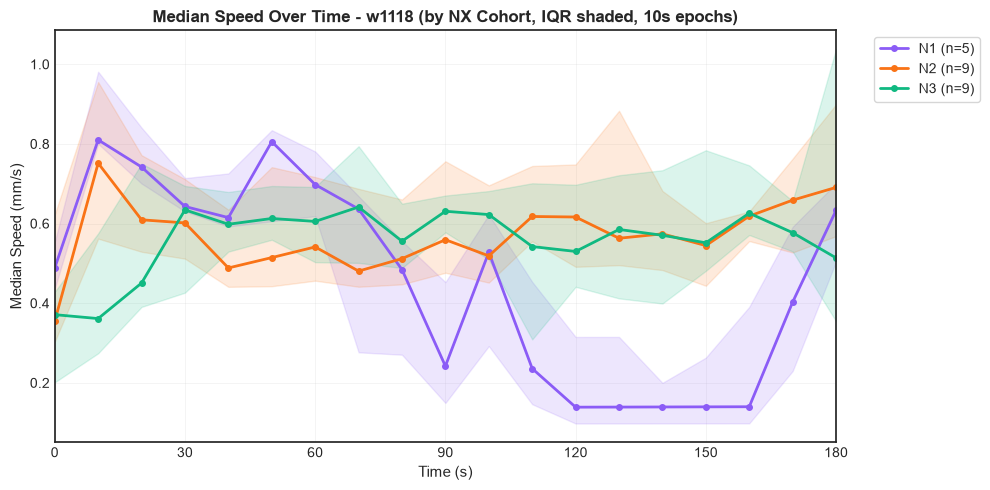

In [7]:
# Determine common time scale across all larvae
if 'max_recording_time_s' not in globals():
    max_recording_time_s = round(max(df['Frame'].max() / df['fps'].iloc[0] for df in larva_dfs.values()))

EPOCH_S = 10  # seconds per epoch

# Group larvae by genotype and NX cohort prefix (e.g. N1, N2, N3)
genotype_cohort_larvae = {}
for name, df_larva in larva_dfs.items():
    file_p = df_larva.attrs.get("file_path", name)
    meta = parse_filename_metadata(file_p)
    genotype = df_larva.attrs.get("genotype") or meta.get("genotype") or "Unknown"
    cohort = meta.get("cohort") or "All"
    genotype_cohort_larvae.setdefault(genotype, {}).setdefault(cohort, []).append((name, df_larva))

max_t_s = int(round(max_recording_time_s))
tick_step = 30 if max_t_s >= 120 else (20 if max_t_s >= 60 else 10)
time_ticks = list(range(0, max_t_s, tick_step))
if max_t_s not in time_ticks:
    time_ticks.append(max_t_s)

for genotype, cohort_dict in sorted(genotype_cohort_larvae.items()):
    fig, ax = plt.subplots(figsize=(10, 5))
    palette = ["#8B5CF6", "#F97316", "#10B981", "#6366F1", "#EC4899"]

    for idx, (cohort, items) in enumerate(sorted(cohort_dict.items())):
        color = palette[idx % len(palette)]

        # Combine epoch stats across all larvae in this cohort
        ep_dfs = [summarize_by_epoch(df_l, epoch_s=EPOCH_S).assign(larva=n) for n, df_l in items]
        all_ep = pd.concat(ep_dfs, ignore_index=True)

        # Median and IQR across larvae in this cohort per epoch
        c_stats = all_ep.groupby("epoch")["median"].agg(
            median="median",
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
        ).reset_index()

        c_stats["time_s"] = c_stats["epoch"] * EPOCH_S

        # Plot median line for cohort
        ax.plot(
            c_stats["time_s"],
            c_stats["median"],
            label=f"{cohort} (n={len(items)})",
            color=color,
            marker="o",
            markersize=4,
            linewidth=2,
        )

        # Interquartile range (IQR) band for cohort
        ax.fill_between(
            c_stats["time_s"],
            c_stats["q25"],
            c_stats["q75"],
            color=color,
            alpha=0.15,
        )

    # Standardize x-axis to show the exact full range including the maximum rounded unit
    ax.set_xlim(0, max_t_s)
    ax.set_xticks(time_ticks)

    ax.set_xlabel("Time (s)", fontsize=11)
    ax.set_ylabel("Median Speed (mm/s)", fontsize=11)
    ax.set_title(f"Median Speed Over Time - {genotype} (by NX Cohort, IQR shaded, {EPOCH_S}s epochs)", fontsize=12, weight="bold")
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left", frameon=True, fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### Cumulative distance traveled grouped by genotype and NX cohort

Calculates and plots the median cumulative distance crawled over time for each genotype, showing separate lines
for each experimental cohort (e.g. N1, N2, N3) with a shaded band representing the interquartile range (IQR: 25th to 75th percentiles).


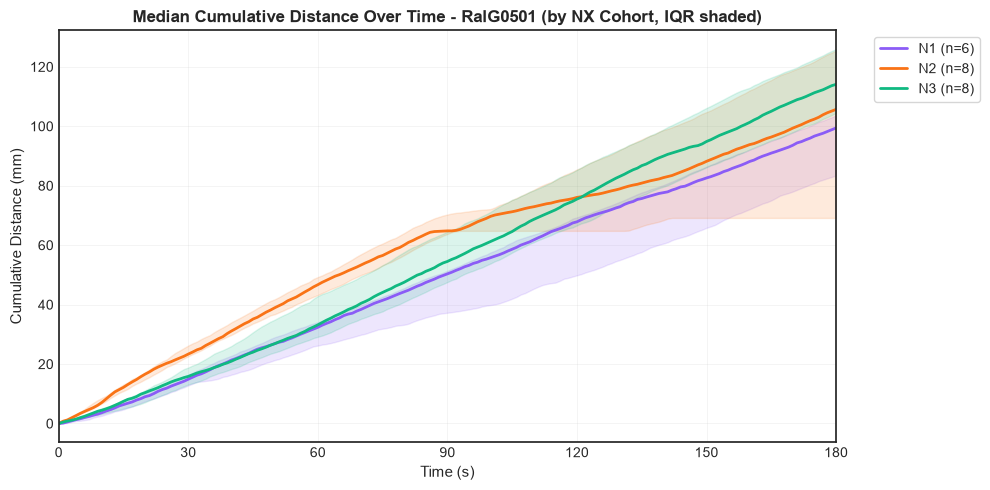

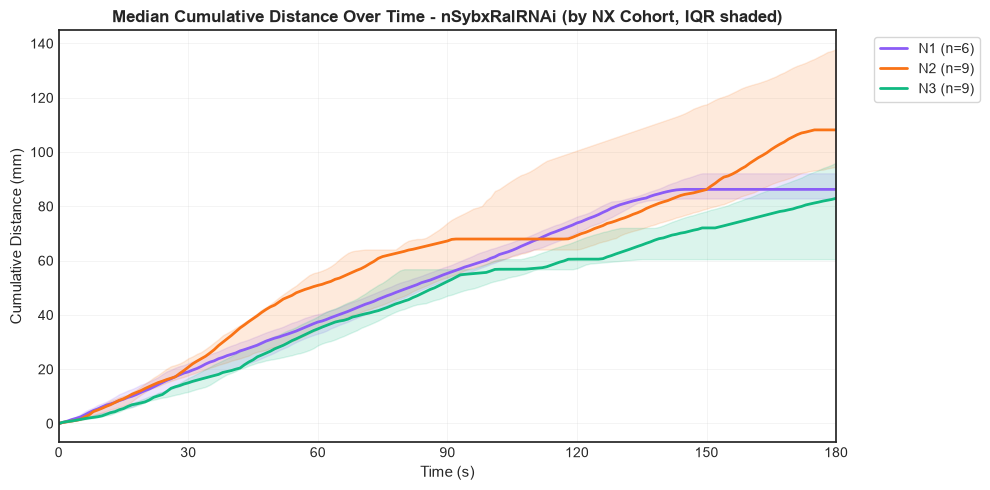

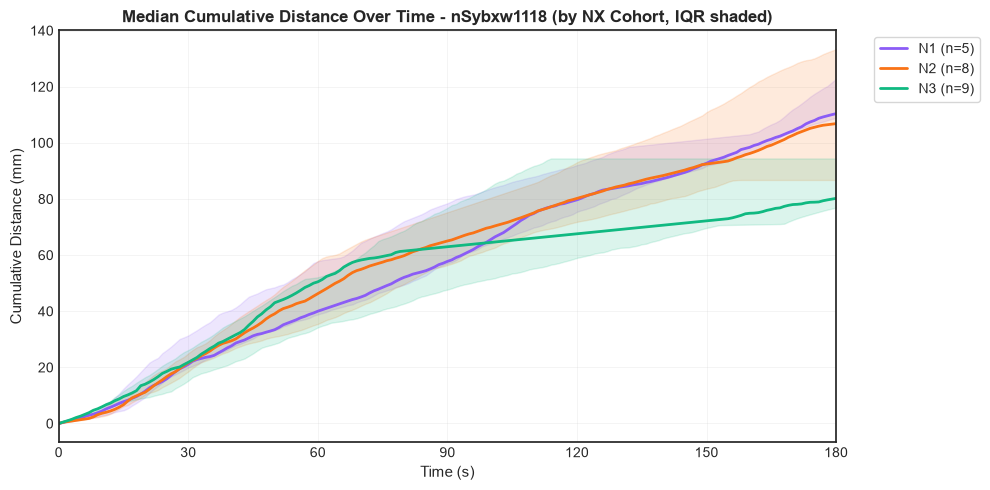

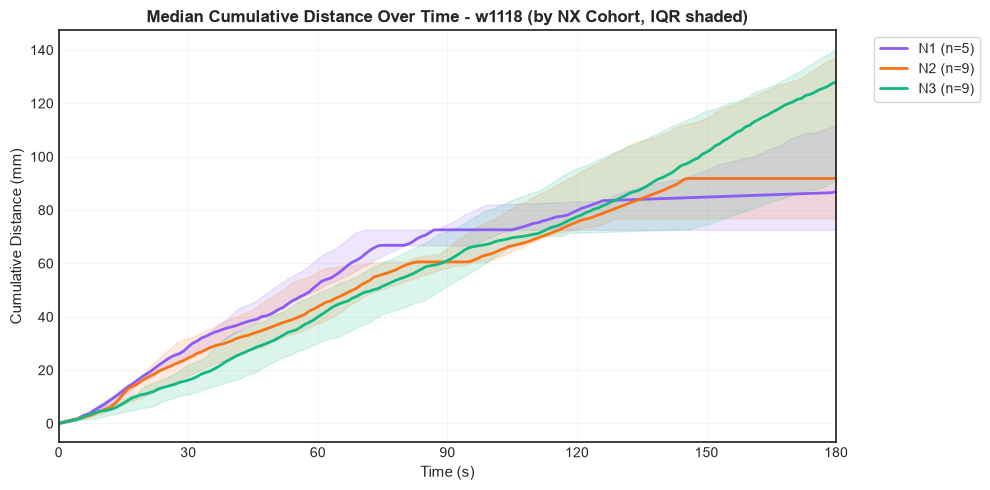

In [8]:
max_time_s = round(max(df["Frame"].max() / df["fps"].iloc[0] for df in larva_dfs.values()))
time_grid = np.linspace(0, max_time_s, int(max_time_s) + 1)
max_t_s = int(round(max_time_s))
tick_step = 30 if max_t_s >= 120 else (20 if max_t_s >= 60 else 10)
time_ticks = list(range(0, max_t_s, tick_step))
if max_t_s not in time_ticks:
    time_ticks.append(max_t_s)

for genotype, cohort_dict in sorted(genotype_cohort_larvae.items()):
    fig, ax = plt.subplots(figsize=(10, 5))
    palette = ["#8B5CF6", "#F97316", "#10B981", "#6366F1", "#EC4899"]

    for idx, (cohort, items) in enumerate(sorted(cohort_dict.items())):
        color = palette[idx % len(palette)]

        # Interpolate cumulative distance for each larva onto a common time grid
        cum_matrix = []
        for n, df_l in items:
            t = df_l["Frame"] / df_l["fps"].iloc[0]
            cd = df_l["step_dist_mm"].fillna(0).cumsum()
            cd_interp = np.interp(time_grid, t, cd)
            cum_matrix.append(cd_interp)

        cum_matrix = np.array(cum_matrix)
        median_cum = np.median(cum_matrix, axis=0)
        q25_cum = np.percentile(cum_matrix, 25, axis=0)
        q75_cum = np.percentile(cum_matrix, 75, axis=0)

        ax.plot(
            time_grid,
            median_cum,
            label=f"{cohort} (n={len(items)})",
            color=color,
            linewidth=2,
        )

        ax.fill_between(
            time_grid,
            q25_cum,
            q75_cum,
            color=color,
            alpha=0.15,
        )

    # Standardize x-axis to show the exact full range including the maximum rounded unit
    ax.set_xlim(0, max_t_s)
    ax.set_xticks(time_ticks)

    ax.set_xlabel("Time (s)", fontsize=11)
    ax.set_ylabel("Cumulative Distance (mm)", fontsize=11)
    ax.set_title(f"Median Cumulative Distance Over Time - {genotype} (by NX Cohort, IQR shaded)", fontsize=12, weight="bold")
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left", frameon=True, fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 2. Batch analysis (many videos / larvae at once)

Point this at a folder containing all your Fiji-macro output CSVs (one per video/larva).
Each file is run through the same cleaning + kinematics pipeline, then combined into one
summary table with automatic QC flags — videos whose numbers stand out from the rest of the
batch (not from a fixed universal cutoff, since "normal" varies by genotype/condition/setup)
get flagged for a quick visual double-check.


In [9]:
# ---- EDIT THIS CELL for your data ----

# Automatically determine the directory containing coordinate CSVs (including genotype subfolders)
candidate_csv_folders = [Path('../data/csvs'), Path('data/csvs'), Path('behavior/data/csvs'), Path('.')]
CSV_FOLDER = '.'
for cand in candidate_csv_folders:
    if cand.exists() and any(cand.rglob('*.csv')):
        CSV_FOLDER = str(cand)
        break

csv_paths = [
    p for p in sorted(Path(CSV_FOLDER).rglob('*.csv'))
    if not p.name.startswith('larva_batch_summary')
]
print(f'Using CSV_FOLDER: {CSV_FOLDER}')
print(f'Found {len(csv_paths)} CSV files:')
for p in csv_paths:
    print(' -', p.relative_to(CSV_FOLDER) if p.is_relative_to(CSV_FOLDER) else p.name)


Using CSV_FOLDER: ..\data\csvs
Found 91 CSV files:
 - graph 1\RalG0501\N1\L1.csv
 - graph 1\RalG0501\N1\L2.csv
 - graph 1\RalG0501\N1\L3.csv
 - graph 1\RalG0501\N1\L4.csv
 - graph 1\RalG0501\N1\L5.csv
 - graph 1\RalG0501\N1\L6.csv
 - graph 1\RalG0501\N2\L1.csv
 - graph 1\RalG0501\N2\L2.csv
 - graph 1\RalG0501\N2\L3.csv
 - graph 1\RalG0501\N2\L4.csv
 - graph 1\RalG0501\N2\L6.csv
 - graph 1\RalG0501\N2\L7.csv
 - graph 1\RalG0501\N2\L8.csv
 - graph 1\RalG0501\N2\L9.csv
 - graph 1\RalG0501\N3\L1.csv
 - graph 1\RalG0501\N3\L2.csv
 - graph 1\RalG0501\N3\L4.csv
 - graph 1\RalG0501\N3\L5.csv
 - graph 1\RalG0501\N3\L6.csv
 - graph 1\RalG0501\N3\L7.csv
 - graph 1\RalG0501\N3\L8.csv
 - graph 1\RalG0501\N3\L9.csv
 - graph 1\w1118\N1\L2.csv
 - graph 1\w1118\N1\L4.csv
 - graph 1\w1118\N1\L5.csv
 - graph 1\w1118\N1\L6.csv
 - graph 1\w1118\N1\L7.csv
 - graph 1\w1118\N2\L1.csv
 - graph 1\w1118\N2\L2.csv
 - graph 1\w1118\N2\L3.csv
 - graph 1\w1118\N2\L4.csv
 - graph 1\w1118\N2\L5.csv
 - graph 1\w1118\N2

In [10]:
summary_table = batch_summarize(
    csv_paths,
    fps=FPS,
    max_gap_frames=MAX_GAP_FRAMES,
    max_speed_mm_s=MAX_SPEED_MM_S,
    arena_margin_fraction=ARENA_MARGIN_FRACTION,
    max_bridge_dist_mm=MAX_BRIDGE_DIST_MM,
)
summary_table


,total_frames,pct_time_untracked,longest_untracked_stretch_s,n_short_gaps_interpolated,n_outliers_rejected,n_speed_outliers,total_distance_mm,mean_speed_mm_s,median_speed_mm_s,max_speed_mm_s,cohort,genotype,stage,condition,replicate,noise_scale_mm,n_flagged_events,flagged,flag_reason
file,,,,,,,,,,,,,,,,,,,
..\data\csvs\graph 1\RalG0501\N1\L1.csv,5402,0.351722,7.033333,794,0,0,98.280309,0.547828,0.390000,3.812834,N1,RalG0501,L1,,,0.012413,0,False,
..\data\csvs\graph 1\RalG0501\N1\L2.csv,5403,0.222099,0.166667,7,7,0,104.784379,0.583215,0.450999,4.443748,N1,RalG0501,L2,,,0.018246,2,False,
..\data\csvs\graph 1\RalG0501\N1\L3.csv,5402,19.714920,22.033333,409,86,0,78.630076,0.544027,0.429767,3.074671,N1,RalG0501,L3,,,0.013369,6,True,high untracked %
..\data\csvs\graph 1\RalG0501\N1\L4.csv,5402,12.458349,20.933333,1432,0,0,61.420675,0.389725,0.241868,4.263801,N1,RalG0501,L4,,,0.012413,0,True,high untracked %
..\data\csvs\graph 1\RalG0501\N1\L5.csv,5402,0.185117,0.100000,0,6,0,100.749462,0.560654,0.429535,3.712371,N1,RalG0501,L5,,,0.016896,2,False,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
..\data\csvs\graph 2\nSybxw1118\N3\L5.csv,5402,0.000000,70.033333,2549,0,0,76.981830,0.427598,0.163751,3.195387,N3,nSybxw1118,L5,,,0.000000,0,False,
..\data\csvs\graph 2\nSybxw1118\N3\L6.csv,5402,0.000000,0.000000,0,0,0,71.269917,0.395871,0.305941,3.501785,N3,nSybxw1118,L6,,,0.011176,0,False,
..\data\csvs\graph 2\nSybxw1118\N3\L7.csv,5403,33.481399,3.300000,2339,1817,0,29.804847,0.248927,0.072691,3.180438,N3,nSybxw1118,L7,,,0.000000,283,True,high untracked %


In [11]:
#flagged = summary_table[summary_table["flagged"]]
#print(f"{len(flagged)} of {len(summary_table)} videos flagged for a manual check:")
#flagged[["flag_reason"]]


### Comparing larvae: distance and speed

Bar chart of total distance per larva, plus a boxplot of per-frame speeds so you can see
spread as well as central tendency.


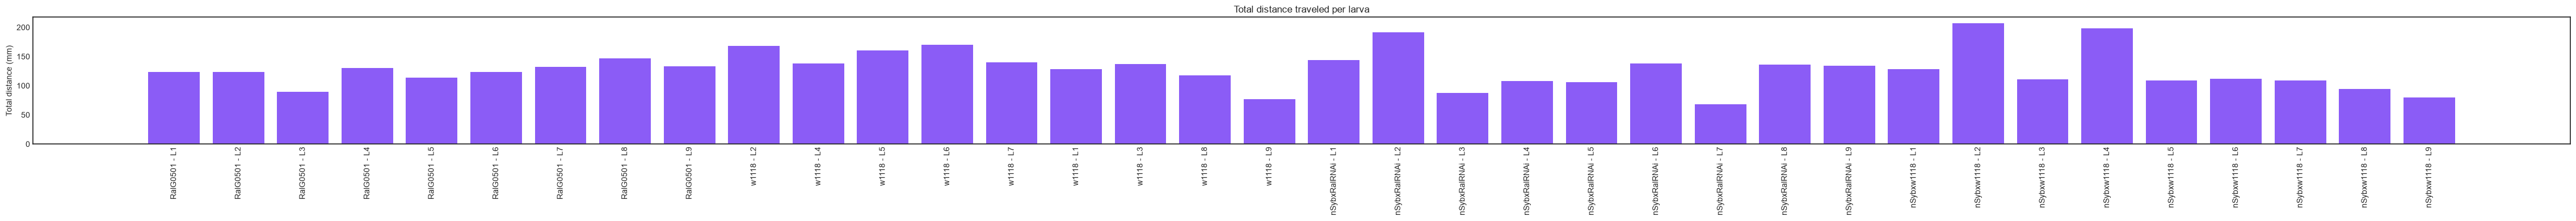

In [12]:
fig, ax = plt.subplots(figsize=(max(6, 0.5 * len(summary_table)), 4))
labels = [f"{row.get('genotype', '')} - {Path(f).stem}" for f, row in summary_table.iterrows()]
ax.bar(labels, summary_table["total_distance_mm"], color="#8B5CF6")
ax.set_ylabel("Total distance (mm)")
ax.set_title("Total distance traveled per larva")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


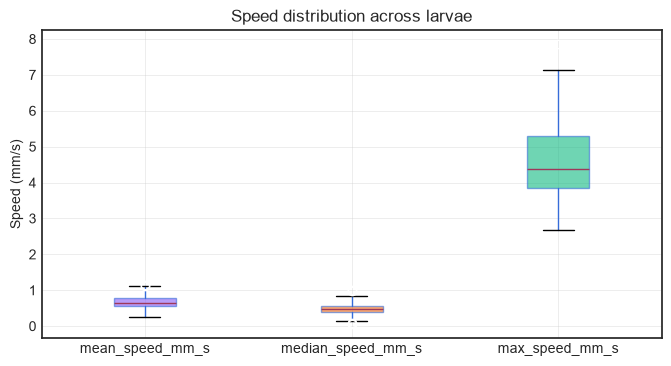

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
speed_cols = ["mean_speed_mm_s", "median_speed_mm_s", "max_speed_mm_s"]
bp = summary_table[speed_cols].boxplot(ax=ax, patch_artist=True, return_type='dict')
for patch, color in zip(bp["boxes"], ["#8B5CF6", "#F97316", "#10B981"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("Speed (mm/s)")
ax.set_title("Speed distribution across larvae")
plt.show()


### SuperPlots: Genotype Comparisons (Total Distance & Average Speed)

**100% Dynamic Discovery (Lord et al., 2020)**:
- **Zero hardcoding**: Genotypes are automatically discovered from the folder names on disk.
- **Comparison groups**: Inferred directly from the folder hierarchy, ignoring parent group folder names.
- **Individual larvae (dots with jitter)**: Colored by biological replicate (`N1`, `N2`, `N3`).
- **Replicate medians (large circles)**: Median of each biological replicate.
- **Grand Mean ± SEM**: Solid horizontal bar with error bars across biological replicates.
- **Automated statistics**: Shapiro-Wilk normality test, Levene variance test, and automated test selection (*Student t-test*, *Welch t-test*, or *Mann-Whitney U*).


Discovered 2 comparison group(s) from folder structure:
  Group 1: w1118 vs RalG0501
  Group 2: nSybxw1118 vs nSybxRalRNAi
STATISTICAL & NORMALITY REPORT: w1118 vs RalG0501 [Total distance (mm)]
1. Normality Assessment (Shapiro-Wilk test, alpha = 0.05):
   • w1118 (n=23): W = 0.9411, p = 0.1895 -> NORMAL (p >= 0.05)
   • RalG0501 (n=22): W = 0.9461, p = 0.2634 -> NORMAL (p >= 0.05)
   • Conclusion: Both distributions are normal -> Parametric test valid.
2. Homogeneity of Variances (Levene test):
   • Stat = 3.2416, p = 0.0788 -> Equal variances
3. Statistical Test Performed:
   • Test: Student t-test
   • Test Statistic = 0.5826
   • P-value = 0.56320 (ns)
   • Significance code: *** p < 0.001 | ** p < 0.01 | * p < 0.05 | ns p >= 0.05
4. Replicate-Level Test (N=3 vs 3 replicate medians):
   • t-test p-value = 0.7746

Saved plot: ..\data\results\superplot_w1118_vs_RalG0501_distance.png


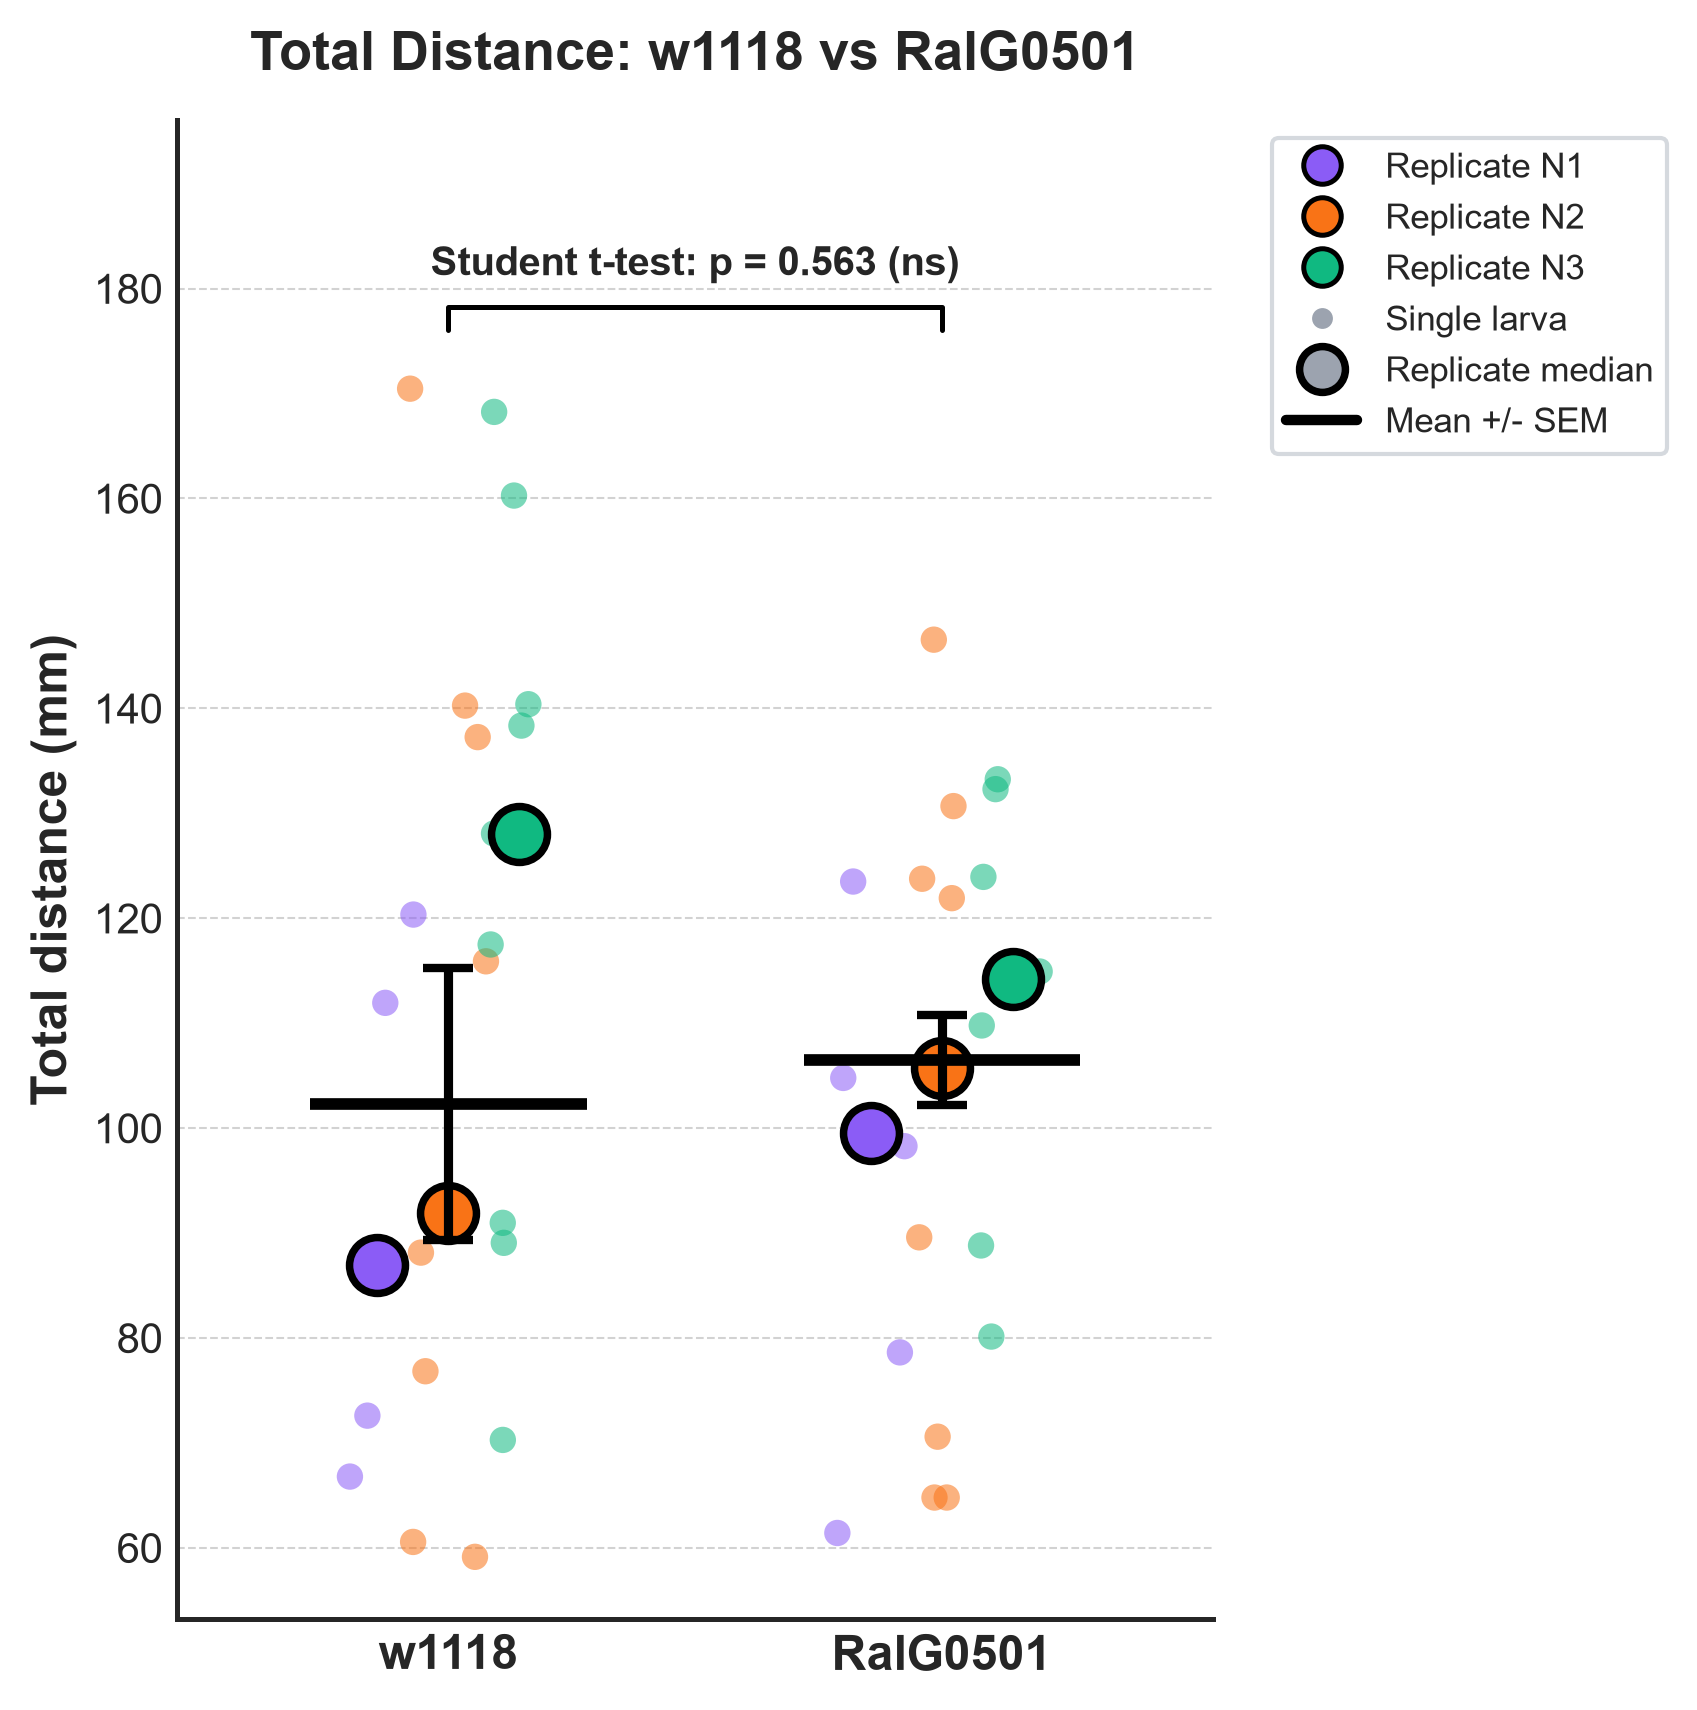

STATISTICAL & NORMALITY REPORT: w1118 vs RalG0501 [Average speed (mm/s)]
1. Normality Assessment (Shapiro-Wilk test, alpha = 0.05):
   • w1118 (n=23): W = 0.9220, p = 0.0737 -> NORMAL (p >= 0.05)
   • RalG0501 (n=22): W = 0.9841, p = 0.9675 -> NORMAL (p >= 0.05)
   • Conclusion: Both distributions are normal -> Parametric test valid.
2. Homogeneity of Variances (Levene test):
   • Stat = 3.5813, p = 0.0652 -> Equal variances
3. Statistical Test Performed:
   • Test: Student t-test
   • Test Statistic = 2.3918
   • P-value = 0.02121 (*)
   • Significance code: *** p < 0.001 | ** p < 0.01 | * p < 0.05 | ns p >= 0.05
4. Replicate-Level Test (N=3 vs 3 replicate medians):
   • t-test p-value = 0.2300

Saved plot: ..\data\results\superplot_w1118_vs_RalG0501_speed.png


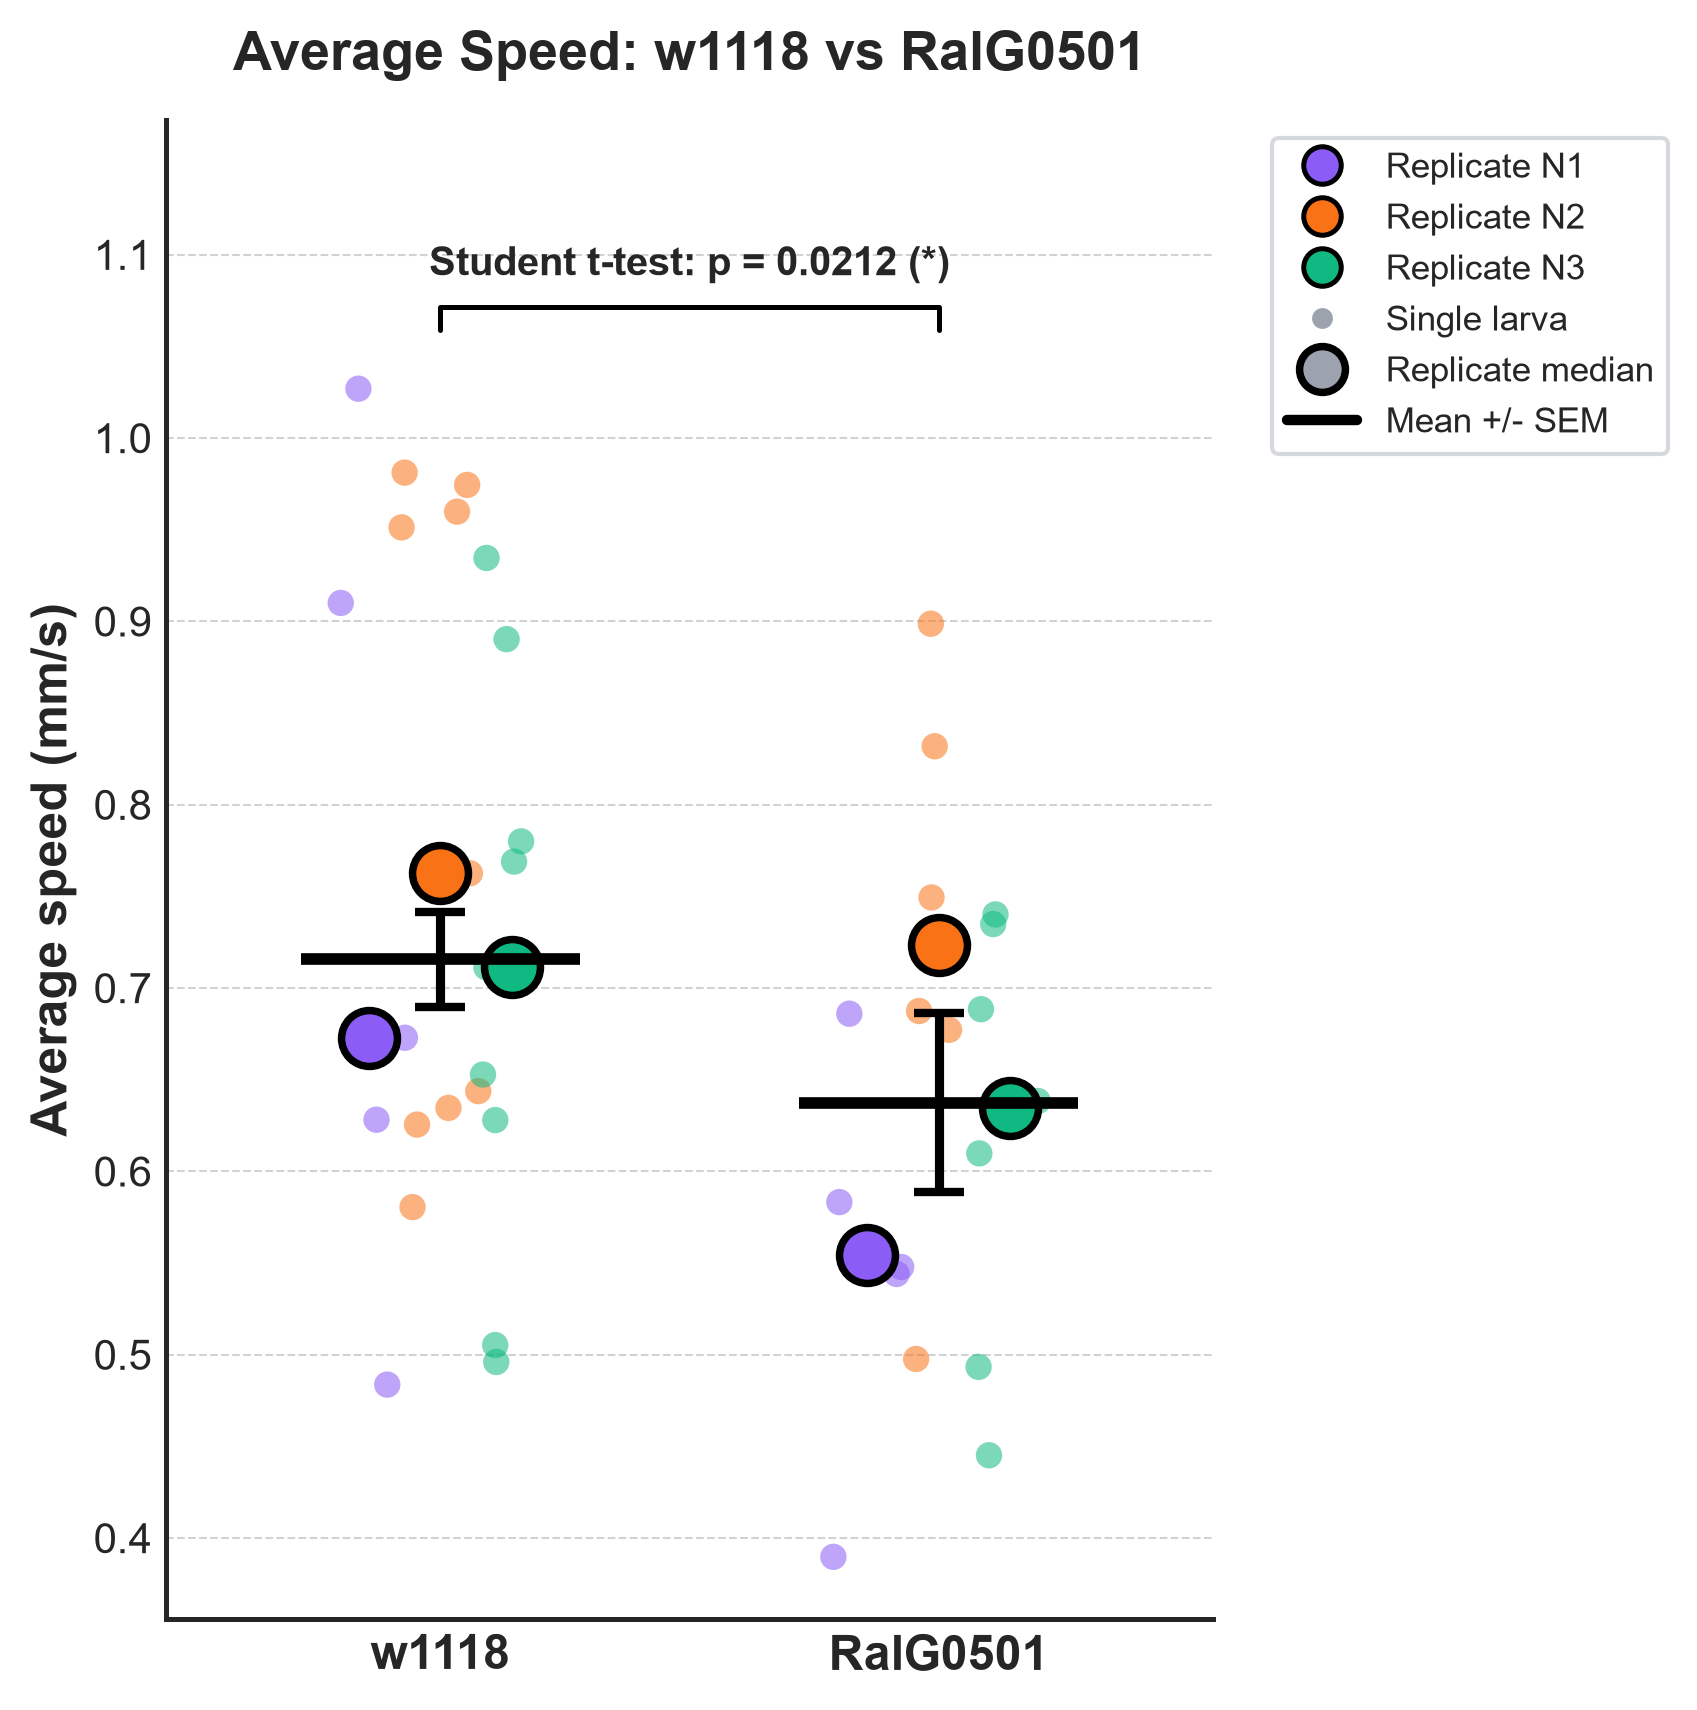

STATISTICAL & NORMALITY REPORT: nSybxw1118 vs nSybxRalRNAi [Total distance (mm)]
1. Normality Assessment (Shapiro-Wilk test, alpha = 0.05):
   • nSybxw1118 (n=22): W = 0.9062, p = 0.0397 -> NOT NORMAL (p < 0.05)
   • nSybxRalRNAi (n=24): W = 0.9109, p = 0.0369 -> NOT NORMAL (p < 0.05)
   • Conclusion: At least one distribution is non-normal -> Non-parametric test recommended.
2. Homogeneity of Variances (Levene test):
   • Stat = 0.7233, p = 0.3997 -> Equal variances
3. Statistical Test Performed:
   • Test: Mann-Whitney U
   • Test Statistic = 288.0000
   • P-value = 0.60532 (ns)
   • Significance code: *** p < 0.001 | ** p < 0.01 | * p < 0.05 | ns p >= 0.05
4. Replicate-Level Test (N=3 vs 3 replicate medians):
   • t-test p-value = 0.6170

Saved plot: ..\data\results\superplot_nSybxw1118_vs_nSybxRalRNAi_distance.png


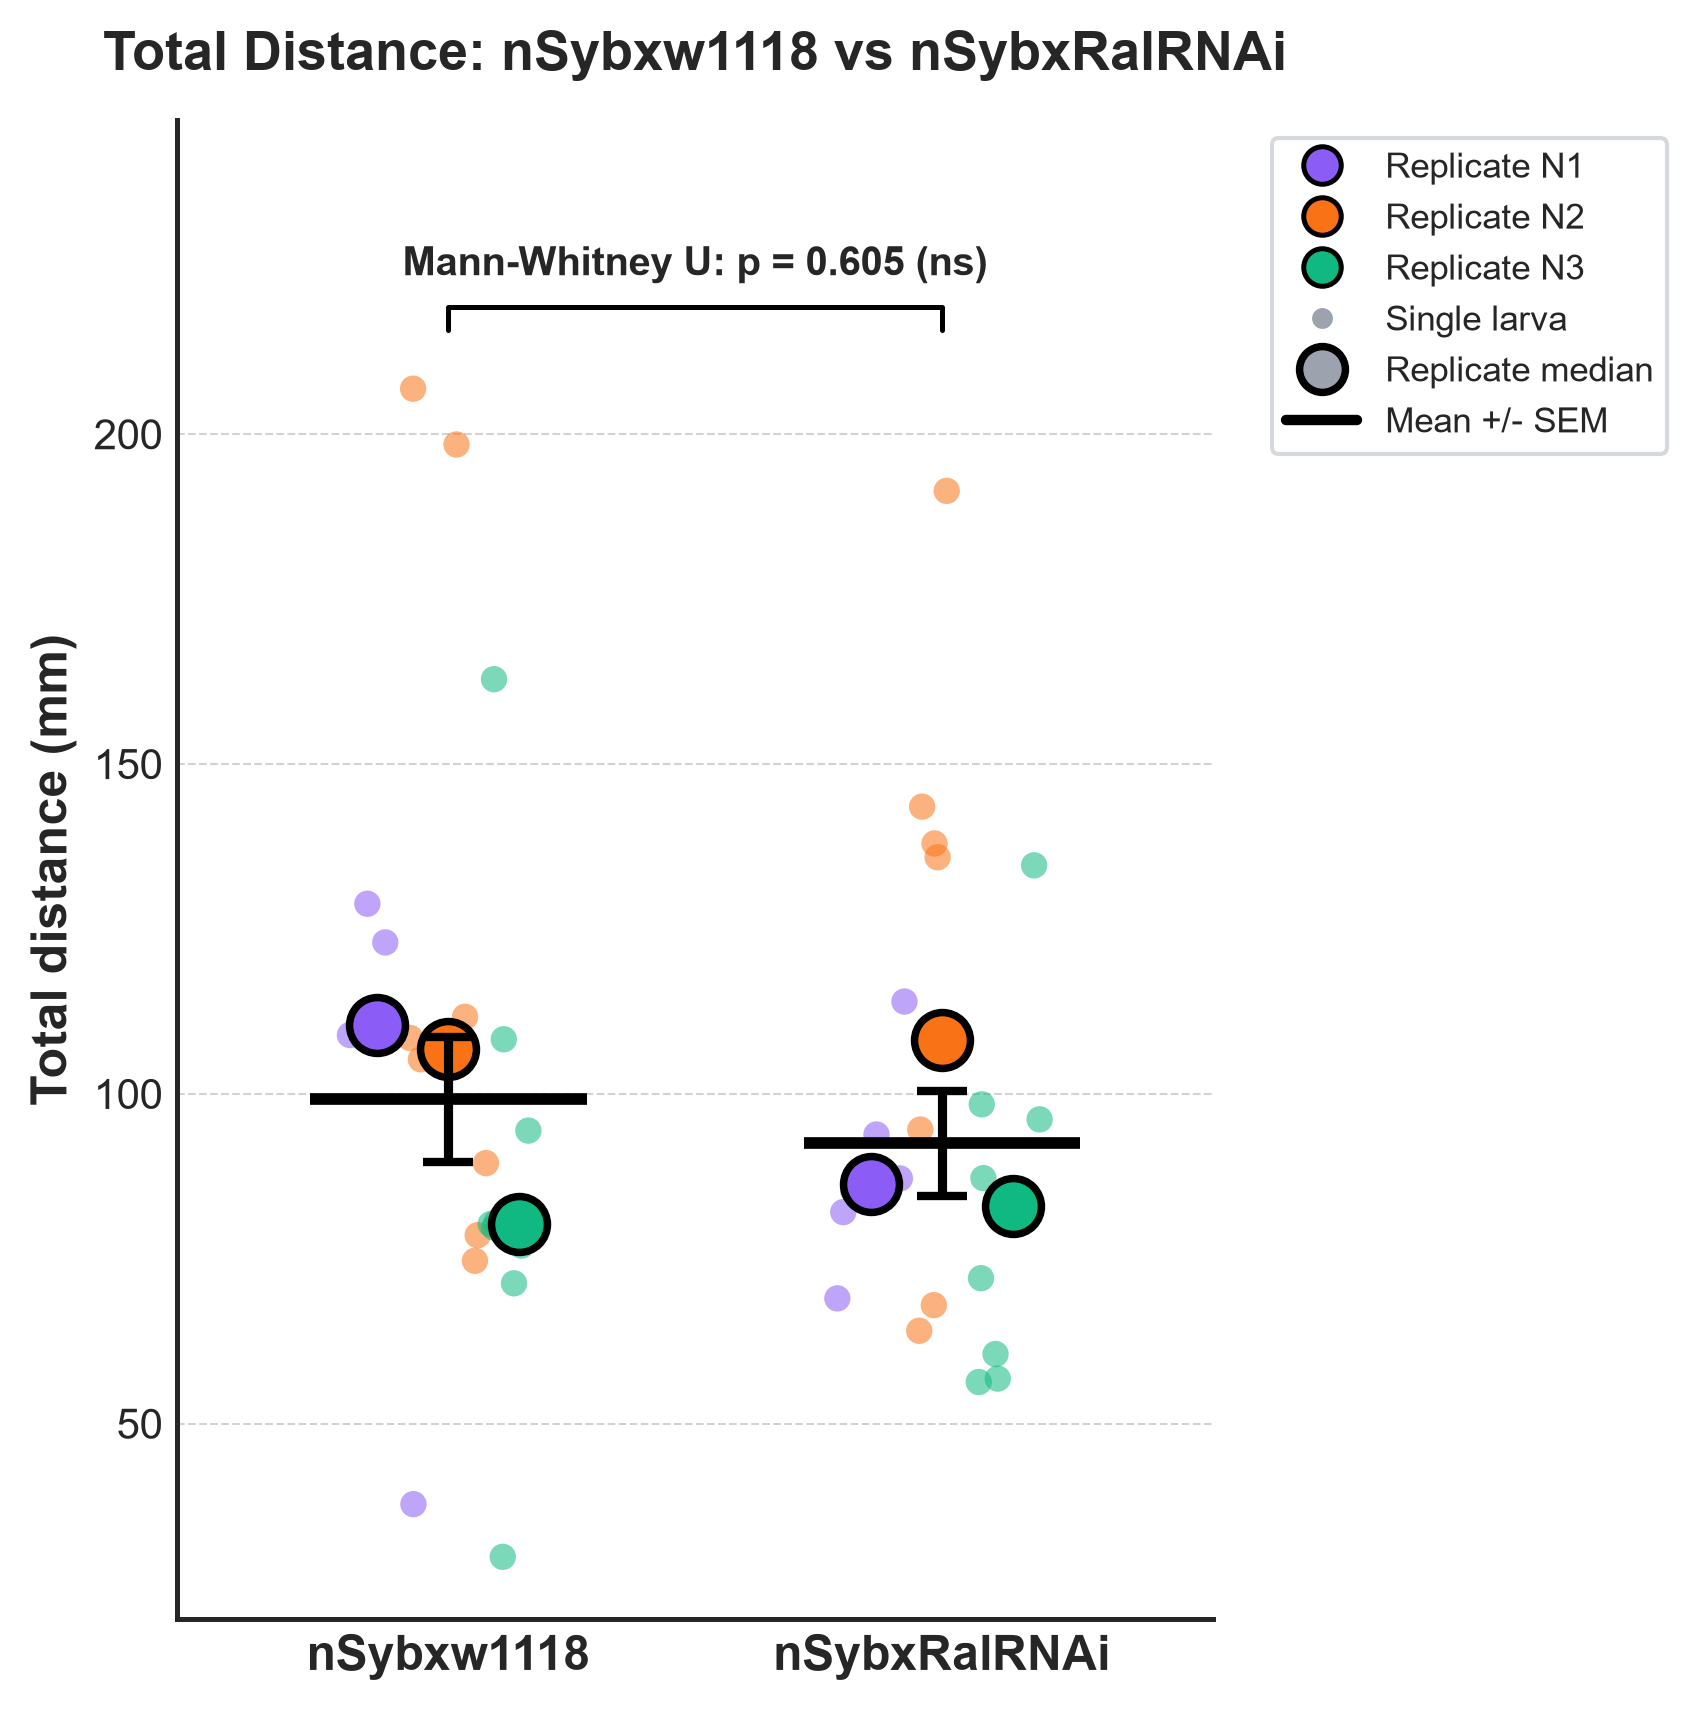

STATISTICAL & NORMALITY REPORT: nSybxw1118 vs nSybxRalRNAi [Average speed (mm/s)]
1. Normality Assessment (Shapiro-Wilk test, alpha = 0.05):
   • nSybxw1118 (n=22): W = 0.9317, p = 0.1334 -> NORMAL (p >= 0.05)
   • nSybxRalRNAi (n=24): W = 0.9789, p = 0.8754 -> NORMAL (p >= 0.05)
   • Conclusion: Both distributions are normal -> Parametric test valid.
2. Homogeneity of Variances (Levene test):
   • Stat = 0.0804, p = 0.7780 -> Equal variances
3. Statistical Test Performed:
   • Test: Student t-test
   • Test Statistic = -0.6718
   • P-value = 0.50525 (ns)
   • Significance code: *** p < 0.001 | ** p < 0.01 | * p < 0.05 | ns p >= 0.05
4. Replicate-Level Test (N=3 vs 3 replicate medians):
   • t-test p-value = 0.3288

Saved plot: ..\data\results\superplot_nSybxw1118_vs_nSybxRalRNAi_speed.png


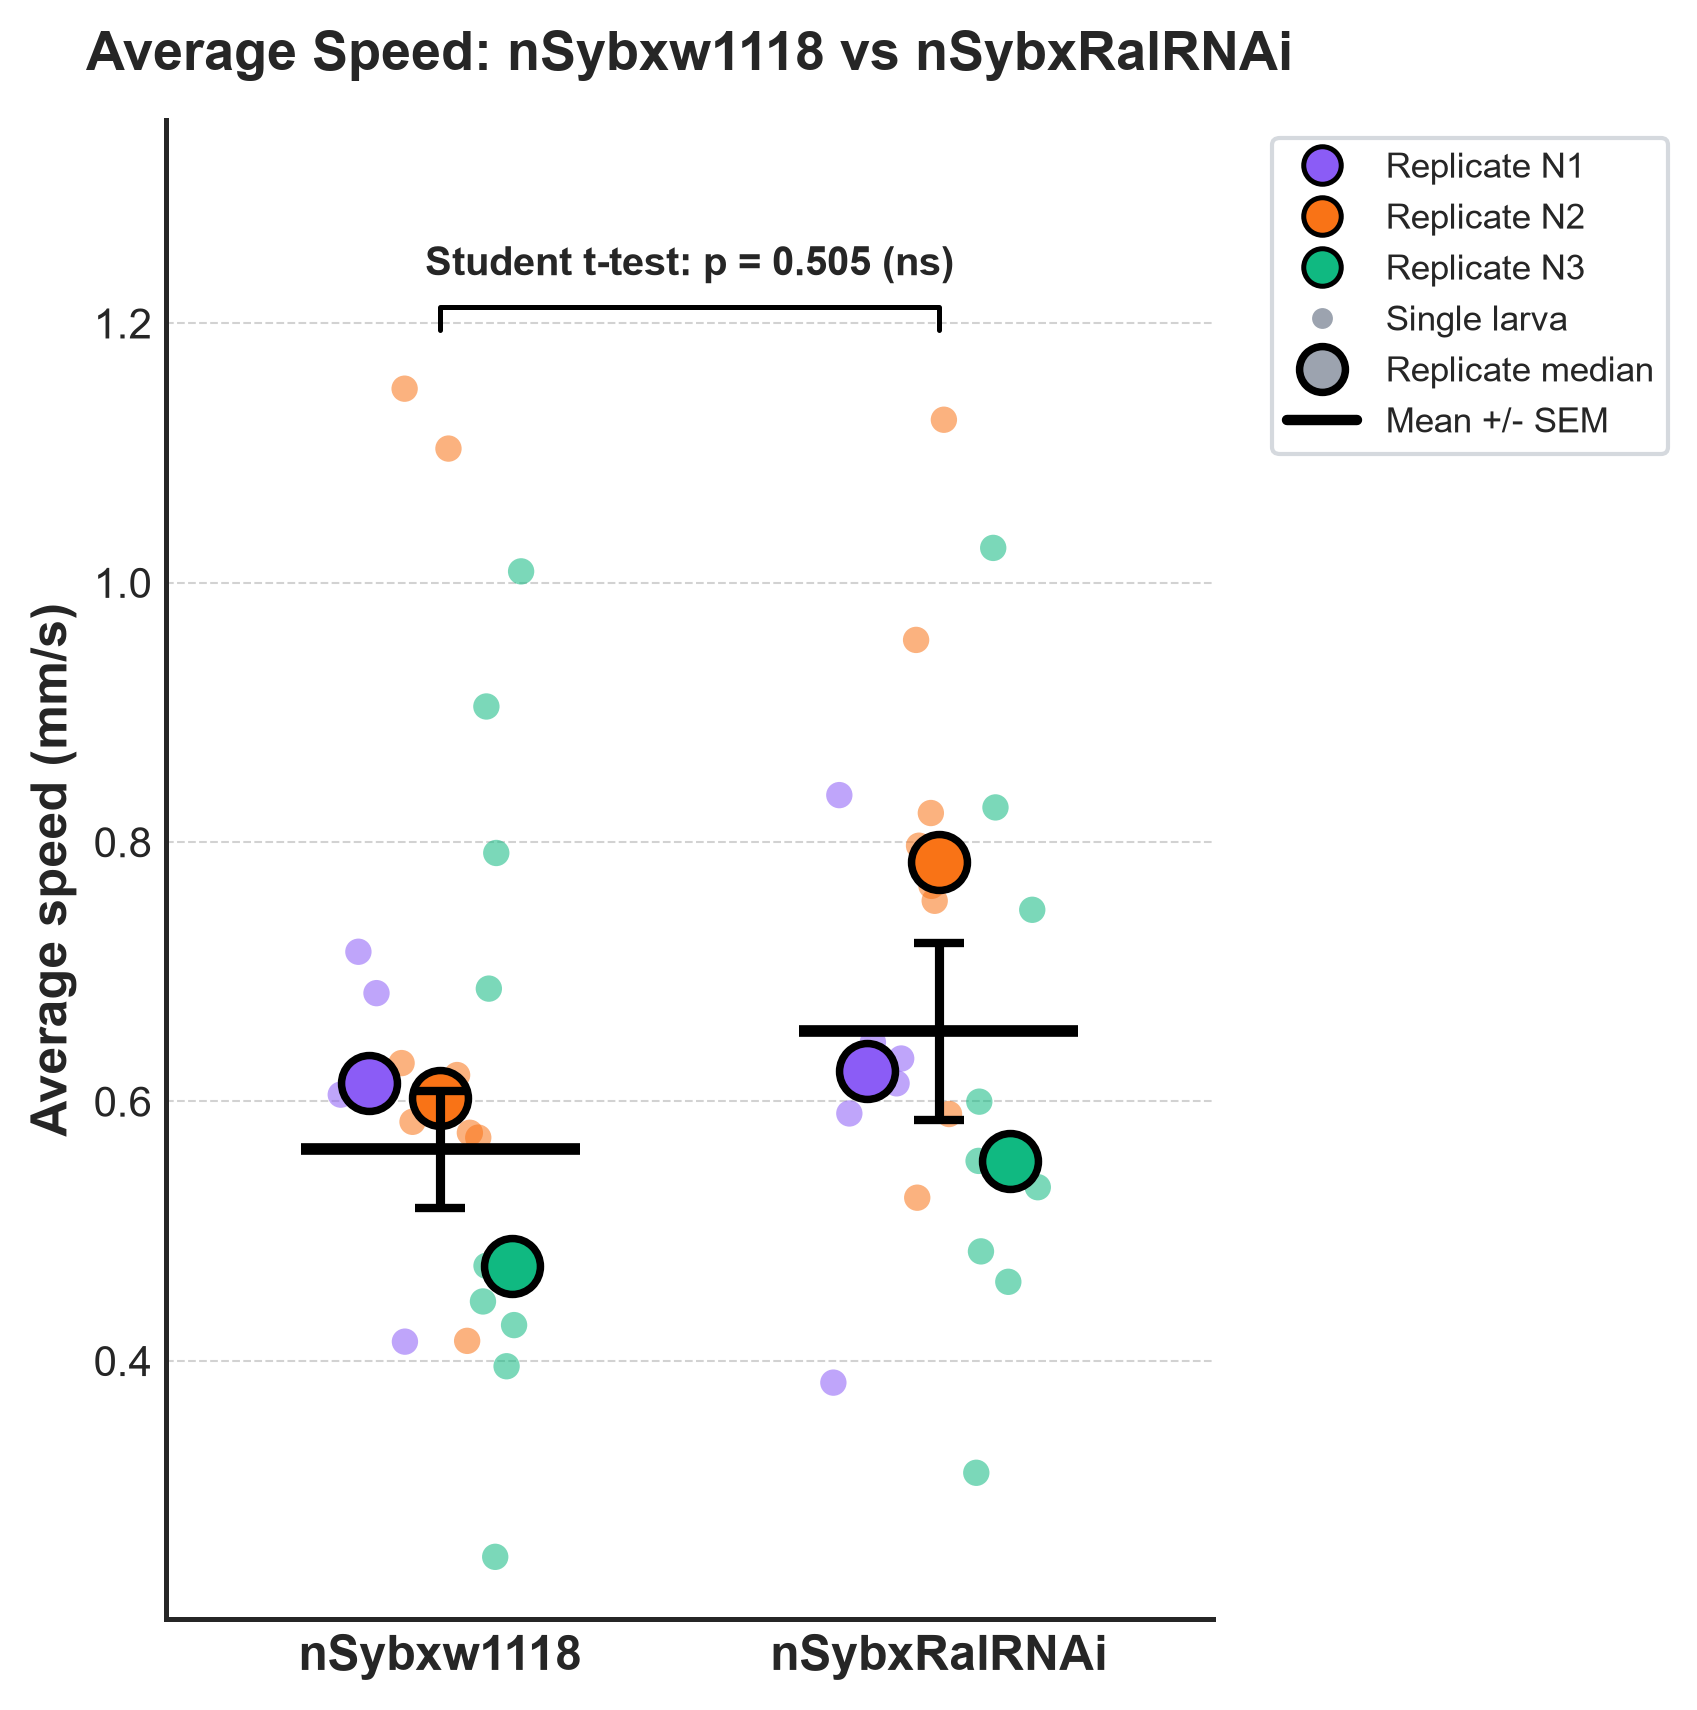

In [14]:
from pathlib import Path
import matplotlib.pyplot as plt
import importlib
import larva_analysis
importlib.reload(larva_analysis)
from larva_analysis import plot_superplot, discover_comparisons

# Ensure results_folder is defined and exists
if 'results_folder' not in globals() or not results_folder.exists():
    candidate_folders = [Path('../data/results'), Path('data/results'), Path('results'), Path('.')]
    results_folder = next((p for p in candidate_folders if p.exists()), Path('../data/results'))
    results_folder.mkdir(parents=True, exist_ok=True)

# =========================================================================
# 1. Dynamic Discovery: Scan folders to identify comparison groups & genotypes
# =========================================================================
comparisons = discover_comparisons(CSV_FOLDER)

print(f'Discovered {len(comparisons)} comparison group(s) from folder structure:')
for i, comp in enumerate(comparisons, 1):
    print(f'  Group {i}: {" vs ".join(comp)}')

# Generate Individual SuperPlots for each discovered comparison group
for comp in comparisons:
    label_str = ' vs '.join(comp)
    file_suffix = '_vs_'.join(comp)

    # 1. Total Distance
    fig_d, ax_d = plot_superplot(
        summary_table,
        genotypes=comp,
        metric='total_distance_mm',
        ylabel='Total distance (mm)',
        title=f'Total Distance: {label_str}',
        show_stat_test=True,
        show_legend=True,
        save_path=results_folder / f'superplot_{file_suffix}_distance.png'
    )
    plt.show()

    # 2. Average Speed
    fig_s, ax_s = plot_superplot(
        summary_table,
        genotypes=comp,
        metric='mean_speed_mm_s',
        ylabel='Average speed (mm/s)',
        title=f'Average Speed: {label_str}',
        show_stat_test=True,
        show_legend=True,
        save_path=results_folder / f'superplot_{file_suffix}_speed.png'
    )
    plt.show()


STATISTICAL & NORMALITY REPORT: w1118 vs RalG0501 [Total distance (mm)]
1. Normality Assessment (Shapiro-Wilk test, alpha = 0.05):
   • w1118 (n=23): W = 0.9411, p = 0.1895 -> NORMAL (p >= 0.05)
   • RalG0501 (n=22): W = 0.9461, p = 0.2634 -> NORMAL (p >= 0.05)
   • Conclusion: Both distributions are normal -> Parametric test valid.
2. Homogeneity of Variances (Levene test):
   • Stat = 3.2416, p = 0.0788 -> Equal variances
3. Statistical Test Performed:
   • Test: Student t-test
   • Test Statistic = 0.5826
   • P-value = 0.56320 (ns)
   • Significance code: *** p < 0.001 | ** p < 0.01 | * p < 0.05 | ns p >= 0.05
4. Replicate-Level Test (N=3 vs 3 replicate medians):
   • t-test p-value = 0.7746

STATISTICAL & NORMALITY REPORT: nSybxw1118 vs nSybxRalRNAi [Total distance (mm)]
1. Normality Assessment (Shapiro-Wilk test, alpha = 0.05):
   • nSybxw1118 (n=22): W = 0.9062, p = 0.0397 -> NOT NORMAL (p < 0.05)
   • nSybxRalRNAi (n=24): W = 0.9109, p = 0.0369 -> NOT NORMAL (p < 0.05)
   • Con

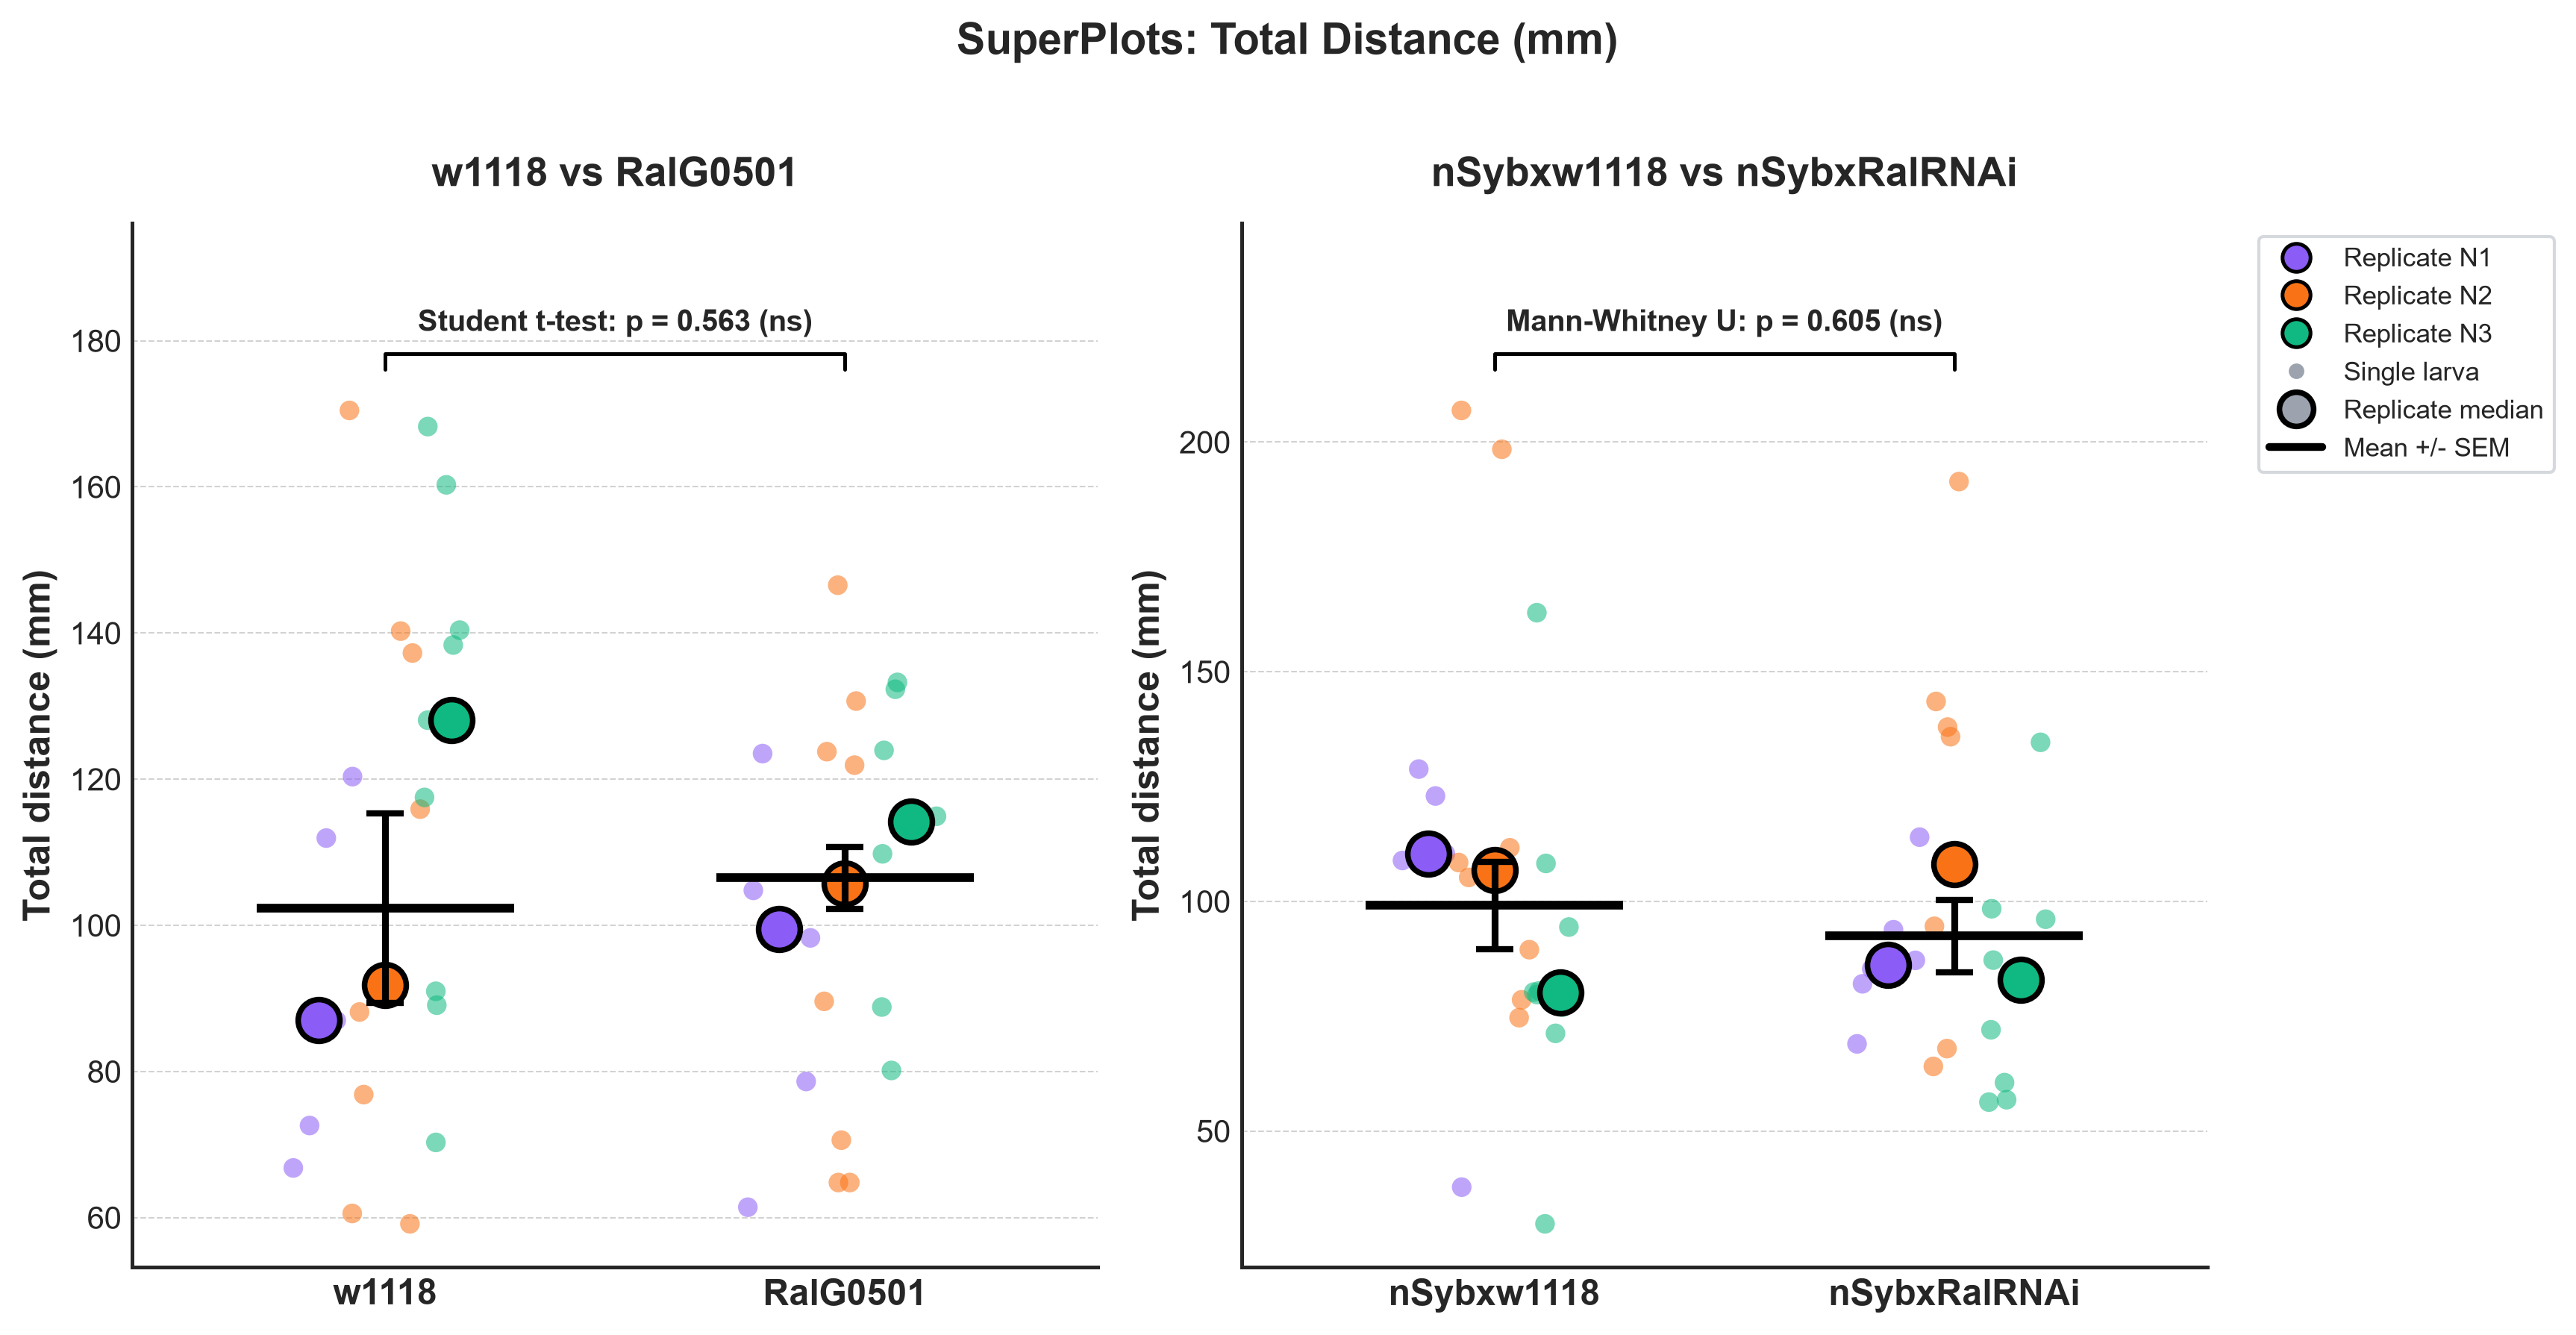

STATISTICAL & NORMALITY REPORT: w1118 vs RalG0501 [Average speed (mm/s)]
1. Normality Assessment (Shapiro-Wilk test, alpha = 0.05):
   • w1118 (n=23): W = 0.9220, p = 0.0737 -> NORMAL (p >= 0.05)
   • RalG0501 (n=22): W = 0.9841, p = 0.9675 -> NORMAL (p >= 0.05)
   • Conclusion: Both distributions are normal -> Parametric test valid.
2. Homogeneity of Variances (Levene test):
   • Stat = 3.5813, p = 0.0652 -> Equal variances
3. Statistical Test Performed:
   • Test: Student t-test
   • Test Statistic = 2.3918
   • P-value = 0.02121 (*)
   • Significance code: *** p < 0.001 | ** p < 0.01 | * p < 0.05 | ns p >= 0.05
4. Replicate-Level Test (N=3 vs 3 replicate medians):
   • t-test p-value = 0.2300

STATISTICAL & NORMALITY REPORT: nSybxw1118 vs nSybxRalRNAi [Average speed (mm/s)]
1. Normality Assessment (Shapiro-Wilk test, alpha = 0.05):
   • nSybxw1118 (n=22): W = 0.9317, p = 0.1334 -> NORMAL (p >= 0.05)
   • nSybxRalRNAi (n=24): W = 0.9789, p = 0.8754 -> NORMAL (p >= 0.05)
   • Conclusi

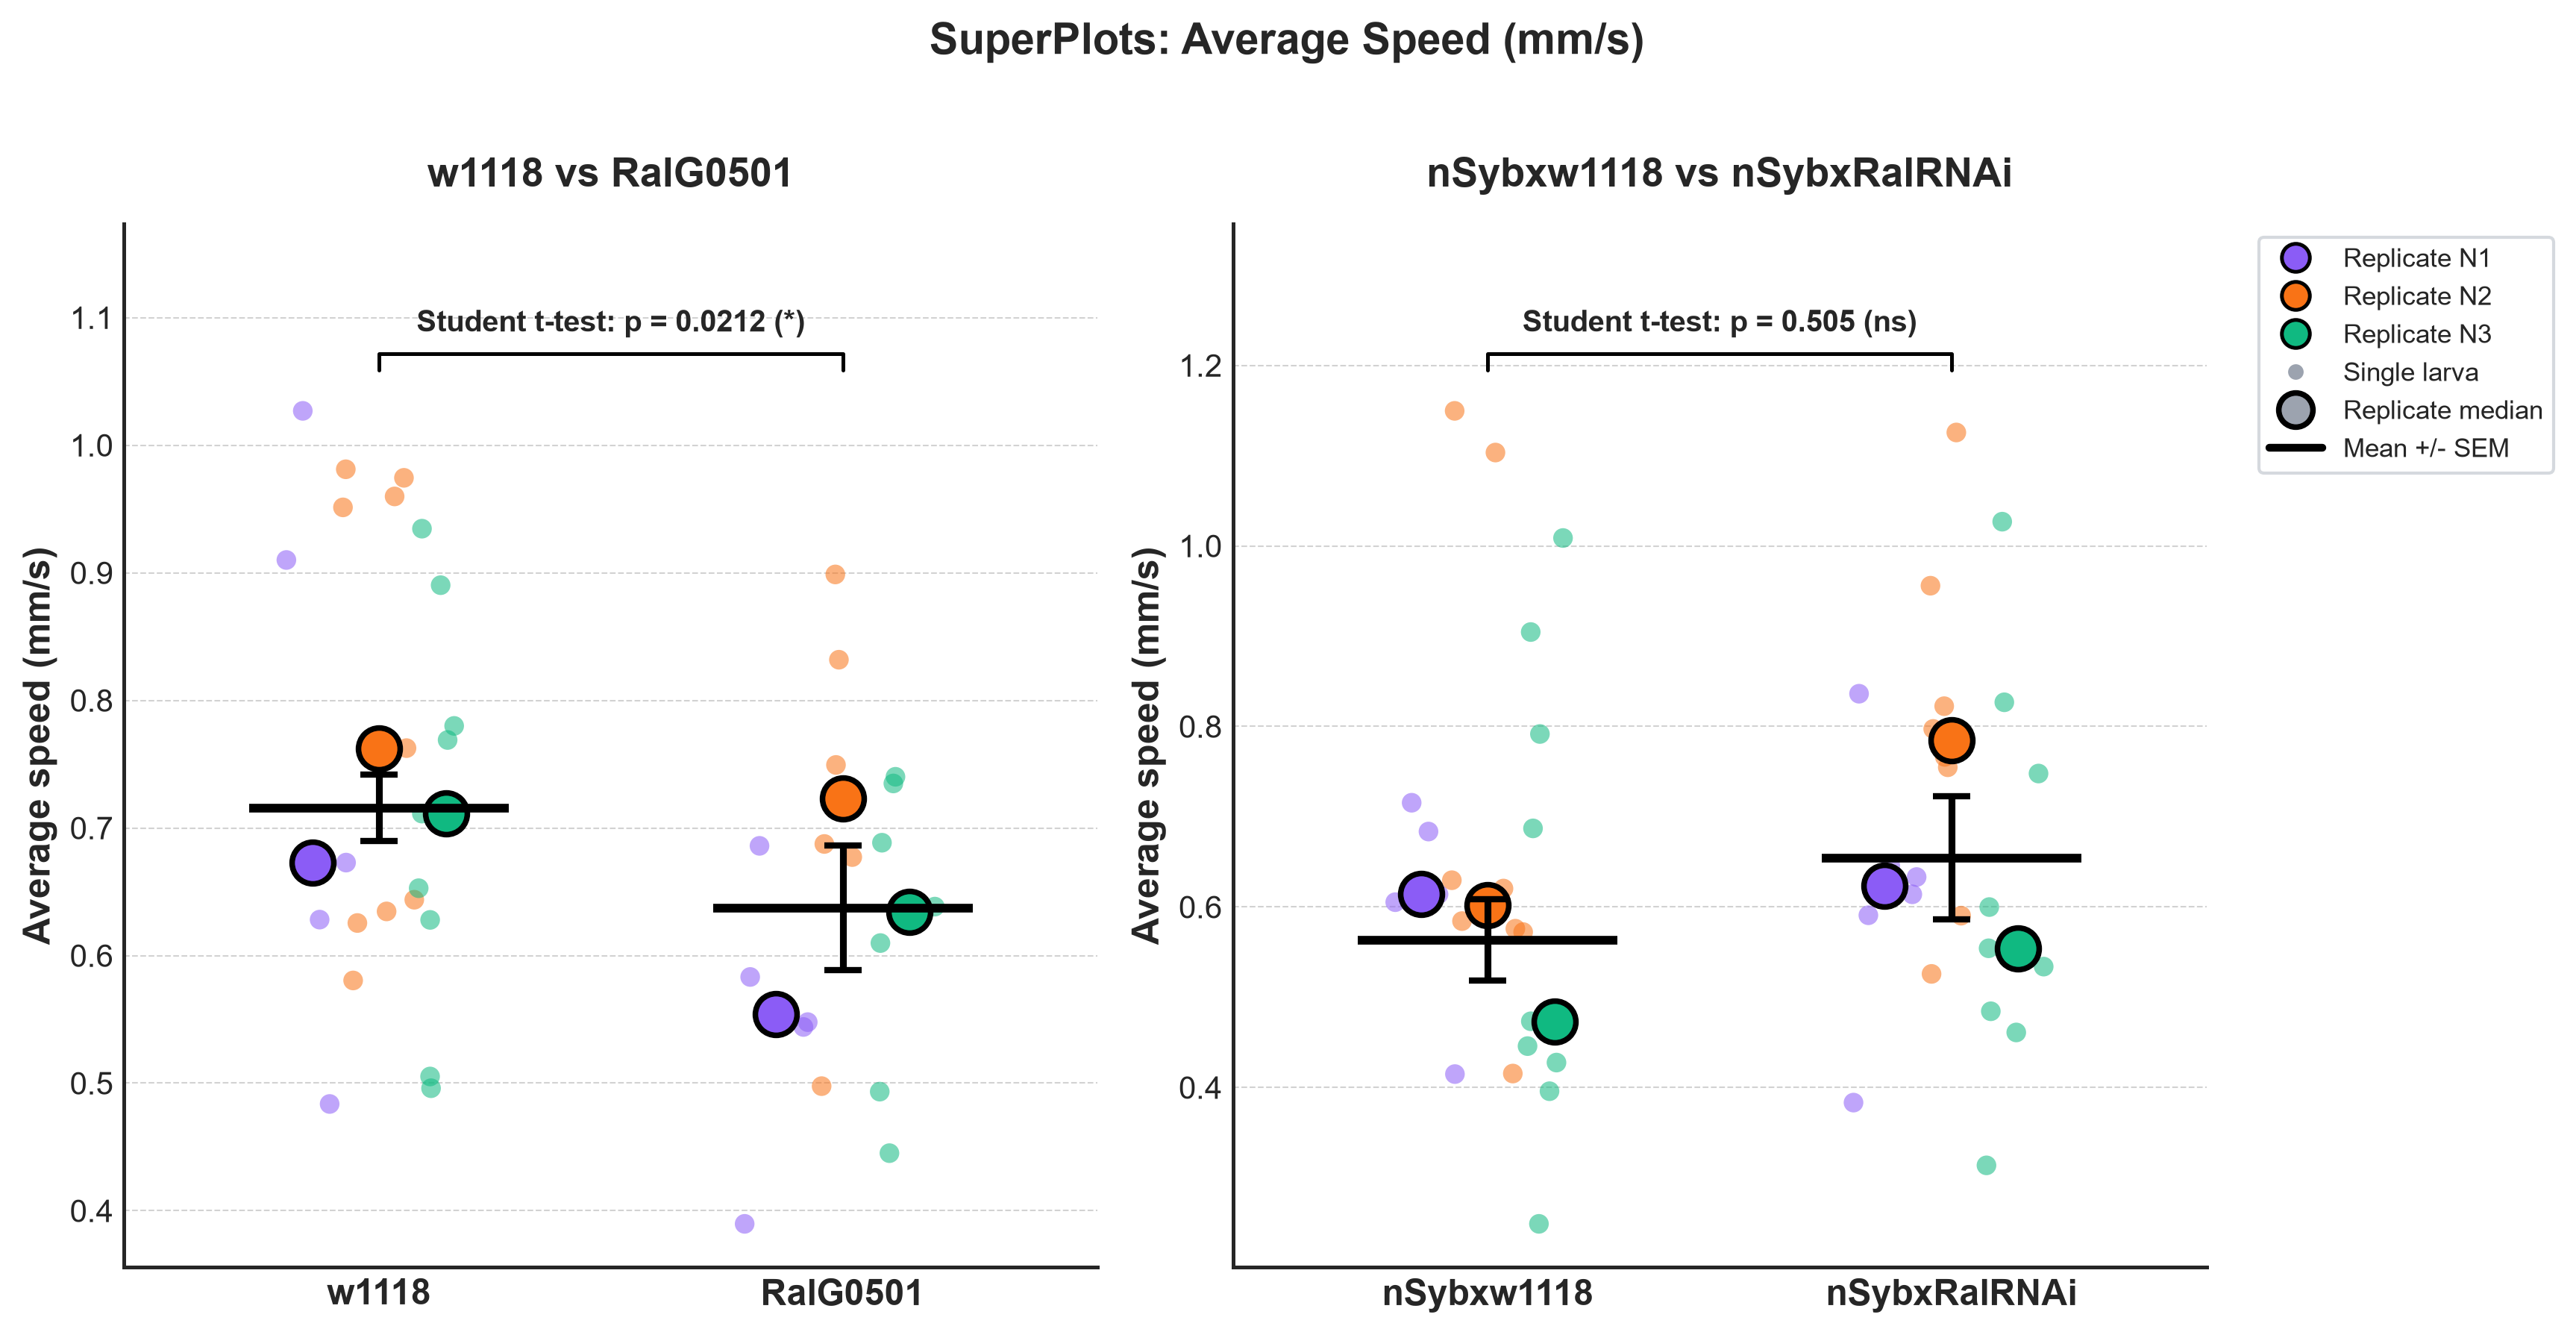

In [15]:
# =========================================================================
# 2. Multi-Panel Side-by-Side Comparisons (Publication-Ready)
# Dynamically arranges all discovered comparison groups side-by-side
# =========================================================================
if len(comparisons) >= 2:
    n_groups = len(comparisons)

    # --- Total Distance Multi-Panel ---
    fig_dist, axes_dist = plt.subplots(1, n_groups, figsize=(5.8 * n_groups, 5.8), dpi=300)
    for idx, (comp, ax) in enumerate(zip(comparisons, axes_dist)):
        plot_superplot(
            summary_table,
            genotypes=comp,
            metric='total_distance_mm',
            ylabel='Total distance (mm)',
            title=' vs '.join(comp),
            ax=ax,
            show_legend=(idx == n_groups - 1),
            print_stat_report=True
        )
    fig_dist.suptitle('SuperPlots: Total Distance (mm)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    fig_dist.savefig(results_folder / 'superplot_distance_comparisons.png', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

    # --- Average Speed Multi-Panel ---
    fig_spd, axes_spd = plt.subplots(1, n_groups, figsize=(5.8 * n_groups, 5.8), dpi=300)
    for idx, (comp, ax) in enumerate(zip(comparisons, axes_spd)):
        plot_superplot(
            summary_table,
            genotypes=comp,
            metric='mean_speed_mm_s',
            ylabel='Average speed (mm/s)',
            title=' vs '.join(comp),
            ax=ax,
            show_legend=(idx == n_groups - 1),
            print_stat_report=True
        )
    fig_spd.suptitle('SuperPlots: Average Speed (mm/s)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    fig_spd.savefig(results_folder / 'superplot_speed_comparisons.png', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()


Saved plot: ..\data\results\superplot_all_genotypes_distance.png


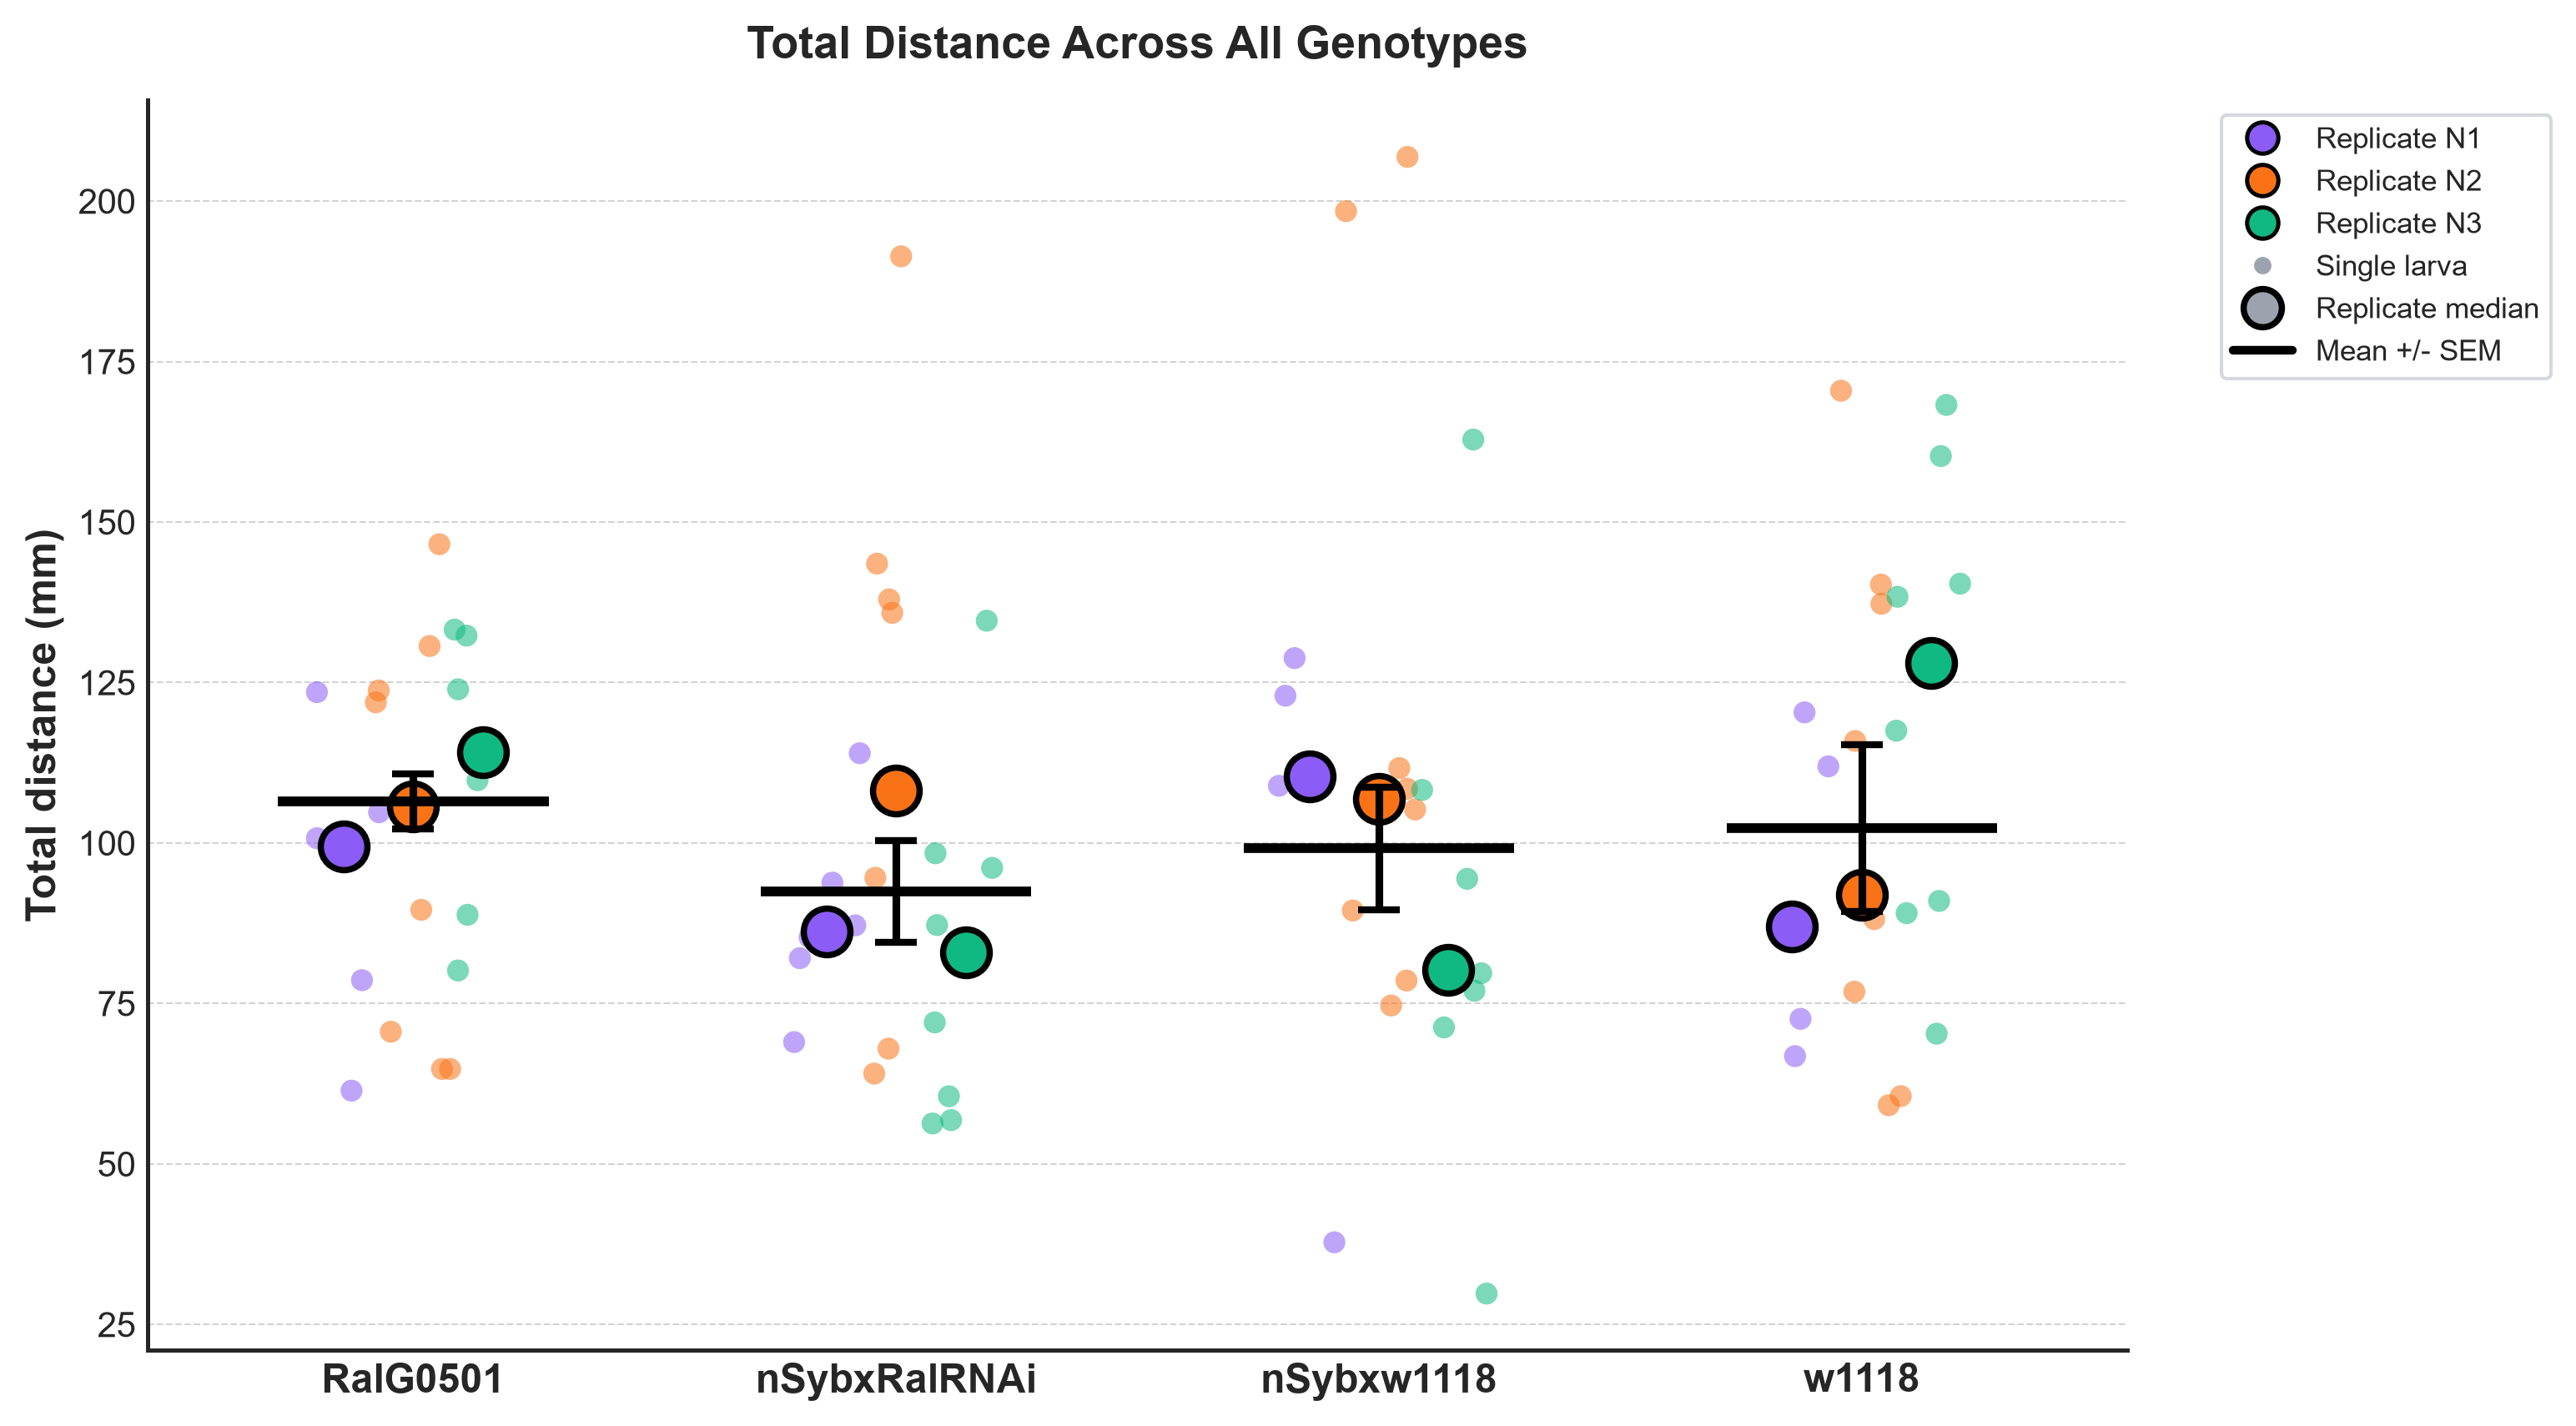

Saved plot: ..\data\results\superplot_all_genotypes_speed.png


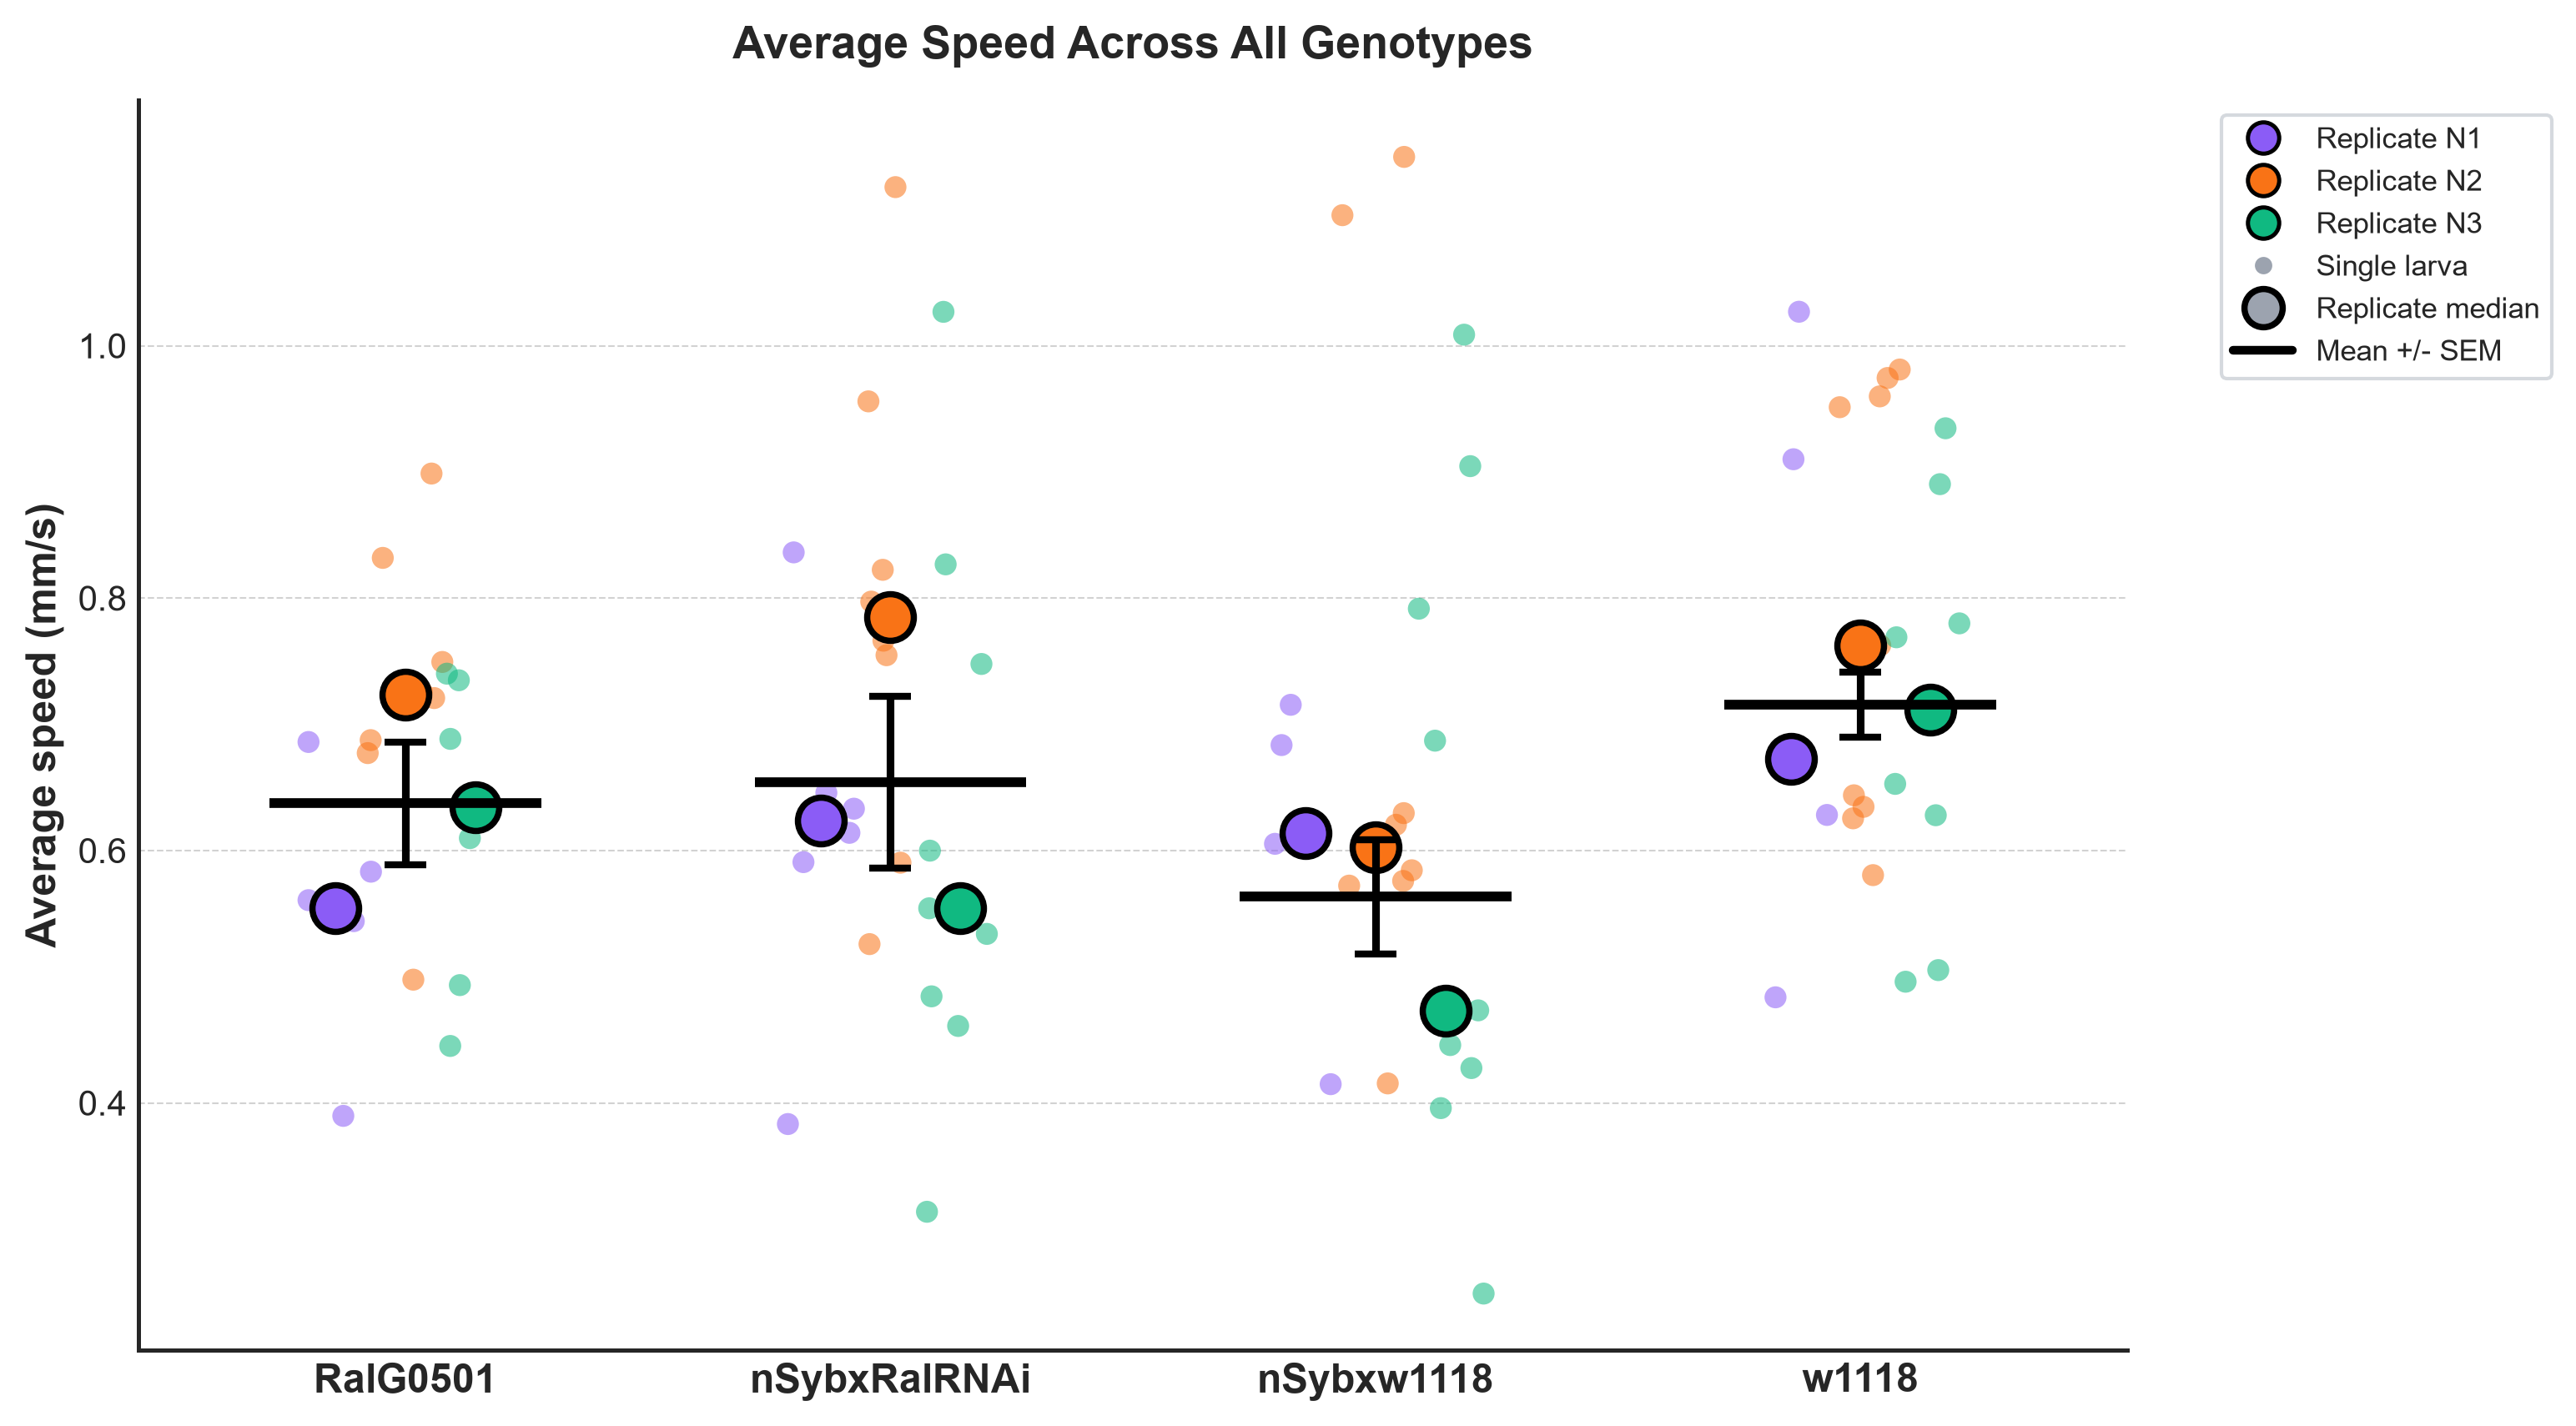

In [16]:
# =========================================================================
# 3. Global Multi-Genotype SuperPlots (All Genotypes on single axis)
# Automatically grabs all unique genotypes found in the dataset
# =========================================================================
all_genotypes = sorted(summary_table['genotype'].dropna().unique().tolist())

# All Genotypes - Total Distance
plot_superplot(
    summary_table,
    genotypes=all_genotypes,
    metric='total_distance_mm',
    ylabel='Total distance (mm)',
    title='Total Distance Across All Genotypes',
    show_stat_test=False,
    show_legend=True,
    save_path=results_folder / 'superplot_all_genotypes_distance.png'
)
plt.show()

# All Genotypes - Average Speed
plot_superplot(
    summary_table,
    genotypes=all_genotypes,
    metric='mean_speed_mm_s',
    ylabel='Average speed (mm/s)',
    title='Average Speed Across All Genotypes',
    show_stat_test=False,
    show_legend=True,
    save_path=results_folder / 'superplot_all_genotypes_speed.png'
)
plt.show()


### Average Speed Over Time (Mean of Replicate Means)

Plots the average speed trajectory over time for each genotype comparison group dynamically discovered from folder hierarchy.
- **X-axis:** Time (s)
- **Y-axis:** Average speed (mm/s)
- **Hierarchy:** Computes the mean speed across larvae within each biological replicate (N1, N2, N3...) per epoch, then calculates the **grand mean curve across biological replicates**.
- **Shaded Error Band:** Standard Error of the Mean (SEM) or Standard Deviation (SD) across biological replicates.
- **Statistical Tests & Rationale:** Performs Shapiro-Wilk test for normality and Levene test for equal variance on replicate means, selects the appropriate hypothesis test (Student/Welch t-test or Mann-Whitney U), and presents scientific justification for choosing SD vs SEM.
- **Dynamic:** Zero hardcoded names; parent grouping folders are completely ignored.


  STATISTICAL REPORT: AVERAGE SPEED OVER TIME (w1118 vs RalG0501)
Hierarchical Summary (mean of replicate means, N=3 vs N=3 biological replicates):
  * w1118          : Mean = 0.6970 mm/s | SD = 0.0730 | SEM = 0.0422 | Shapiro-Wilk p = 0.5082
  * RalG0501       : Mean = 0.6423 mm/s | SD = 0.0681 | SEM = 0.0393 | Shapiro-Wilk p = 0.8712
Homogeneity of Variance (Levene's test): p = 0.9645 (Equal variance confirmed)
Normality Outcome: Normal distribution (p > 0.05)
Hypothesis Test Selected: Two-sample Student's t-test
Significance: p = 0.3967 [ns]
------------------------------------------------------------------------
SCIENTIFIC JUSTIFICATION: SD vs SEM
  - SD (Standard Deviation): Quantifies the direct biological spread / variability
    between experimental cohorts. Use SD when the objective is to describe the
    variation inherent to the biological population.
  - SEM (Standard Error of the Mean = SD / sqrt(N)): Quantifies the precision of the
    estimated population mean. It direct

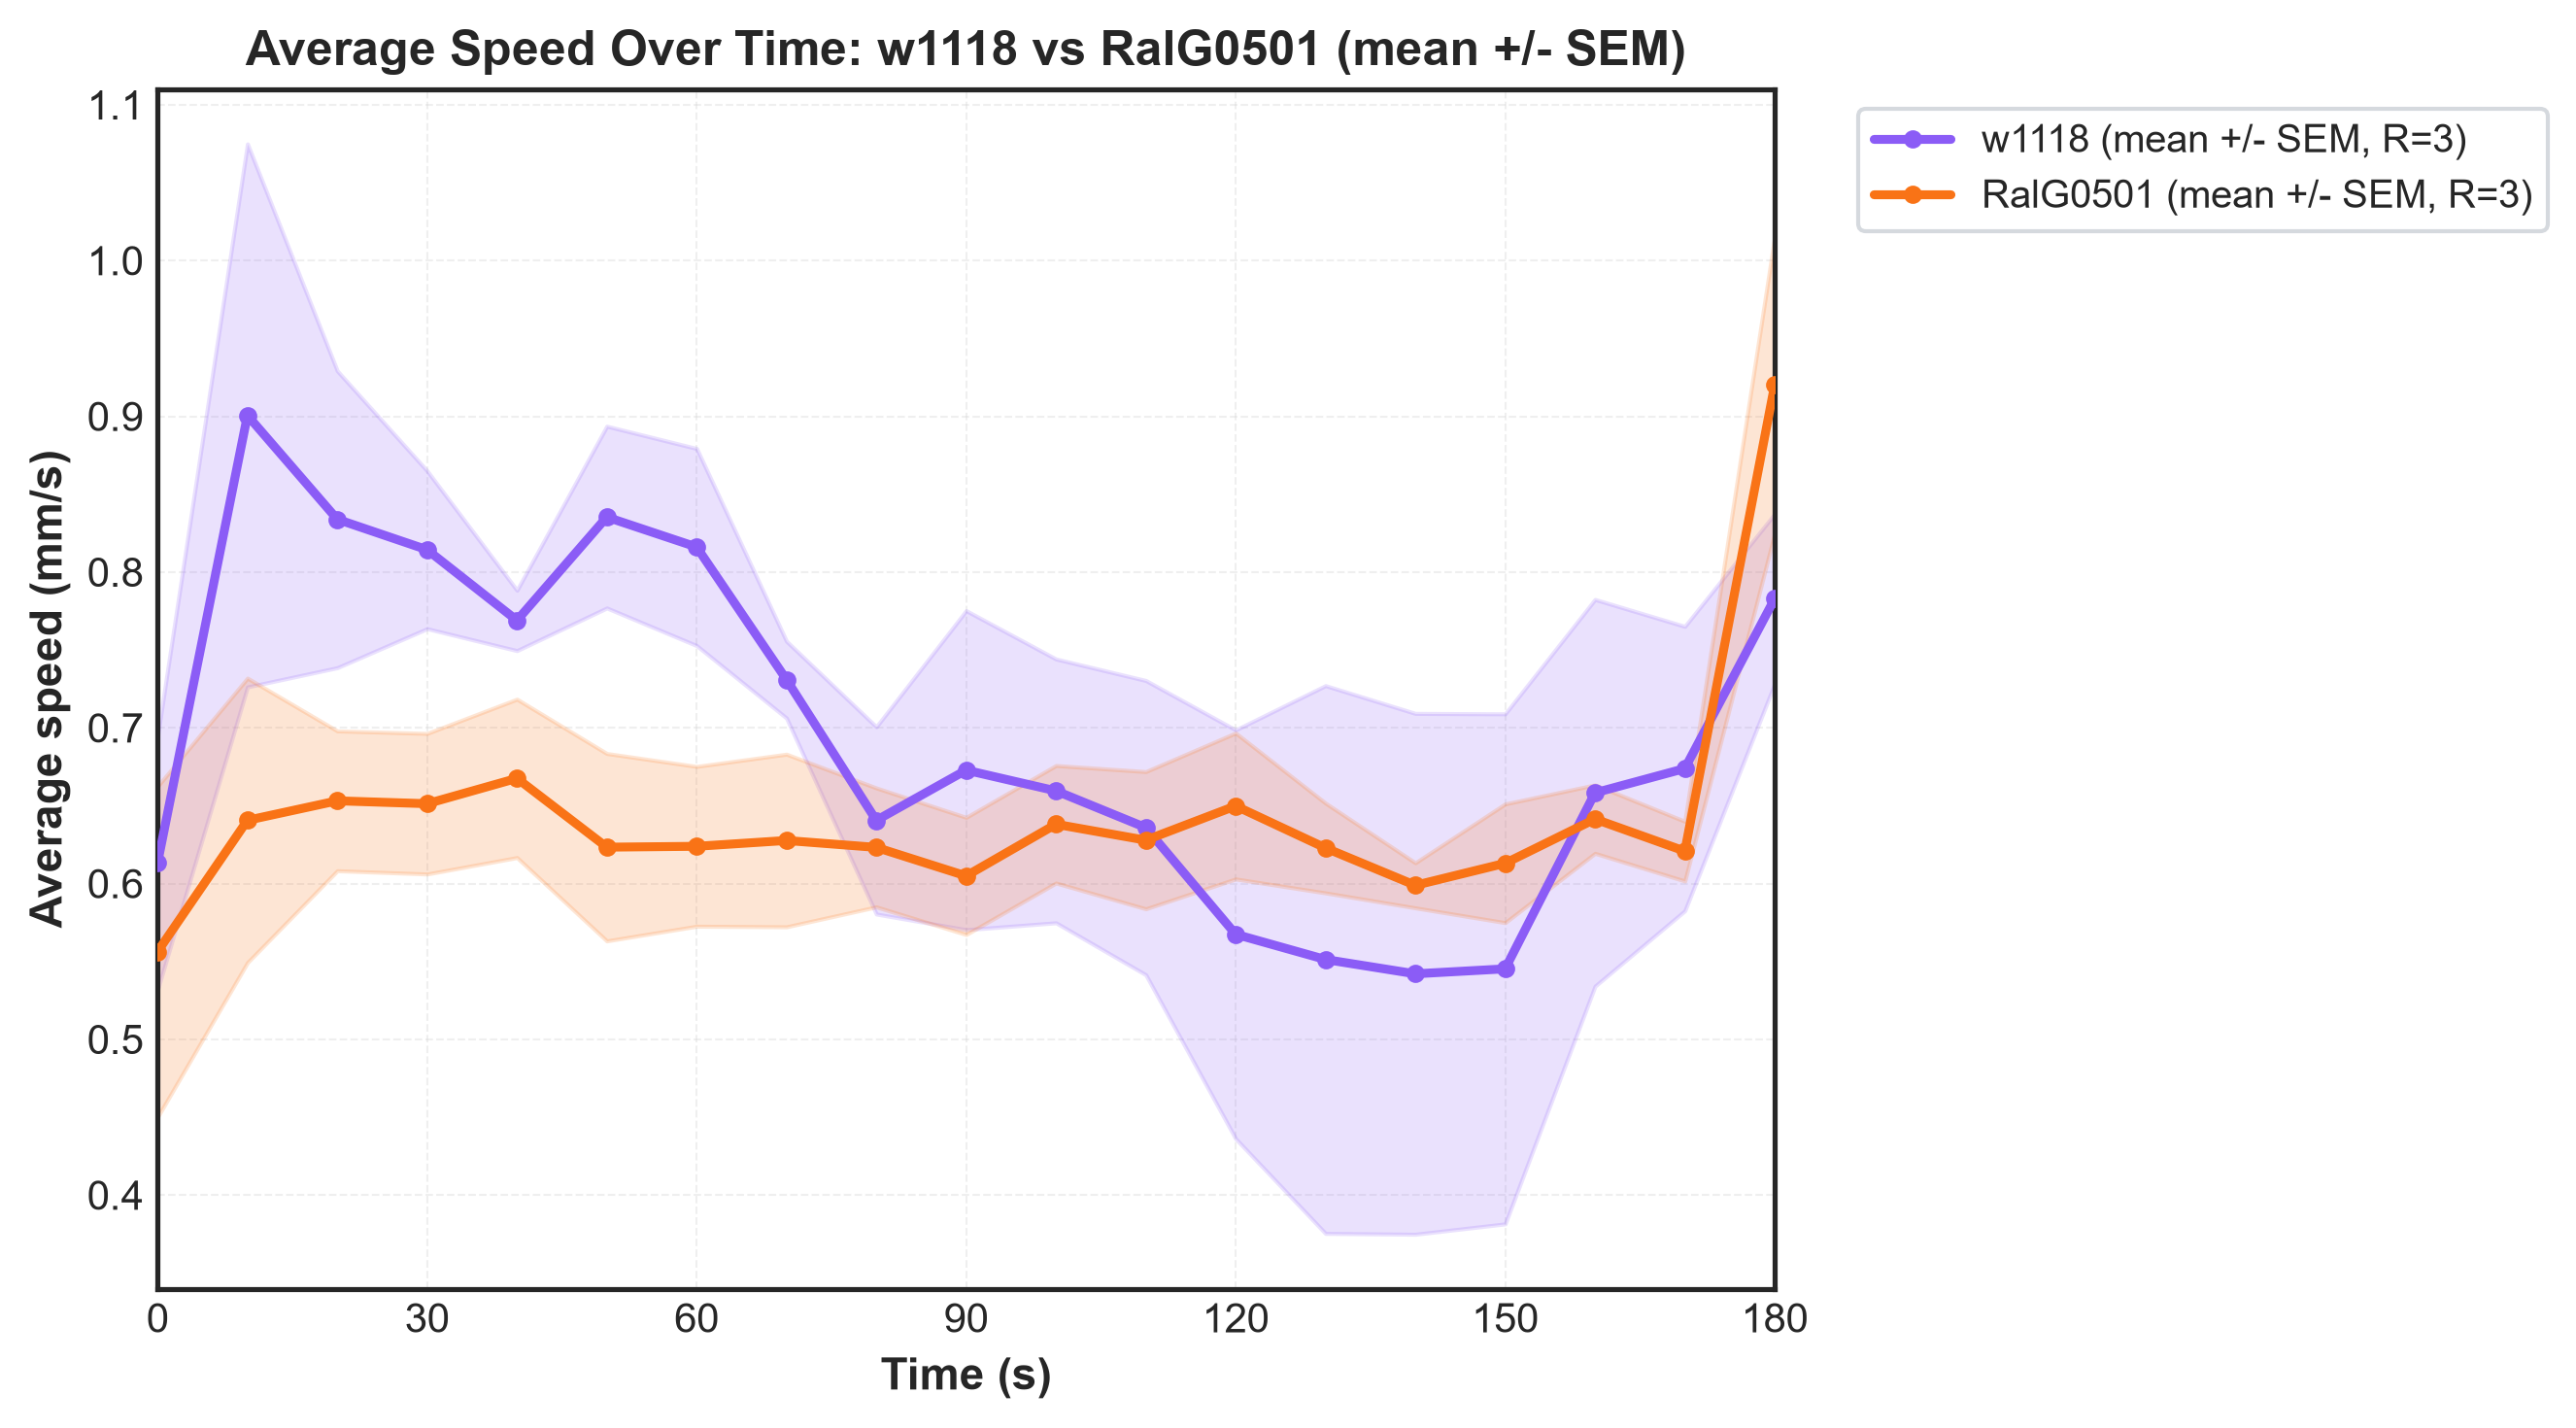

Saved plot: ..\data\results\average_speed_over_time_w1118_vs_RalG0501_sd.png


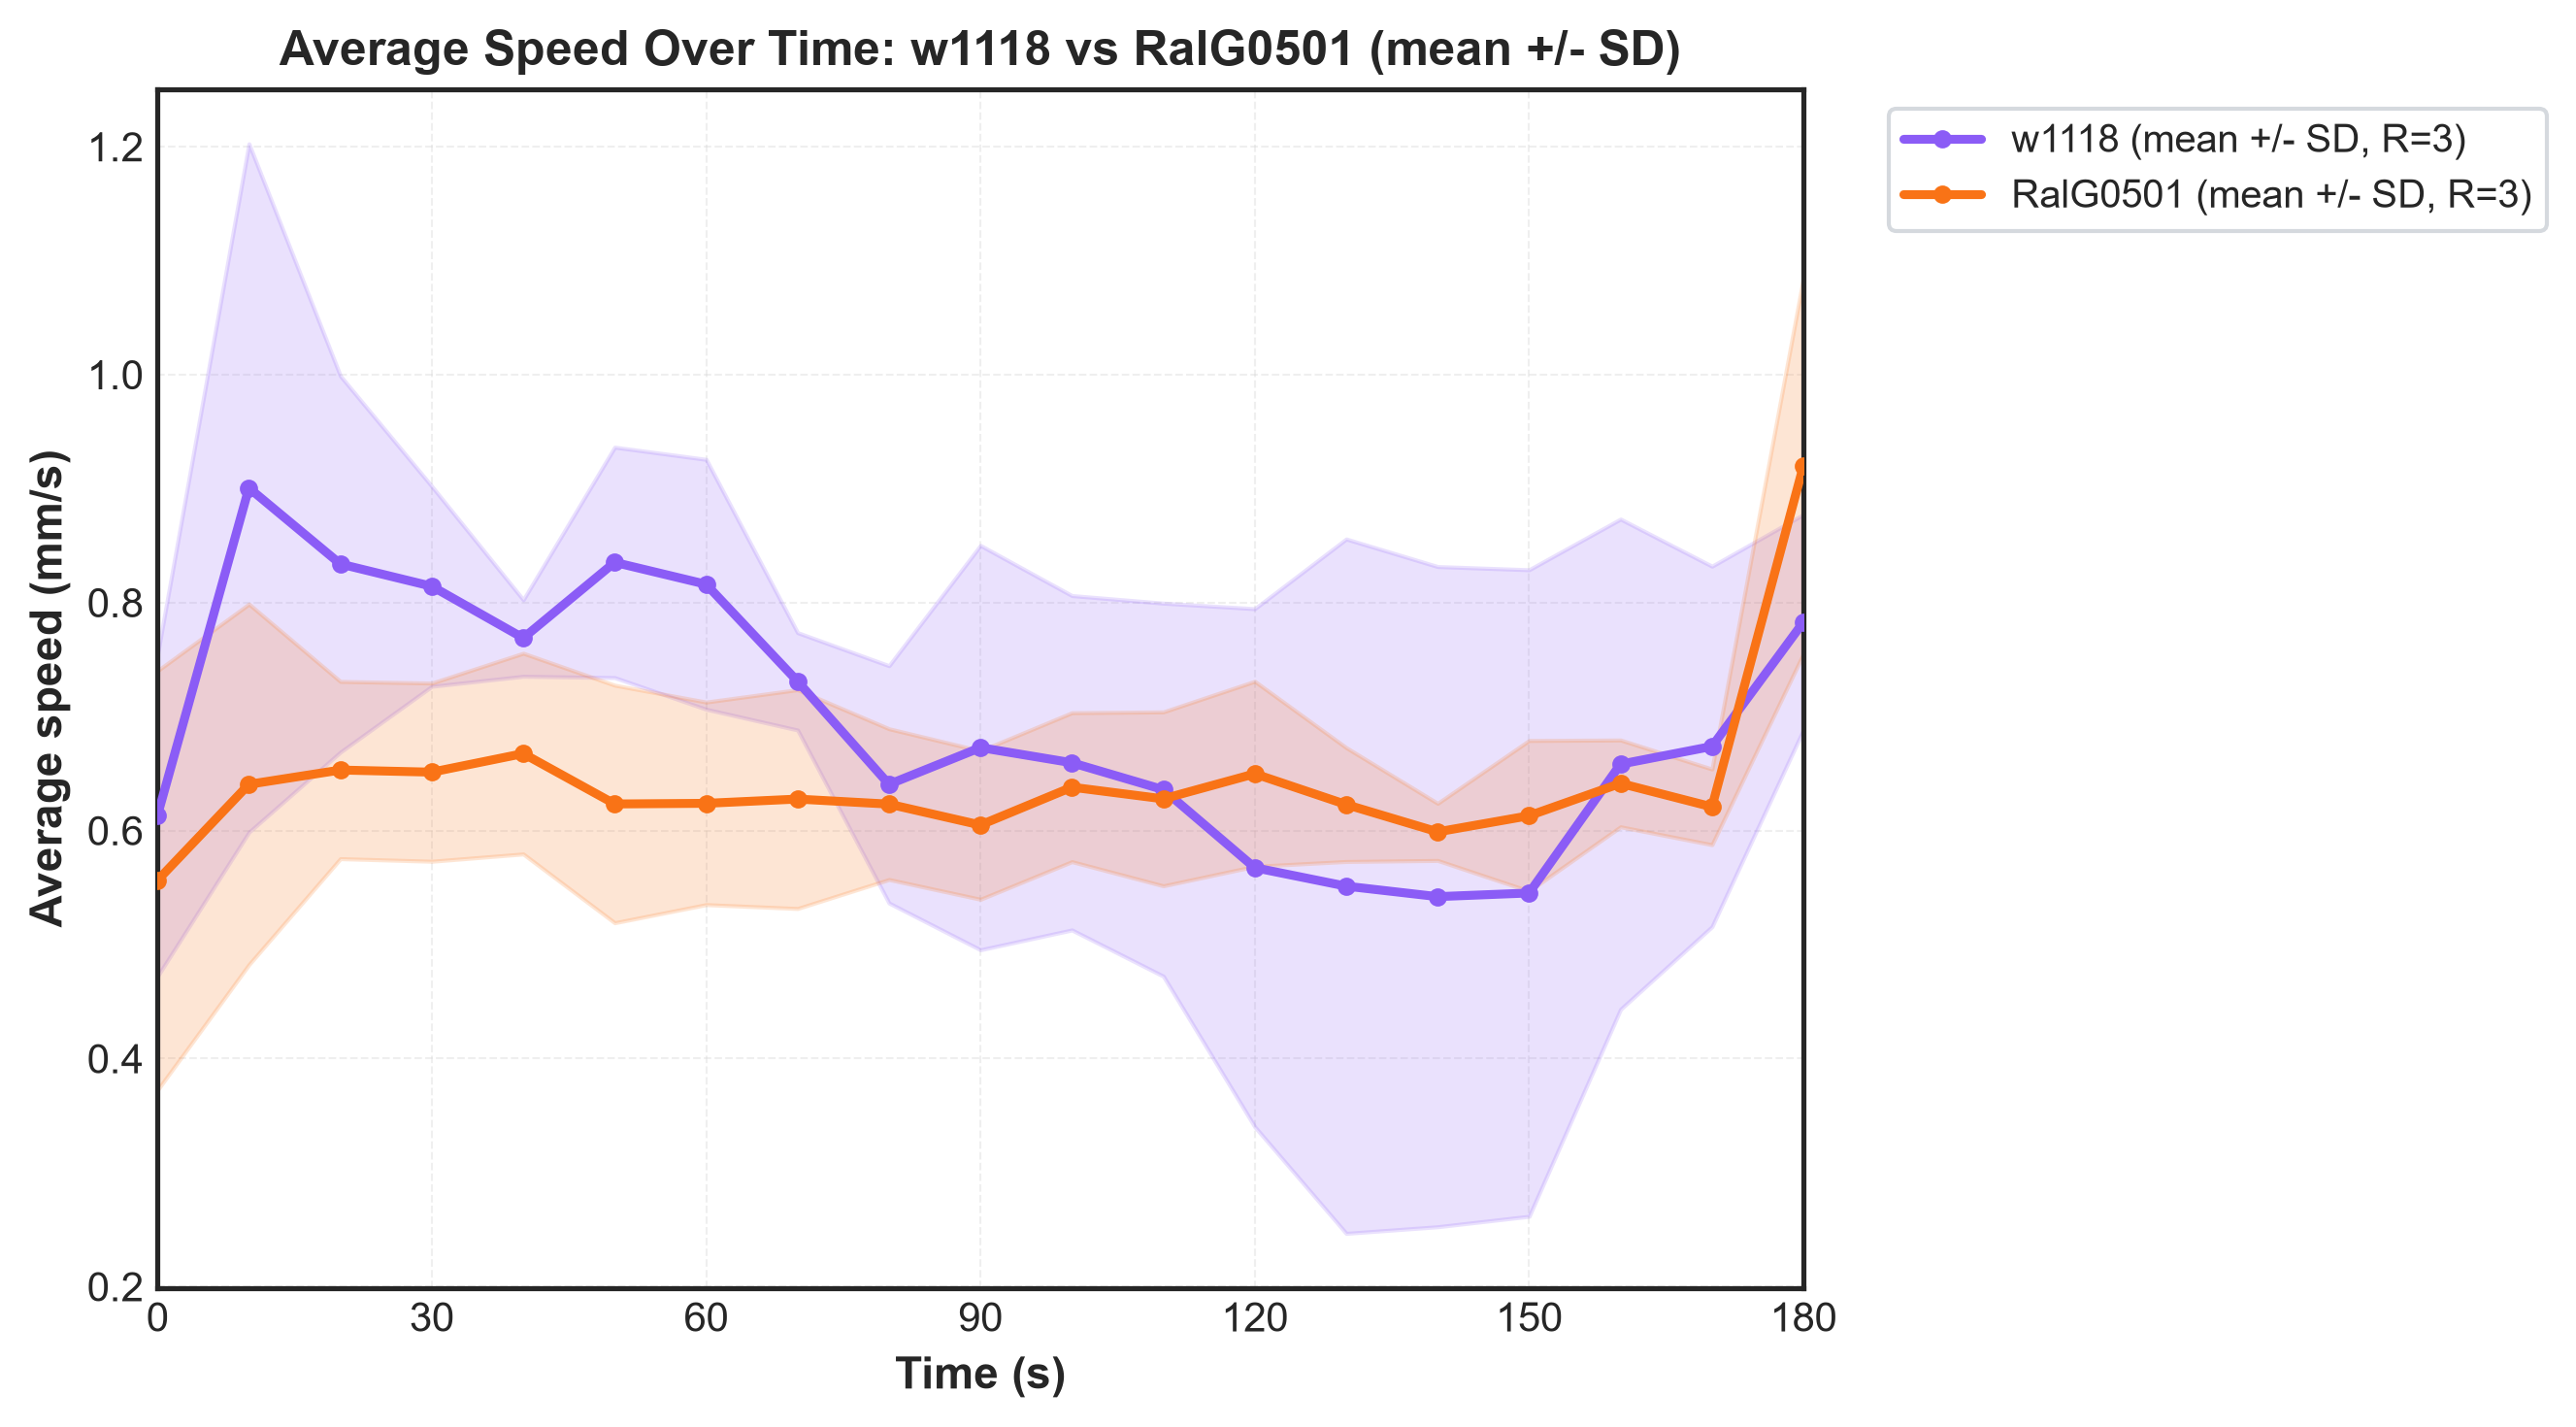

  STATISTICAL REPORT: AVERAGE SPEED OVER TIME (nSybxw1118 vs nSybxRalRNAi)
Hierarchical Summary (mean of replicate means, N=3 vs N=3 biological replicates):
  * nSybxw1118     : Mean = 0.6502 mm/s | SD = 0.0686 | SEM = 0.0396 | Shapiro-Wilk p = 0.8142
  * nSybxRalRNAi   : Mean = 0.6507 mm/s | SD = 0.1133 | SEM = 0.0654 | Shapiro-Wilk p = 0.5455
Homogeneity of Variance (Levene's test): p = 0.6151 (Equal variance confirmed)
Normality Outcome: Normal distribution (p > 0.05)
Hypothesis Test Selected: Two-sample Student's t-test
Significance: p = 0.9949 [ns]
------------------------------------------------------------------------
SCIENTIFIC JUSTIFICATION: SD vs SEM
  - SD (Standard Deviation): Quantifies the direct biological spread / variability
    between experimental cohorts. Use SD when the objective is to describe the
    variation inherent to the biological population.
  - SEM (Standard Error of the Mean = SD / sqrt(N)): Quantifies the precision of the
    estimated population mean. 

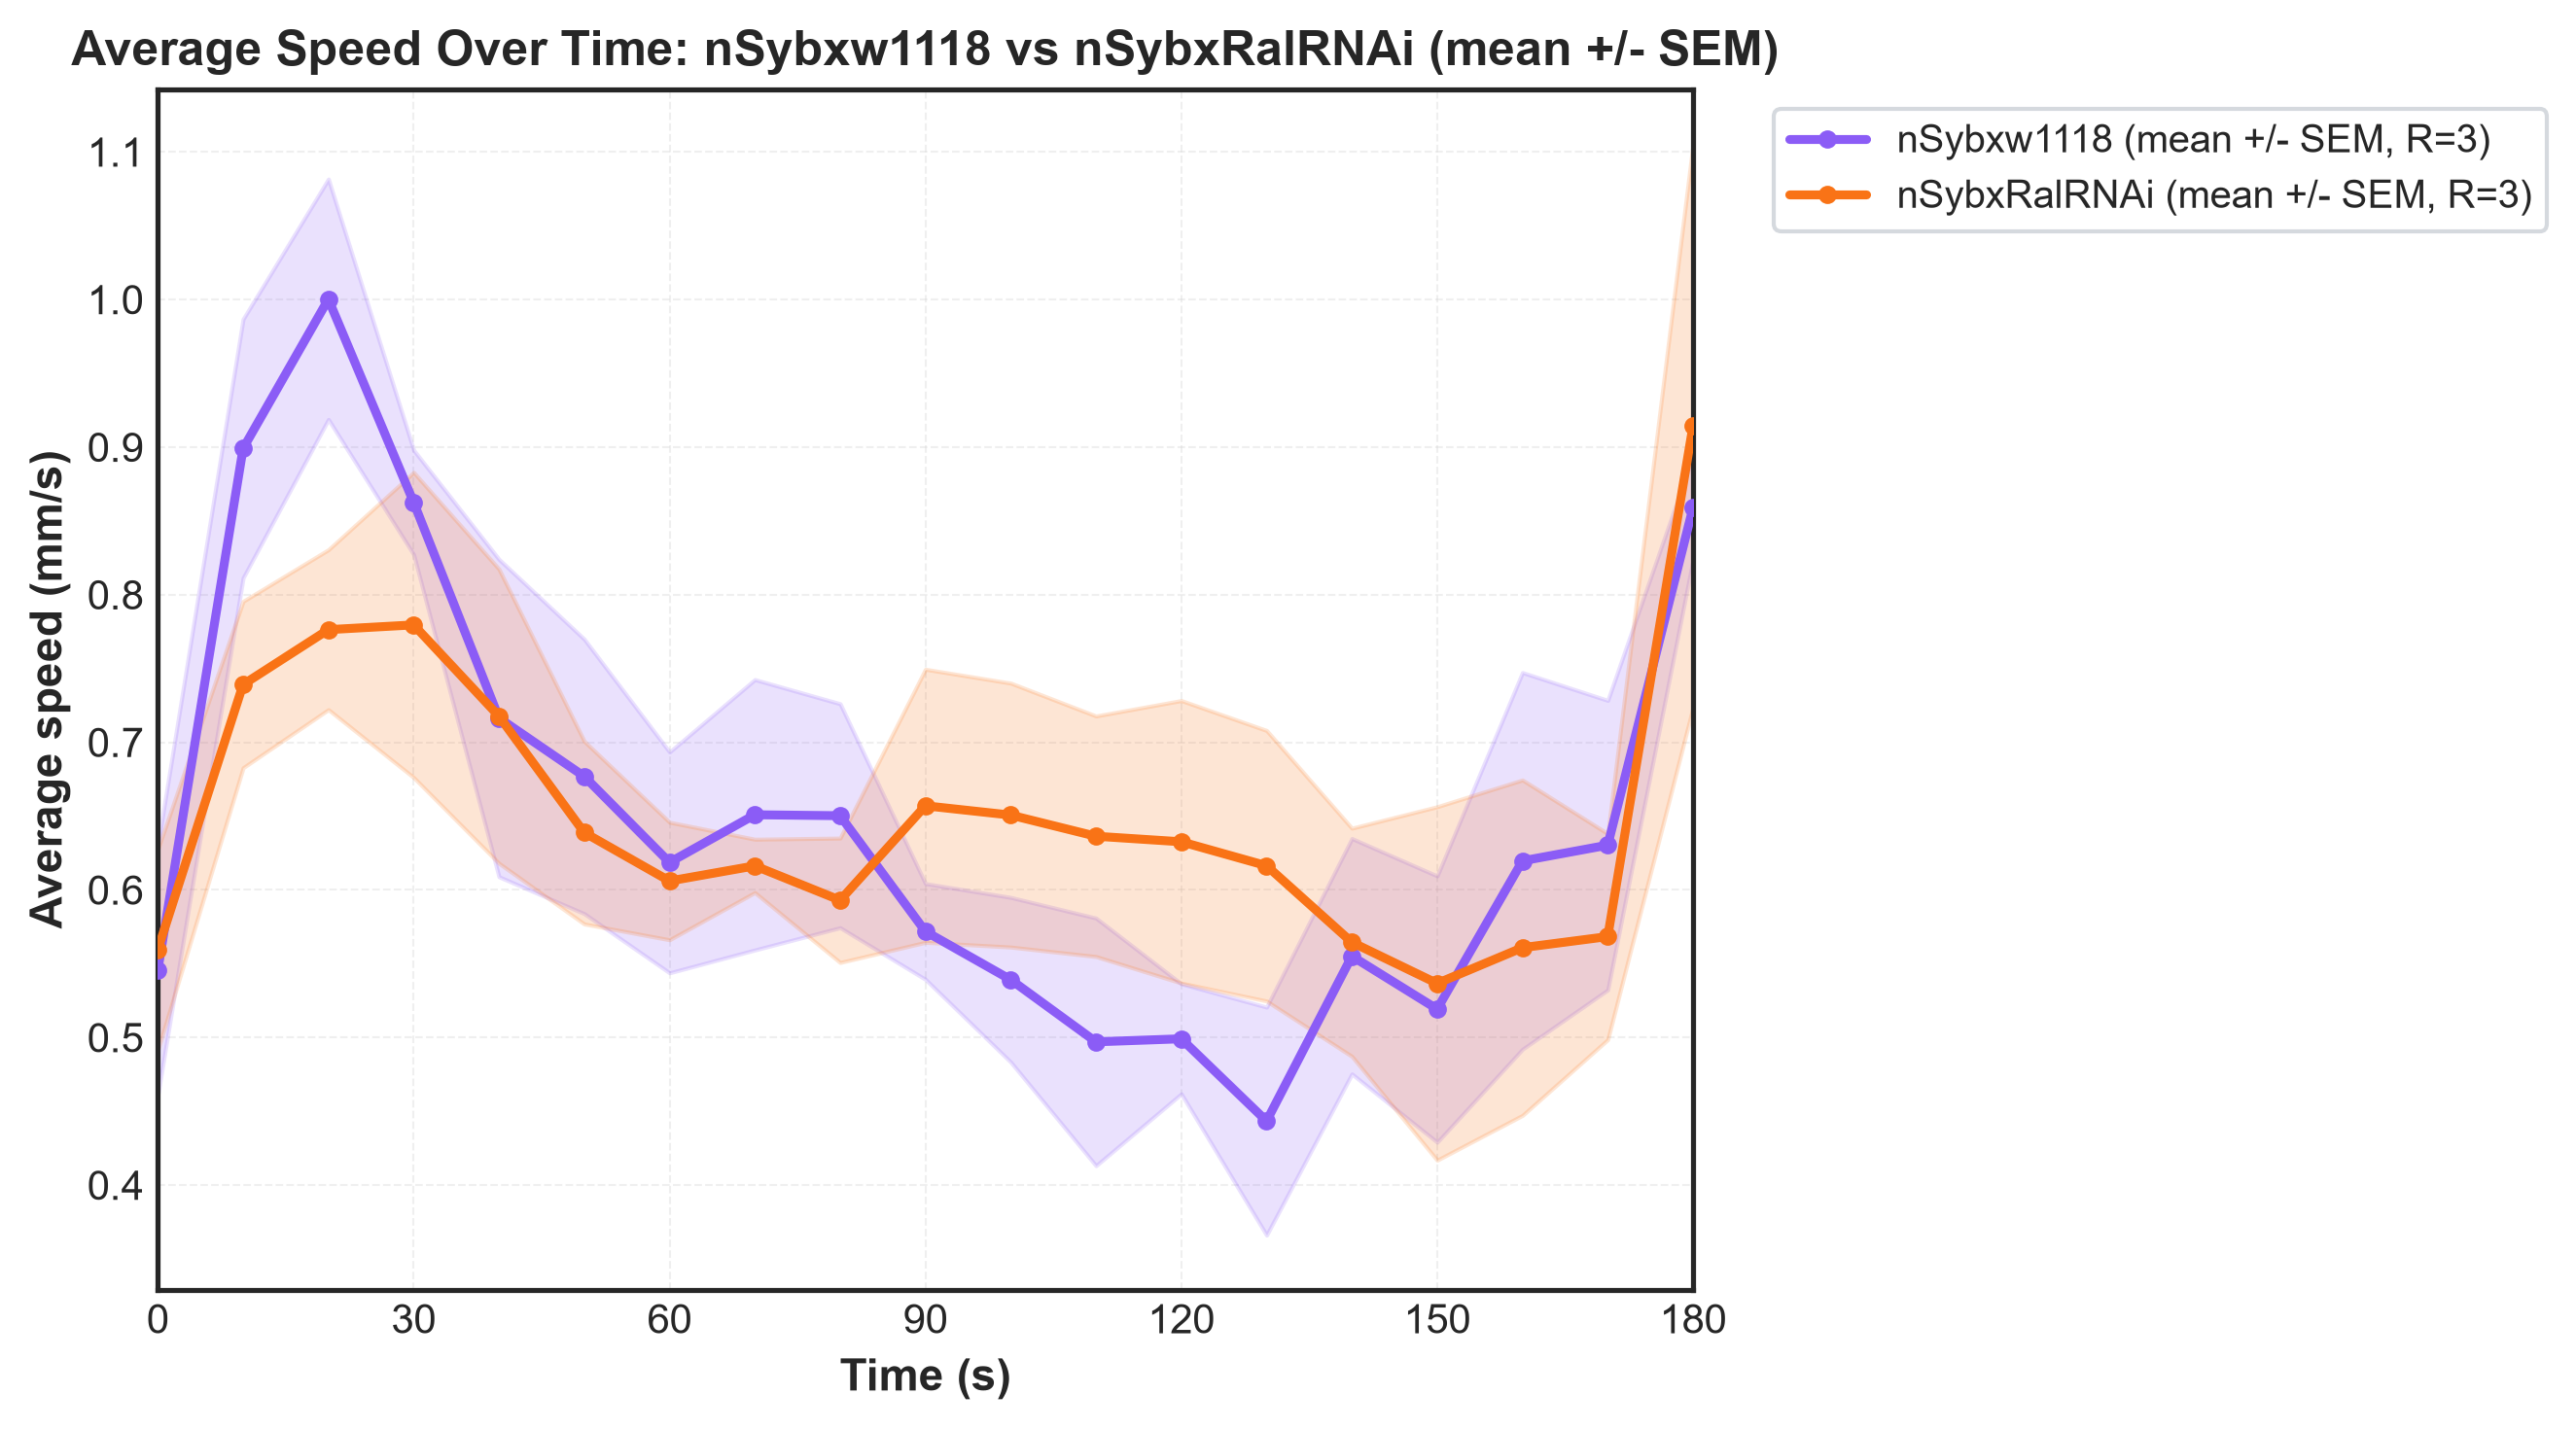

Saved plot: ..\data\results\average_speed_over_time_nSybxw1118_vs_nSybxRalRNAi_sd.png


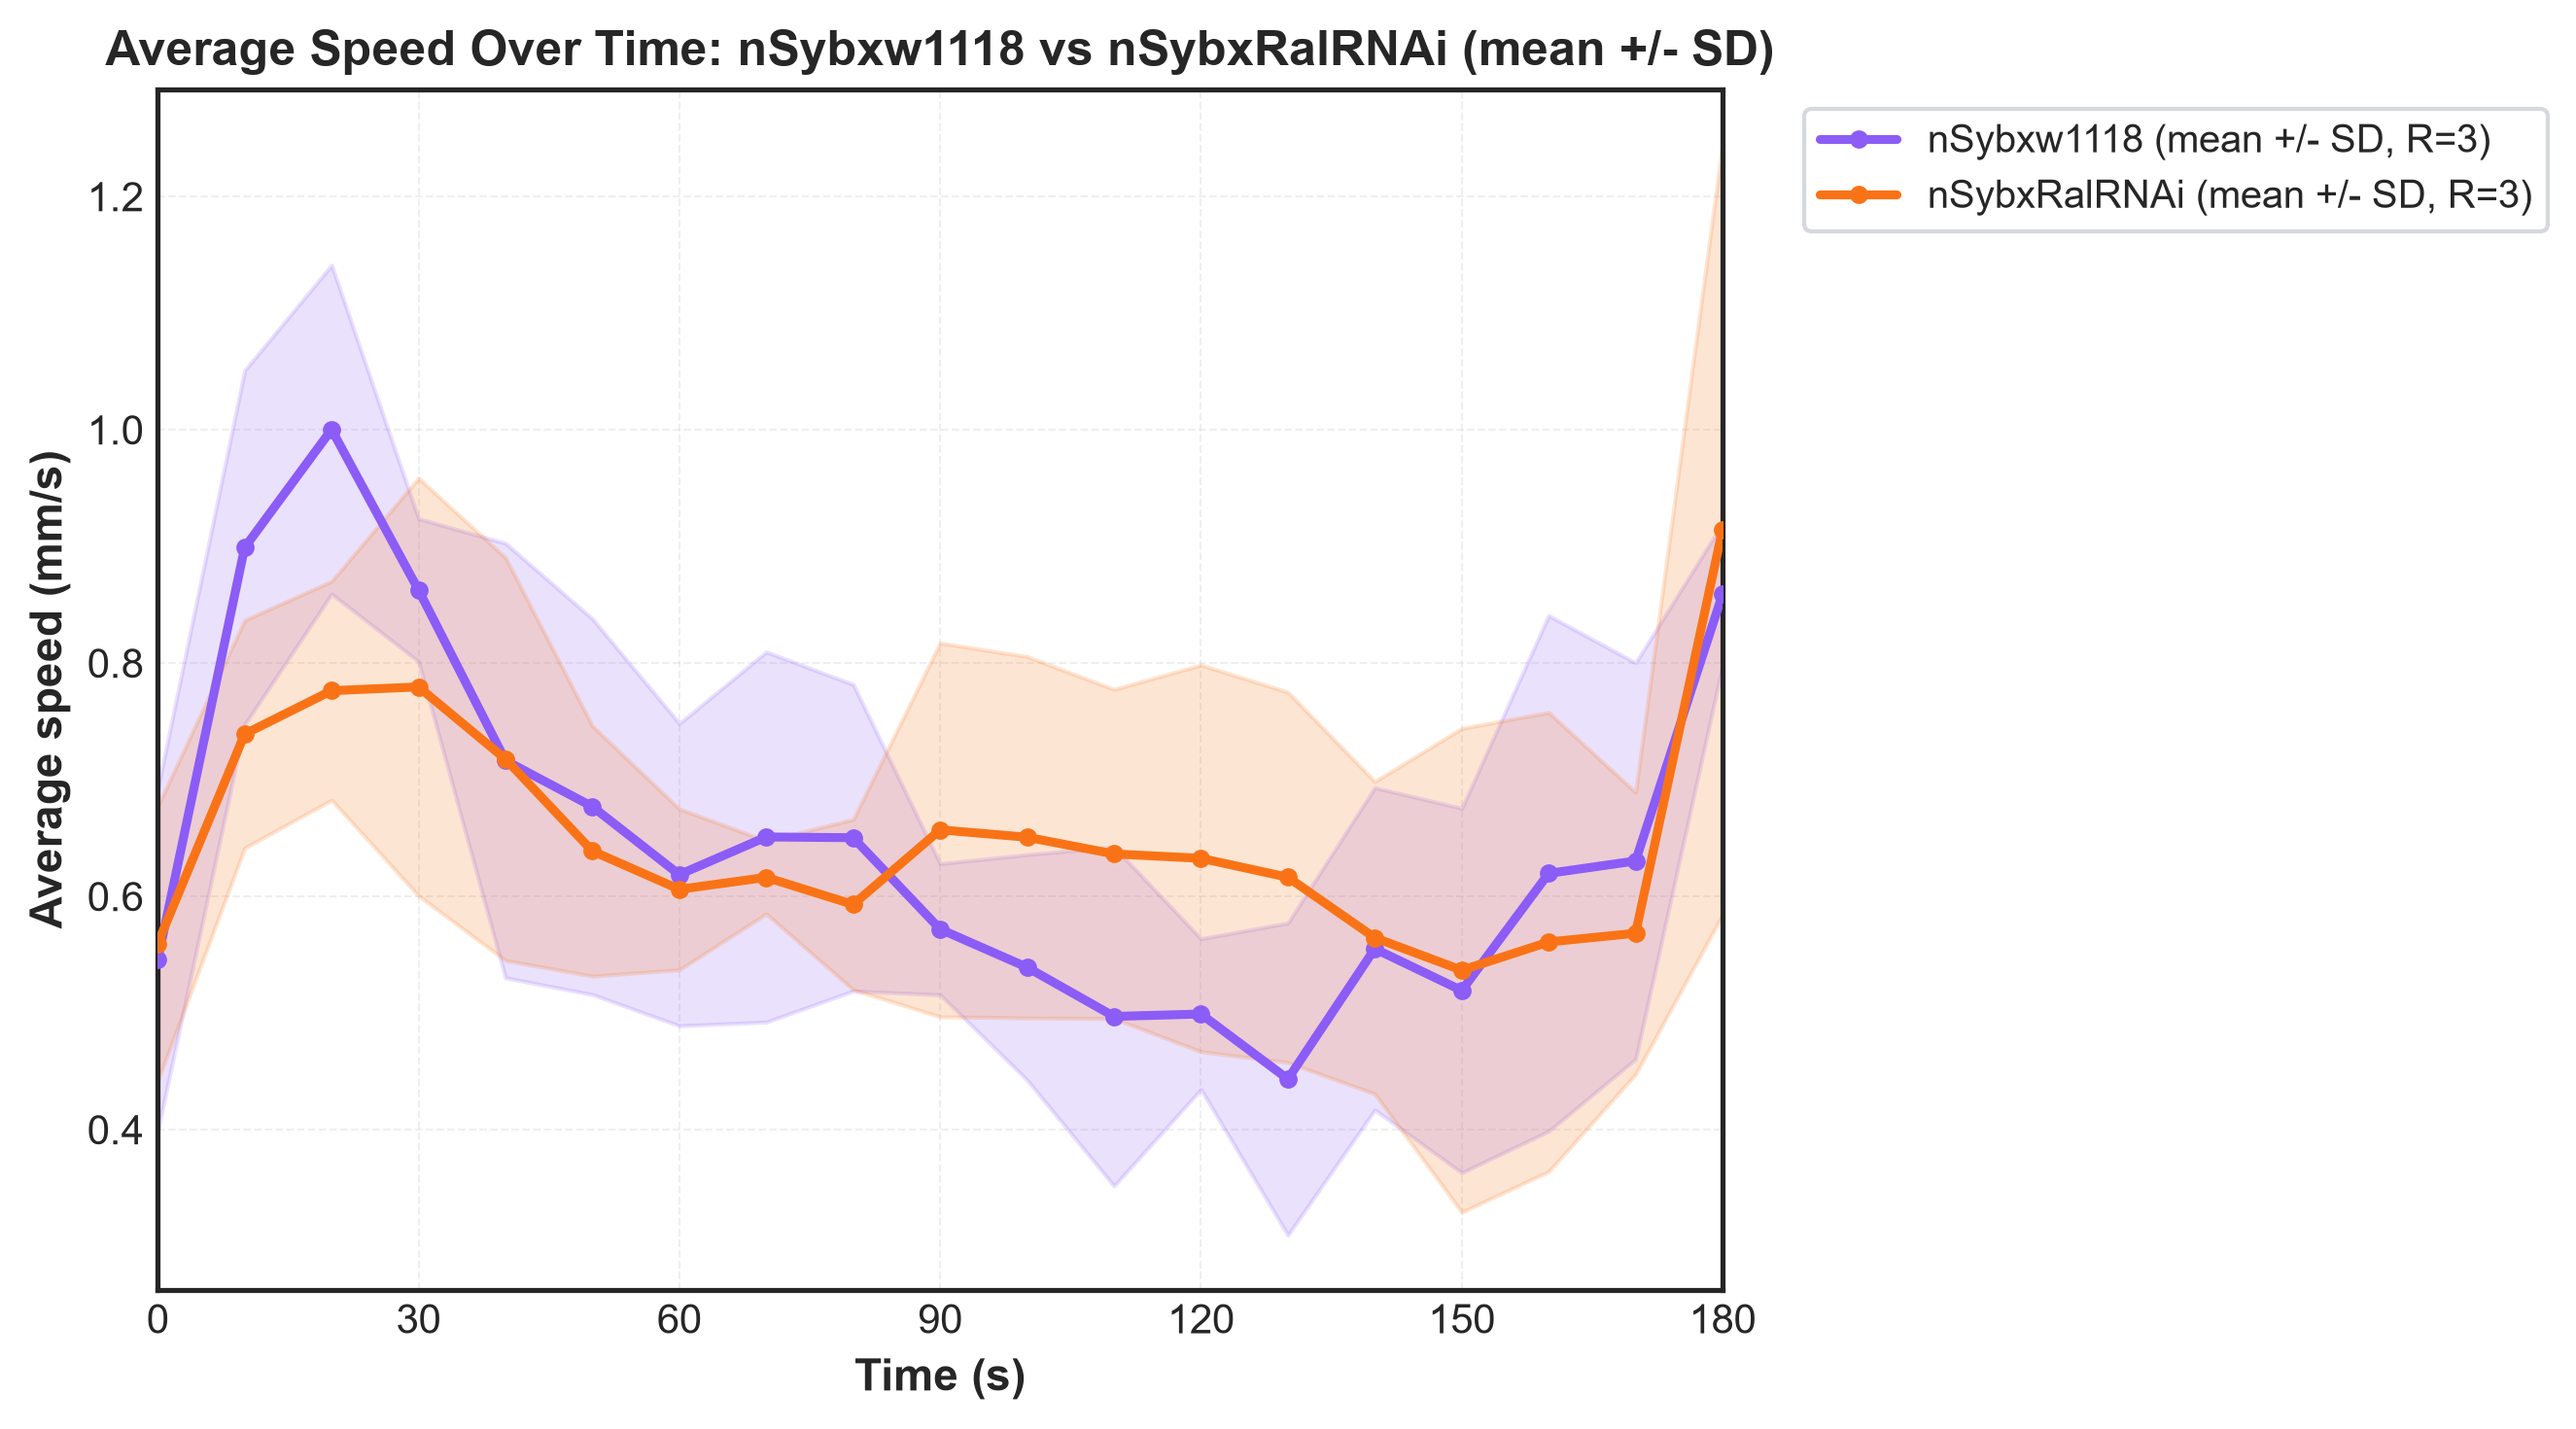

In [17]:
# =========================================================================
# 4. Average Speed Over Time (Grand Mean of Replicate Means +/- SEM/SD)
# Dynamically generated for each discovered comparison group
# =========================================================================
from larva_analysis import plot_average_speed_over_time

for comp in comparisons:
    label_str = " vs ".join(comp)
    file_suffix = "_vs_".join(comp)
    
    # 1. Curve with SEM band (inferential, precision of the grand mean)
    fig_sem, ax_sem = plot_average_speed_over_time(
        larva_dfs,
        genotypes=comp,
        epoch_s=EPOCH_S,
        error_type="sem",
        title=f"Average Speed Over Time: {label_str} (mean +/- SEM)",
        show_legend=True,
        print_stat_report=True,
        save_path=results_folder / f"average_speed_over_time_{file_suffix}_sem.png"
    )
    plt.show()
    
    # 2. Curve with SD band (descriptive, biological replicate variability)
    fig_sd, ax_sd = plot_average_speed_over_time(
        larva_dfs,
        genotypes=comp,
        epoch_s=EPOCH_S,
        error_type="sd",
        title=f"Average Speed Over Time: {label_str} (mean +/- SD)",
        show_legend=True,
        print_stat_report=False,
        save_path=results_folder / f"average_speed_over_time_{file_suffix}_sd.png"
    )
    plt.show()


### Save the batch summary

Writes the full summary table (including QC flags) to a CSV and an Excel file next to this
notebook.


In [18]:
results_folder = Path('../data/results') if Path('../data/results').exists() else Path('data/results') if Path('data/results').exists() else Path('.')
summary_csv_path = results_folder / 'larva_batch_summary.csv'
summary_xlsx_path = results_folder / 'larva_batch_summary.xlsx'
summary_table.to_csv(summary_csv_path)
summary_table.to_excel(summary_xlsx_path)
print(f'Saved {summary_csv_path} and {summary_xlsx_path}')


Saved ..\data\results\larva_batch_summary.csv and ..\data\results\larva_batch_summary.xlsx


### Multi-Larva Trajectory Overlay (Arena-Centered)

This reproduces the multi-larva overlay plot (as in Empty_Trajectories.ipynb and Hid_all_larvae_inferno.png).
Each larva trajectory is re-centered around the arena origin (0, 0) and plotted together
with a circular arena boundary and distinct colors from the chosen colormap.


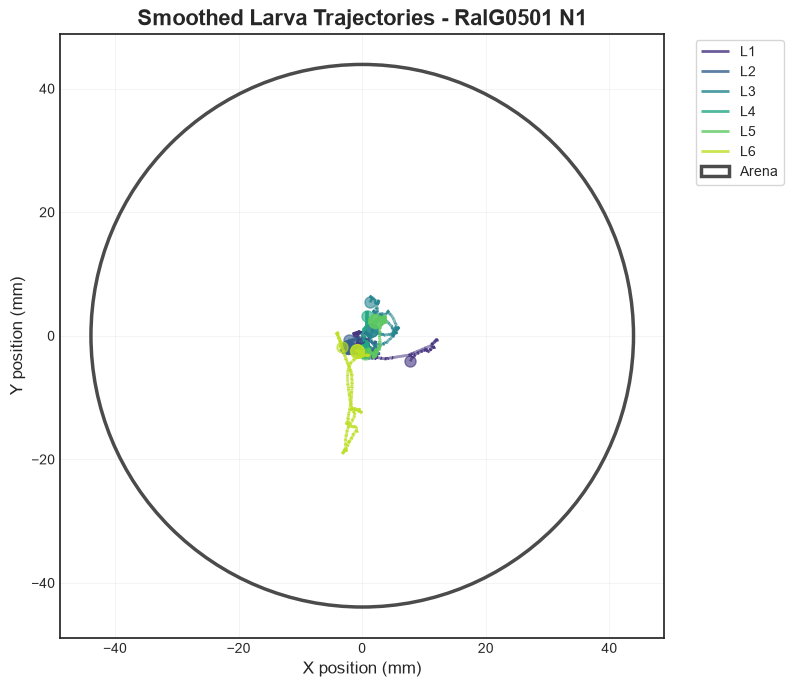

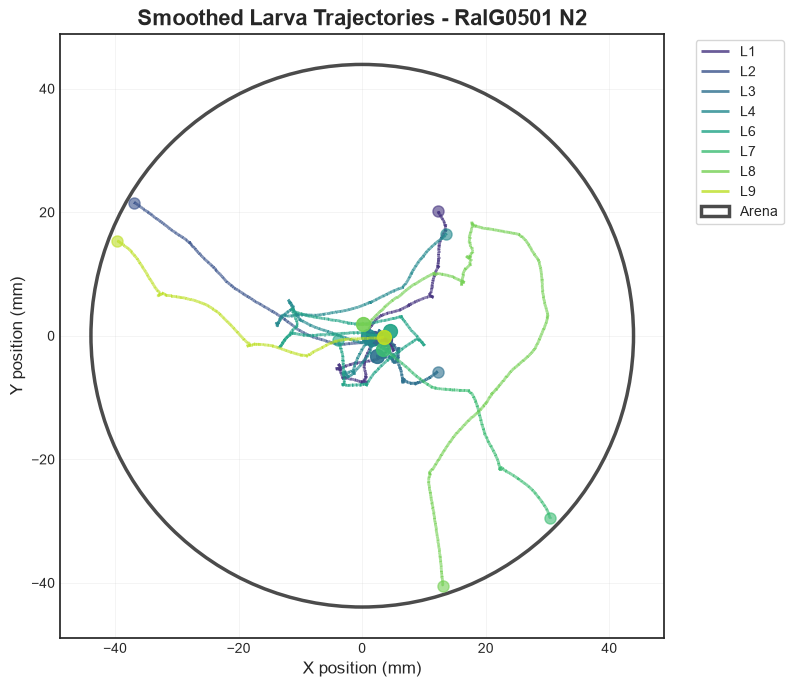

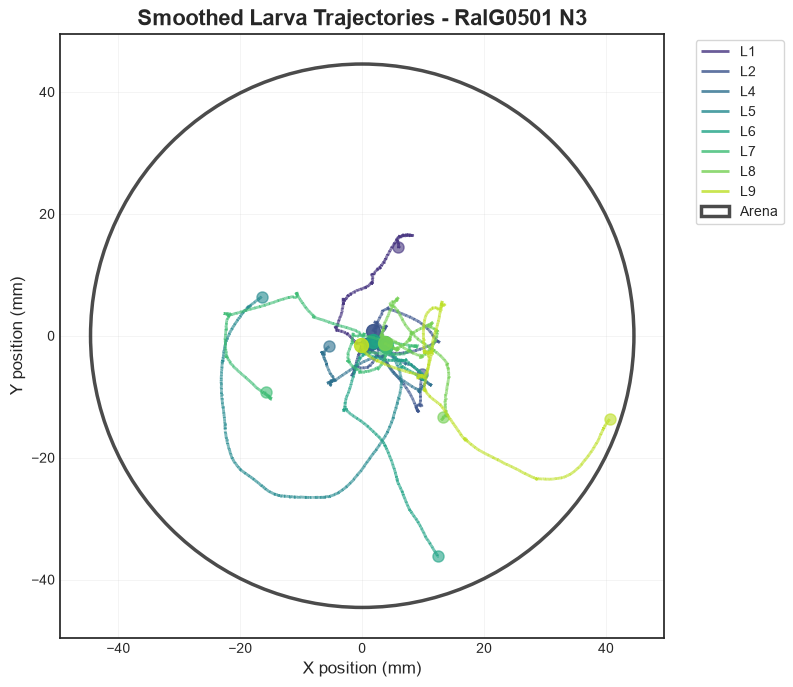

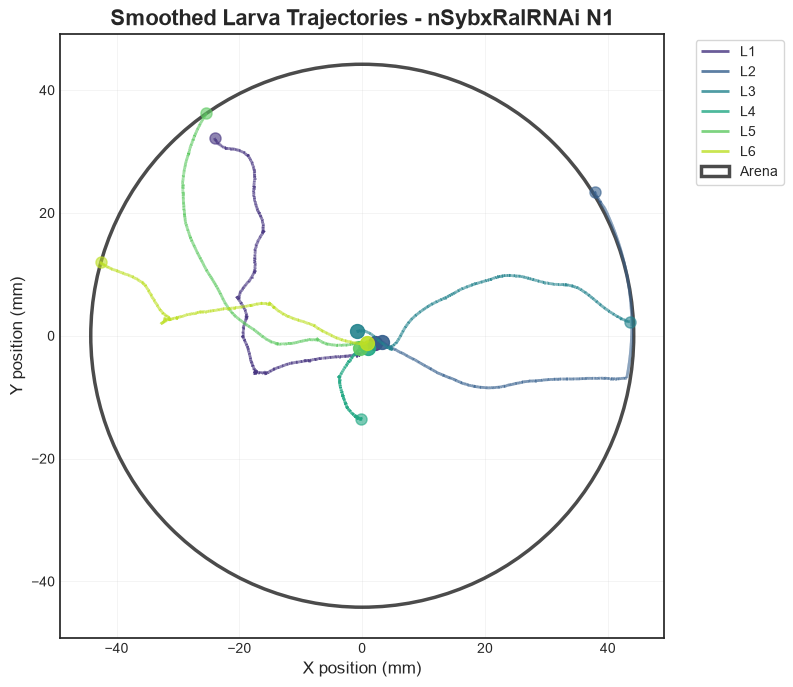

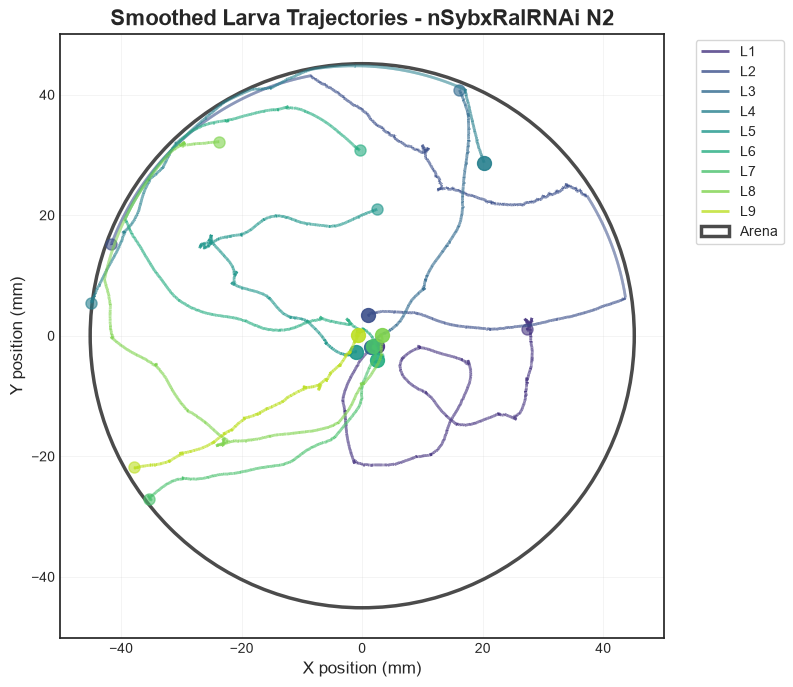

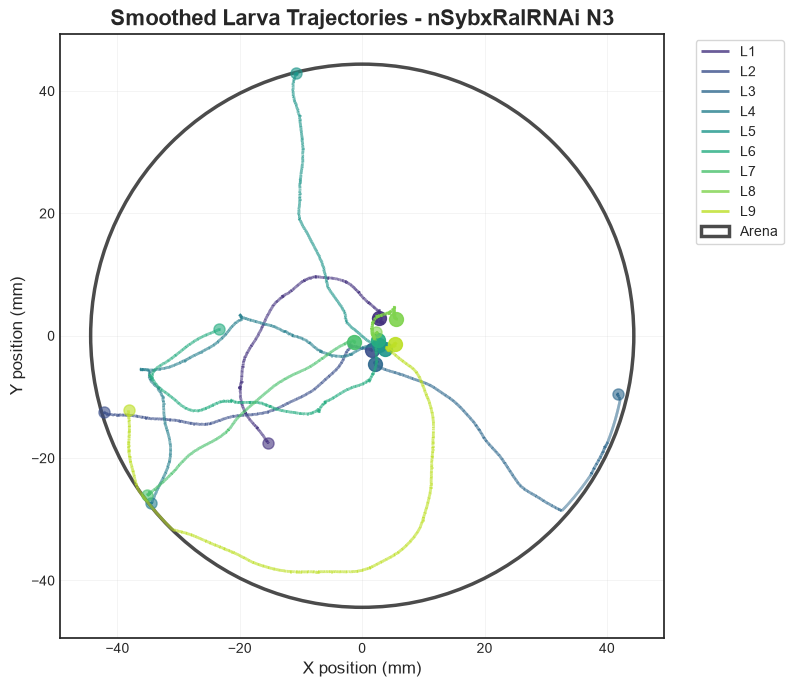

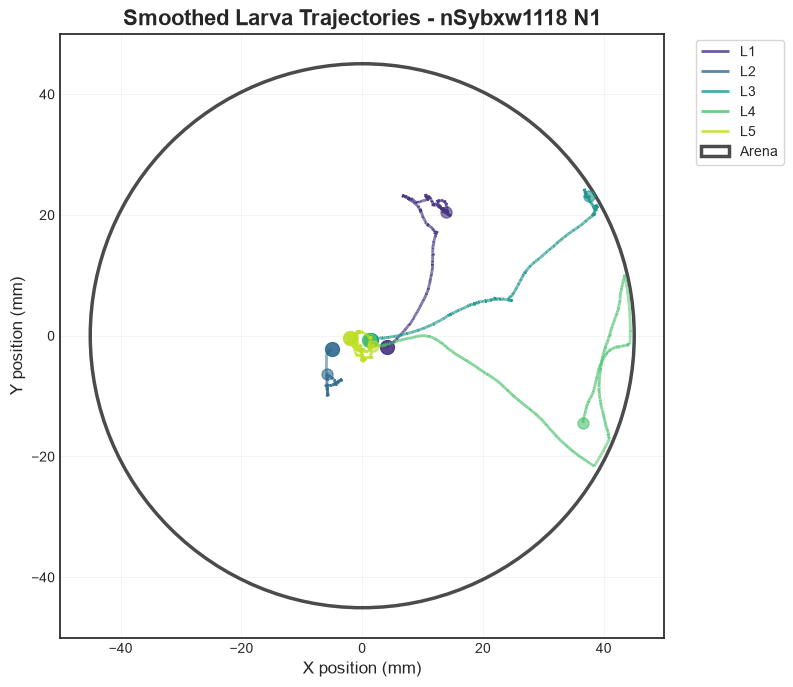

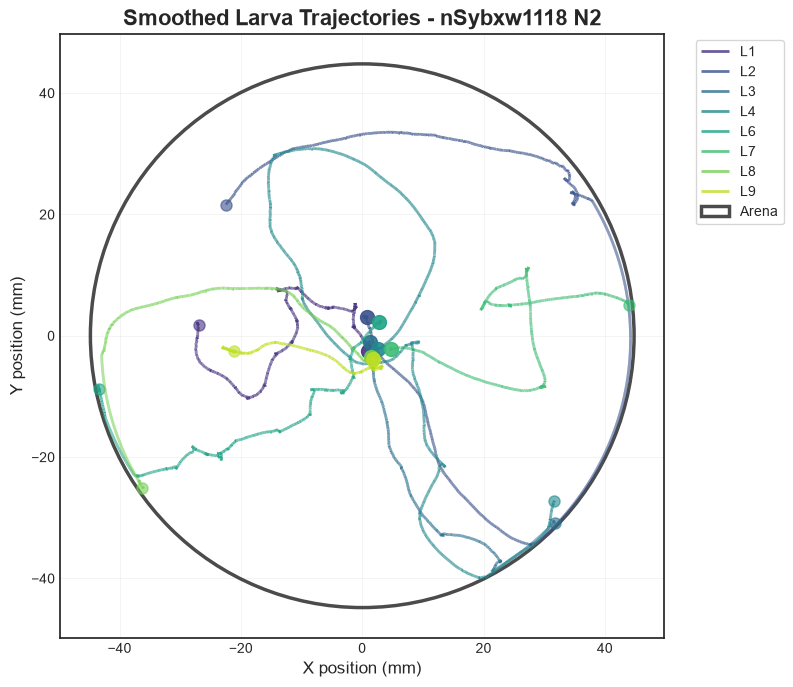

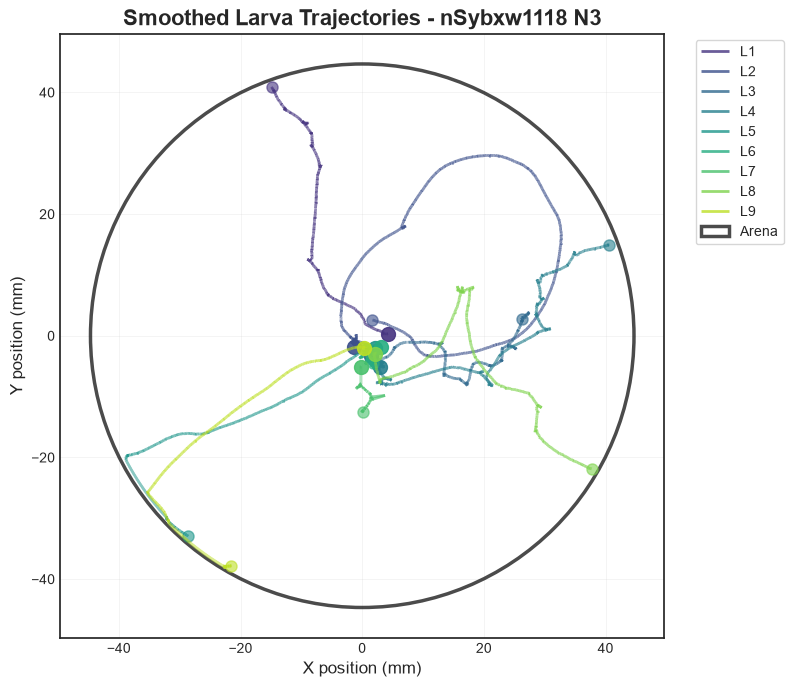

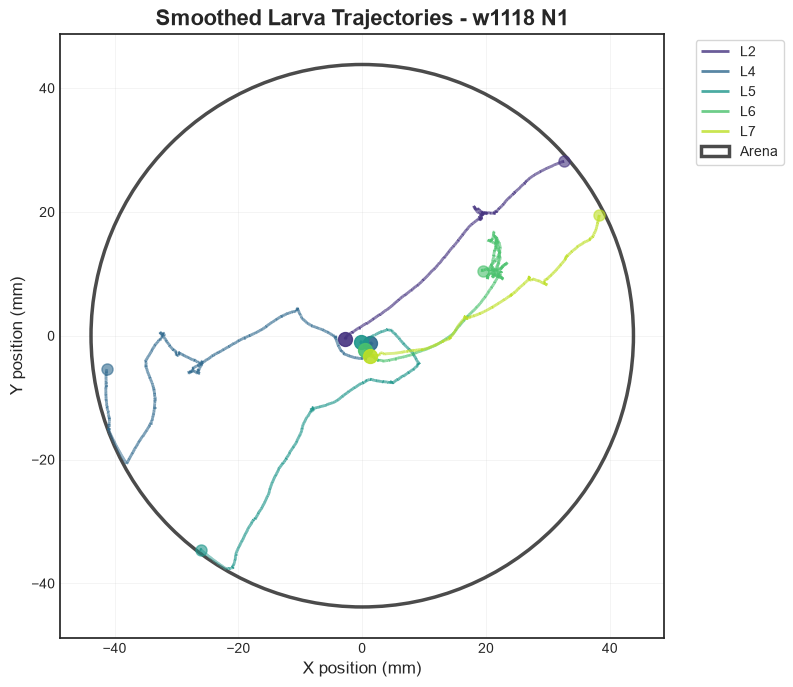

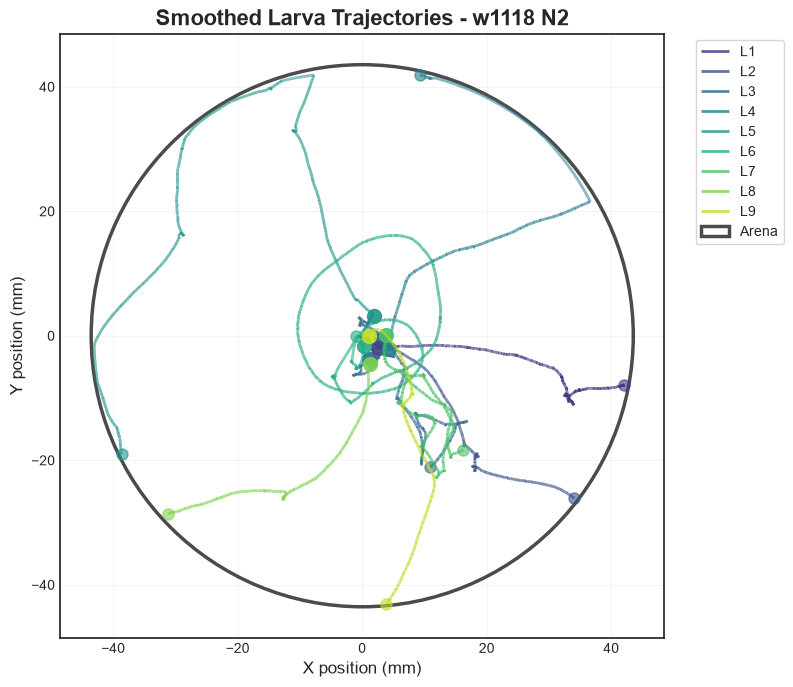

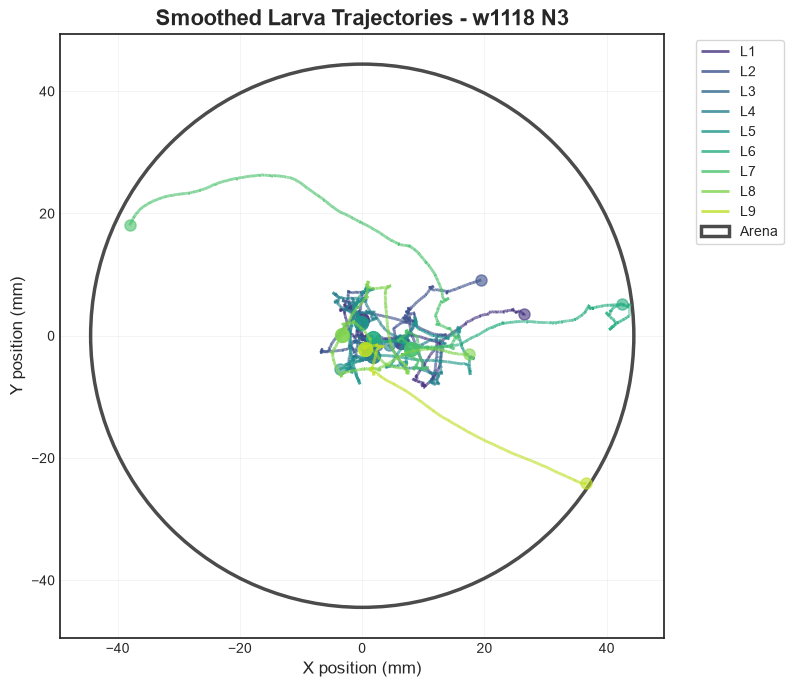

In [19]:
# Load ALL larvae and group by genotype and NX cohort
genotype_cohort_overlay = {}

for p in csv_paths:
    if str(p) in larva_dfs:
        df_larva = larva_dfs[str(p)]
    elif p.stem in larva_dfs:
        df_larva = larva_dfs[p.stem]
    else:
        df_larva = None
    if df_larva is None:
        df_larva = load_and_clean(p, fps=FPS, max_gap_frames=MAX_GAP_FRAMES, arena_margin_fraction=ARENA_MARGIN_FRACTION, max_bridge_dist_mm=MAX_BRIDGE_DIST_MM)
        df_larva = compute_kinematics(df_larva, max_speed_mm_s=MAX_SPEED_MM_S)
    
    meta = parse_filename_metadata(p)
    genotype = df_larva.attrs.get("genotype") or meta.get("genotype") or "Unknown"
    cohort = meta.get("cohort") or "All"
    label = meta.get("stem", p.stem)
    
    genotype_cohort_overlay.setdefault(genotype, {}).setdefault(cohort, {"dfs": [], "labels": []})
    genotype_cohort_overlay[genotype][cohort]["dfs"].append(df_larva)
    genotype_cohort_overlay[genotype][cohort]["labels"].append(label)

results_folder = Path("../data/results") if Path("../data/results").exists() else Path("data/results") if Path("data/results").exists() else Path(".")

# Multi-larva arena-centered overlay plot for EACH genotype and NX cohort
for genotype, cohort_dict in sorted(genotype_cohort_overlay.items()):
    for cohort in sorted(cohort_dict.keys()):
        c_data = cohort_dict[cohort]
        c_save_path = results_folder / f"{genotype}_{cohort}_larvae_trajectory_overlay.png"
        fig, ax = plot_multi_larva_overlay(
            c_data["dfs"],
            labels=c_data["labels"],
            title=f"Smoothed Larva Trajectories - {genotype} {cohort}",
            palette_name="purple_orange",
            save_path=str(c_save_path),
        )
        plt.show()


## Notes / parameters you may want to tune

- **`MAX_GAP_FRAMES`** — how many consecutive undetected frames still count as a "blip" to
  interpolate through, vs. a real loss of tracking (e.g. larva at the dish wall) that's left
  as a gap and excluded from distance/speed.
- **Outlier rejection threshold** — set automatically per video in `load_and_clean`
  (`deviation_multiplier`, `min_deviation_floor_mm`, `local_window` arguments), so a noisier
  video gets a looser threshold rather than one fixed number for every video. Override
  `max_local_deviation_mm` directly if you want the same fixed threshold everywhere instead.
- **`EPOCH_S`** — length of the time bins used for the per-epoch speed summary.
- Re-run `list_flagged_events(df)` for any individual video whose batch row got flagged, to see
  exactly which frames were rejected before deciding whether to trust it.
